# Phase 10 — Exploratory Data Analysis

## 1. EDA Objective & Scope

**Objective:** Explore distributions, trends, categories, geography, customers, seasonality, relationships, and anomalies using the validated Phase 9 processed datasets.

### Scope
- Use `data/processed/*.csv` as the primary EDA input layer.
- Use existing PostgreSQL analytical outputs for independent cross-validation.
- Use existing Phase 9 validation evidence to confirm row counts, grain, joins, traceability, and reproducibility.
- Do not make unsupported profit, margin, or causal claims.
- Use `customer_unique_id` for repeat-customer analysis.
- Treat 2016 as a partial-year period when comparing time trends.
- Identify anomalies without automatically deleting them.


In [1]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Environment & Data Loading

Load the Phase 9 processed datasets and establish the analysis environment.

Expected inputs:
- `customers_processed.csv`
- `geography_processed.csv`
- `orders_processed.csv`
- `order_items_processed.csv`
- `payments_processed.csv`
- `products_processed.csv`
- `reviews_processed.csv`
- `sellers_processed.csv`


In [2]:
# =============================================================================
# 2. ENVIRONMENT & DATA LOADING
# =============================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# =============================================================================
# PROJECT PATH RESOLUTION
# =============================================================================

CURRENT_DIR = Path.cwd().resolve()

# Search upward from the current working directory until the project root
# containing data/processed is found.
PROJECT_ROOT = None

for path in [CURRENT_DIR, *CURRENT_DIR.parents]:

    candidate_processed_dir = path / "data" / "processed"

    if candidate_processed_dir.exists():
        PROJECT_ROOT = path
        break


# Stop immediately if the project root cannot be located.
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the project root containing "
        "'data/processed'.\n\n"
        f"Current working directory:\n{CURRENT_DIR}"
    )


# Actual processed-data directory
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"


# =============================================================================
# ENVIRONMENT INFORMATION
# =============================================================================

print("=" * 80)
print("PHASE 10 — EDA ENVIRONMENT & DATA LOADING")
print("=" * 80)

print(f"Current working directory : {CURRENT_DIR}")
print(f"Project root              : {PROJECT_ROOT}")
print(f"Processed data directory  : {PROCESSED_DIR}")


# =============================================================================
# EXPECTED PHASE 9 PROCESSED DATASETS
# =============================================================================

PROCESSED_FILES = {
    "customers": "customers_processed.csv",
    "geography": "geography_processed.csv",
    "orders": "orders_processed.csv",
    "order_items": "order_items_processed.csv",
    "payments": "payments_processed.csv",
    "products": "products_processed.csv",
    "reviews": "reviews_processed.csv",
    "sellers": "sellers_processed.csv",
}


print(f"Expected datasets         : {len(PROCESSED_FILES)}")


# =============================================================================
# VERIFY PROCESSED-DATA DIRECTORY
# =============================================================================

if not PROCESSED_DIR.is_dir():
    raise FileNotFoundError(
        f"Processed data directory does not exist:\n{PROCESSED_DIR}"
    )


# =============================================================================
# VERIFY ALL EXPECTED FILES
# =============================================================================

missing_files = []

for dataset_name, filename in PROCESSED_FILES.items():

    file_path = PROCESSED_DIR / filename

    if not file_path.is_file():
        missing_files.append(filename)


if missing_files:

    raise FileNotFoundError(
        "The following required Phase 9 processed datasets are missing:\n\n"
        + "\n".join(
            f" - {filename}"
            for filename in missing_files
        )
    )


print("\nAll expected Phase 9 processed files found.")


# =============================================================================
# LOAD DATASETS
# =============================================================================

datasets = {}

for dataset_name, filename in PROCESSED_FILES.items():

    file_path = PROCESSED_DIR / filename

    df = pd.read_csv(file_path)

    # Basic integrity check
    if df.empty:
        raise ValueError(
            f"{filename} was loaded but contains zero rows."
        )

    datasets[dataset_name] = df


# =============================================================================
# CREATE CONVENIENT DATAFRAME REFERENCES
# =============================================================================

customers = datasets["customers"]
geography = datasets["geography"]
orders = datasets["orders"]
order_items = datasets["order_items"]
payments = datasets["payments"]
products = datasets["products"]
reviews = datasets["reviews"]
sellers = datasets["sellers"]


# =============================================================================
# LOADING SUMMARY
# =============================================================================

print("\nLoaded datasets:")
print("-" * 80)

for dataset_name, df in datasets.items():

    print(
        f"{dataset_name:<15} | "
        f"rows={len(df):>8,} | "
        f"columns={len(df.columns):>2}"
    )


# =============================================================================
# BASIC ENVIRONMENT VALIDATION
# =============================================================================

# Exactly eight Phase 9 processed datasets are expected.
assert len(datasets) == 8, (
    f"Expected 8 processed datasets, found {len(datasets)}."
)


# Every loaded object must be a pandas DataFrame.
assert all(
    isinstance(df, pd.DataFrame)
    for df in datasets.values()
), "One or more loaded datasets is not a pandas DataFrame."


# Every processed dataset must contain at least one row.
assert all(
    not df.empty
    for df in datasets.values()
), "One or more processed datasets is empty."


# Confirm all expected dataset names are present.
assert set(datasets.keys()) == set(PROCESSED_FILES.keys()), (
    "Loaded dataset names do not match the expected Phase 9 dataset registry."
)


# =============================================================================
# FINAL VALIDATION MESSAGE
# =============================================================================

print("-" * 80)
print("ENVIRONMENT & DATA LOADING VALIDATION: PASS")
print("All 8 Phase 9 processed datasets loaded successfully.")
print("=" * 80)

PHASE 10 — EDA ENVIRONMENT & DATA LOADING
Current working directory : C:\Users\Bhuvan Ummidisetti\Desktop\Project 1\Retail-Sales-Performance-Analytics\src\analysis
Project root              : C:\Users\Bhuvan Ummidisetti\Desktop\Project 1\Retail-Sales-Performance-Analytics
Processed data directory  : C:\Users\Bhuvan Ummidisetti\Desktop\Project 1\Retail-Sales-Performance-Analytics\data\processed
Expected datasets         : 8

All expected Phase 9 processed files found.

Loaded datasets:
--------------------------------------------------------------------------------
customers       | rows=  99,441 | columns= 5
geography       | rows=  19,015 | columns= 5
orders          | rows=  99,441 | columns=16
order_items     | rows= 112,650 | columns=27
payments        | rows= 103,886 | columns= 8
products        | rows=  32,951 | columns= 9
reviews         | rows=  99,224 | columns=14
sellers         | rows=   3,095 | columns= 4
---------------------------------------------------------------------

## 3. Dataset Overview

Create a compact analytical overview containing:
- Dataset name
- Row count
- Column count
- Analytical grain
- Date coverage
- Key measures
- Important categorical fields

No charts are required in this section.

In [3]:
# =============================================================================
# 3. DATASET OVERVIEW
# =============================================================================

# This section uses the DataFrames loaded in Section 2:
# customers, geography, orders, order_items, payments,
# products, reviews, sellers


# =============================================================================
# 3.1 ANALYTICAL GRAIN DEFINITIONS
# =============================================================================

GRAIN = {
    "customers": "1 row / customer-order record",
    "geography": "1 row / ZIP-prefix reference",
    "orders": "1 row / order",
    "order_items": "1 row / order item",
    "payments": "1 row / payment sequence",
    "products": "1 row / product",
    "reviews": "1 row / source review record",
    "sellers": "1 row / seller",
}


# =============================================================================
# 3.2 KEY MEASURES
# =============================================================================

KEY_MEASURES = {
    "customers": [],
    
    "geography": [
        "geolocation_lat",
        "geolocation_lng",
    ],
    
    "orders": [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ],
    
    "order_items": [
        "price",
        "freight_value",
        "sales_amount",
    ],
    
    "payments": [
        "payment_value",
        "payment_installments",
    ],
    
    "products": [
        "product_weight_g",
        "product_length_cm",
        "product_height_cm",
        "product_width_cm",
        "product_photos_qty",
    ],
    
    "reviews": [
        "review_score",
    ],
    
    "sellers": [],
}


# =============================================================================
# 3.3 IMPORTANT CATEGORICAL FIELDS
# =============================================================================

CATEGORICAL_FIELDS = {
    "customers": [
        "customer_city",
        "customer_state",
        "customer_unique_id",
    ],
    
    "geography": [
        "geolocation_city",
        "geolocation_state",
    ],
    
    "orders": [
        "order_status",
        "order_year",
        "order_month",
        "order_quarter",
        "order_weekday",
    ],
    
    "order_items": [
        "product_category_name_english",
        "product_id",
        "seller_id",
    ],
    
    "payments": [
        "payment_type",
    ],
    
    "products": [
        "product_category_name",
        "product_category_name_english",
    ],
    
    "reviews": [
        "review_score",
    ],
    
    "sellers": [
        "seller_city",
        "seller_state",
    ],
}


# =============================================================================
# 3.4 DATE COVERAGE CONFIGURATION
# =============================================================================

DATE_COLUMNS = {
    "orders": [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ],
    
    "reviews": [
        "review_creation_date",
        "review_answer_timestamp",
    ],
}


# =============================================================================
# 3.5 HELPER FUNCTIONS
# =============================================================================

def get_existing_fields(df, fields):
    """
    Return only fields that actually exist in the dataset.
    """
    
    return [
        field
        for field in fields
        if field in df.columns
    ]


def get_date_coverage(df, dataset_name):
    """
    Determine the overall minimum and maximum dates available
    across the configured timestamp columns.
    """

    date_columns = DATE_COLUMNS.get(dataset_name, [])

    min_dates = []
    max_dates = []

    for column in date_columns:

        if column not in df.columns:
            continue

        converted_dates = pd.to_datetime(
            df[column],
            errors="coerce"
        )

        valid_dates = converted_dates.dropna()

        if valid_dates.empty:
            continue

        min_dates.append(valid_dates.min())
        max_dates.append(valid_dates.max())

    if not min_dates:
        return "N/A"

    min_date = min(min_dates)
    max_date = max(max_dates)

    return (
        f"{min_date.strftime('%Y-%m-%d')} "
        f"to "
        f"{max_date.strftime('%Y-%m-%d')}"
    )


# =============================================================================
# 3.6 DATASET REGISTRY
# =============================================================================

dataset_registry = {
    "customers": customers,
    "geography": geography,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "products": products,
    "reviews": reviews,
    "sellers": sellers,
}


# =============================================================================
# 3.7 BUILD DATASET OVERVIEW
# =============================================================================

overview_rows = []

for dataset_name, df in dataset_registry.items():

    # Fields that actually exist in the current DataFrame
    available_measures = get_existing_fields(
        df,
        KEY_MEASURES.get(dataset_name, [])
    )

    available_categories = get_existing_fields(
        df,
        CATEGORICAL_FIELDS.get(dataset_name, [])
    )

    # Human-readable dataset name
    display_name = dataset_name.replace(
        "_",
        " "
    ).title()

    overview_rows.append({
        "Dataset": display_name,
        
        "Rows": len(df),
        
        "Columns": len(df.columns),
        
        "Analytical Grain": GRAIN.get(
            dataset_name,
            "Not specified"
        ),
        
        "Date Coverage": get_date_coverage(
            df,
            dataset_name
        ),
        
        "Key Measures": (
            ", ".join(available_measures)
            if available_measures
            else "None / reference attributes"
        ),
        
        "Important Categorical Fields": (
            ", ".join(available_categories)
            if available_categories
            else "None identified"
        ),
    })


# =============================================================================
# 3.8 CREATE FINAL OVERVIEW TABLE
# =============================================================================

dataset_overview = pd.DataFrame(
    overview_rows
)


# =============================================================================
# 3.9 DISPLAY DATASET OVERVIEW
# =============================================================================

print("=" * 100)
print("PHASE 10 — DATASET OVERVIEW")
print("=" * 100)

print(
    f"Processed datasets analyzed: "
    f"{len(dataset_overview)}"
)

print()

display(dataset_overview)

PHASE 10 — DATASET OVERVIEW
Processed datasets analyzed: 8



,Dataset,Rows,Columns,Analytical Grain,Date Coverage,Key Measures,Important Categorical Fields
0,Customers,99441,5,1 row / customer-order record,N/A,None / reference attributes,"customer_city, customer_state, customer_unique_id"
1,Geography,19015,5,1 row / ZIP-prefix reference,N/A,"geolocation_lat, geolocation_lng","geolocation_city, geolocation_state"
2,Orders,99441,16,1 row / order,2016-09-04 to 2018-11-12,"order_purchase_timestamp, order_approved_at, o...","order_status, order_year, order_month, order_q..."
3,Order Items,112650,27,1 row / order item,N/A,"price, freight_value, sales_amount","product_category_name_english, product_id, sel..."
4,Payments,103886,8,1 row / payment sequence,N/A,"payment_value, payment_installments",payment_type
5,Products,32951,9,1 row / product,N/A,"product_weight_g, product_length_cm, product_h...",product_category_name
6,Reviews,99224,14,1 row / source review record,2016-10-02 to 2018-10-29,review_score,review_score
7,Sellers,3095,4,1 row / seller,N/A,None / reference attributes,"seller_city, seller_state"


## 4. Sales & Order Distributions

Analyze item price, freight value, sales by order, sales per order item, order value, order status, items per order, and orders per day.

Monetary units are reported using the project documentation's established unit. The available documentation does not specify a currency, so monetary labels use **monetary units** without inventing a currency.

Average Order Value (AOV) is defined here as **total order-item sales divided by the number of orders represented in the order-level sales population**. Orders without order-item records are excluded from order-level sales metrics and the AOV denominator.

### Required charts
1. Order value histogram
2. Item price histogram
3. Freight-value distribution
4. Order-status bar chart
5. Orders-per-day distribution

Statistical anomalies identify observations requiring investigation. They are not automatically invalid records and are not removed during EDA.

In [4]:
# =============================================================================
# 4. SALES & ORDER DISTRIBUTIONS
# =============================================================================

# Work on copies so the validated Phase 9 DataFrames remain unchanged.
orders_eda = orders.copy()
order_items_eda = order_items.copy()


# =============================================================================
# 4.1 DATA TYPE PREPARATION
# =============================================================================

# Convert order purchase timestamp to datetime.
orders_eda["order_purchase_timestamp"] = pd.to_datetime(
    orders_eda["order_purchase_timestamp"],
    errors="coerce"
)

# Convert key numerical fields to numeric.
for column in ["price", "freight_value", "sales_amount"]:
    
    if column in order_items_eda.columns:
        order_items_eda[column] = pd.to_numeric(
            order_items_eda[column],
            errors="coerce"
        )


# =============================================================================
# 4.2 BASIC VALIDATION
# =============================================================================

required_order_columns = [
    "order_id",
    "order_purchase_timestamp",
    "order_status",
]

required_item_columns = [
    "order_id",
    "order_item_id",
    "price",
    "freight_value",
    "sales_amount",
]

missing_order_columns = [
    column
    for column in required_order_columns
    if column not in orders_eda.columns
]

missing_item_columns = [
    column
    for column in required_item_columns
    if column not in order_items_eda.columns
]

if missing_order_columns:
    raise KeyError(
        "Missing required order columns:\n"
        + "\n".join(f" - {column}" for column in missing_order_columns)
    )

if missing_item_columns:
    raise KeyError(
        "Missing required order-item columns:\n"
        + "\n".join(f" - {column}" for column in missing_item_columns)
    )


print("=" * 80)
print("SALES & ORDER DISTRIBUTIONS — DATA PREPARATION")
print("=" * 80)

print(f"Orders loaded      : {len(orders_eda):,}")
print(f"Order items loaded : {len(order_items_eda):,}")

print("\nRequired columns validated successfully.")

SALES & ORDER DISTRIBUTIONS — DATA PREPARATION
Orders loaded      : 99,441
Order items loaded : 112,650

Required columns validated successfully.


In [5]:
# =============================================================================
# 4.3 ORDER-LEVEL SALES RECONCILIATION AND METRICS
# =============================================================================

# Confirm both source populations before calculating order-level metrics.
unique_orders_in_orders = orders_eda["order_id"].nunique()
unique_orders_in_order_items = order_items_eda["order_id"].nunique()

orders_without_items = sorted(
    set(orders_eda["order_id"].dropna())
    - set(order_items_eda["order_id"].dropna())
)

assert orders_eda["order_id"].is_unique, (
    "The orders dataset must contain exactly one row per order_id."
)
assert order_items_eda[["order_id", "order_item_id"]].drop_duplicates().shape[0] == len(
    order_items_eda
), "Duplicate order_id/order_item_id records would inflate item metrics."


# Keep exactly one row per order_id in the sales population.
order_sales = (
    order_items_eda
    .groupby("order_id", as_index=False)
    .agg(
        order_sales=("sales_amount", "sum"),
        order_item_count=("order_item_id", "count"),
        item_price_total=("price", "sum"),
        freight_total=("freight_value", "sum"),
    )
)

order_sales["sales_per_order_item"] = (
    order_sales["order_sales"]
    / order_sales["order_item_count"]
)

order_sales = order_sales.merge(
    orders_eda[
        [
            "order_id",
            "order_status",
            "order_purchase_timestamp",
        ]
    ],
    on="order_id",
    how="left",
    validate="one_to_one",
)

assert order_sales["order_id"].is_unique
assert len(order_sales) == unique_orders_in_order_items
assert order_sales["order_item_count"].gt(0).all()
assert order_sales[
    [
        "order_sales",
        "order_item_count",
        "item_price_total",
        "freight_total",
        "sales_per_order_item",
    ]
].notna().all().all()
assert order_sales["order_status"].notna().all()
assert order_sales["order_purchase_timestamp"].notna().all()

reconciliation = pd.DataFrame({
    "Check": [
        "Unique orders in orders",
        "Unique orders in order_items",
        "Unique orders in order_sales",
        "Orders without order-item records",
    ],
    "Value": [
        unique_orders_in_orders,
        unique_orders_in_order_items,
        order_sales["order_id"].nunique(),
        len(orders_without_items),
    ],
})

assert reconciliation.loc[2, "Value"] == reconciliation.loc[1, "Value"]

print("=" * 80)
print("ORDER-LEVEL SALES RECONCILIATION")
print("=" * 80)
display(reconciliation)

if orders_without_items:
    print(
        "Order-level sales metrics based on order_items exclude "
        f"{len(orders_without_items):,} orders without item records."
    )
else:
    print("All orders have at least one corresponding order-item record.")

ORDER-LEVEL SALES RECONCILIATION


,Check,Value
0,Unique orders in orders,99441
1,Unique orders in order_items,98666
2,Unique orders in order_sales,98666
3,Orders without order-item records,775


Order-level sales metrics based on order_items exclude 775 orders without item records.


In [6]:
# =============================================================================
# 4.4 REQUIRED SALES METRICS
# =============================================================================

# AOV is total order-item sales divided by the order-item-backed order
# population, because orders without item records cannot have an order value.
total_sales = order_sales["order_sales"].sum()
total_orders = order_sales["order_id"].nunique()
total_order_items = order_sales["order_item_count"].sum()
average_order_value = total_sales / total_orders

sales_order_metrics = pd.DataFrame({
    "Metric": [
        "Total sales (monetary units)",
        "Total orders (order-item population)",
        "Total order items",
        "Average order value (monetary units)",
        "Median order value (monetary units)",
        "Minimum order value (monetary units)",
        "Maximum order value (monetary units)",
        "Average item price (monetary units)",
        "Median item price (monetary units)",
        "Maximum item price (monetary units)",
        "Average freight value (monetary units)",
        "Median freight value (monetary units)",
        "Maximum freight value (monetary units)",
        "Average items per order",
        "Maximum items per order",
    ],
    "Value": [
        total_sales,
        total_orders,
        total_order_items,
        average_order_value,
        order_sales["order_sales"].median(),
        order_sales["order_sales"].min(),
        order_sales["order_sales"].max(),
        order_items_eda["price"].mean(),
        order_items_eda["price"].median(),
        order_items_eda["price"].max(),
        order_items_eda["freight_value"].mean(),
        order_items_eda["freight_value"].median(),
        order_items_eda["freight_value"].max(),
        order_sales["order_item_count"].mean(),
        order_sales["order_item_count"].max(),
    ],
})

assert total_orders == len(order_sales)
assert total_order_items == len(order_items_eda)

display(sales_order_metrics)

,Metric,Value
0,Total sales (monetary units),1.359164e+07
1,Total orders (order-item population),9.866600e+04
2,Total order items,1.126500e+05
3,Average order value (monetary units),1.377541e+02
4,Median order value (monetary units),8.690000e+01
5,Minimum order value (monetary units),8.500000e-01
6,Maximum order value (monetary units),1.344000e+04
7,Average item price (monetary units),1.206537e+02
8,Median item price (monetary units),7.499000e+01
9,Maximum item price (monetary units),6.735000e+03


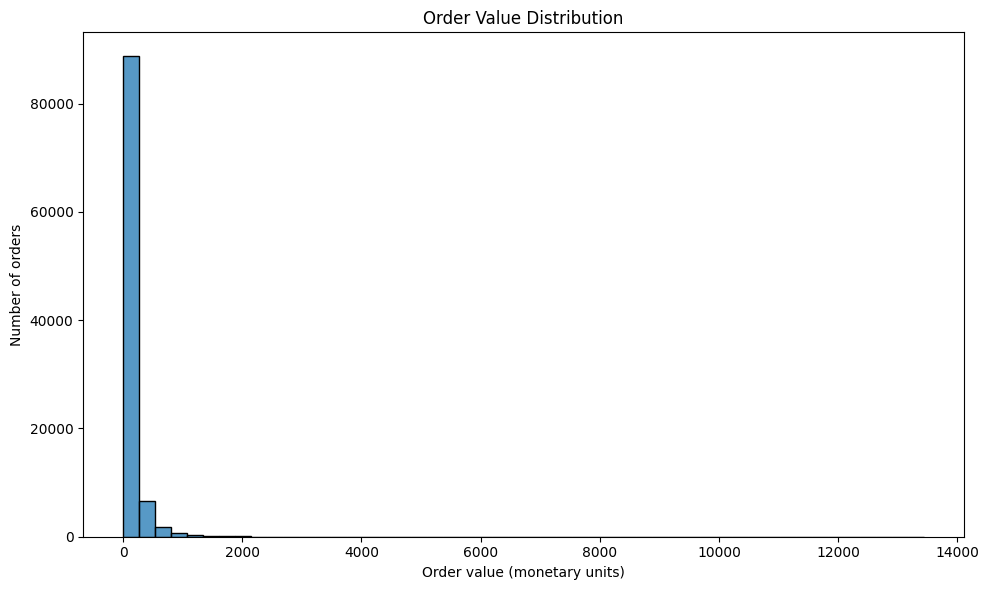

In [7]:
# =============================================================================
# 4.5 CHART 1 — ORDER VALUE DISTRIBUTION
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    order_sales["order_sales"].dropna(),
    bins=50,
    ax=ax,
)
ax.set_title("Order Value Distribution")
ax.set_xlabel("Order value (monetary units)")
ax.set_ylabel("Number of orders")
fig.tight_layout()
plt.show()

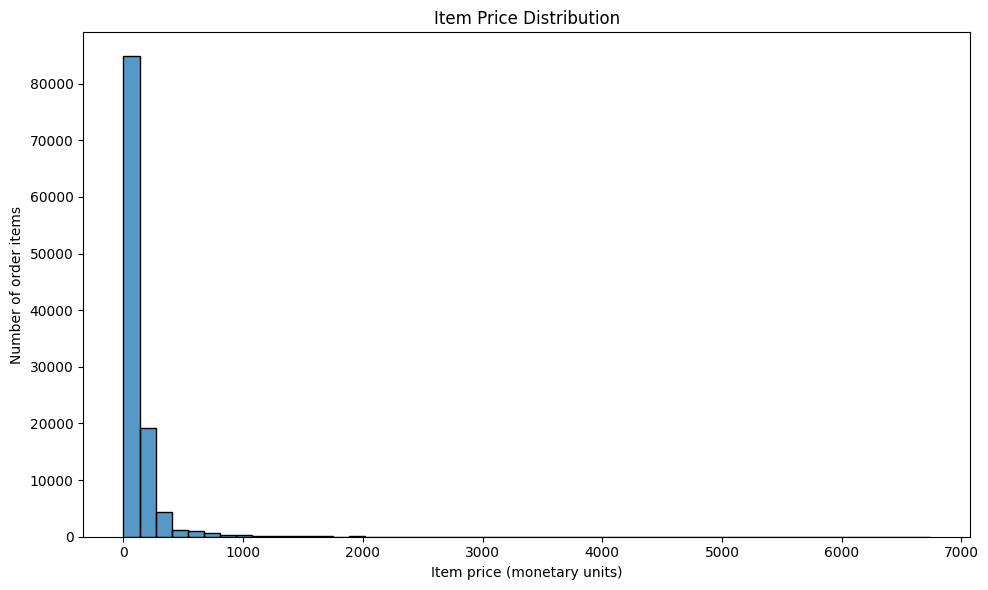

In [8]:
# =============================================================================
# 4.6 CHART 2 — ITEM PRICE DISTRIBUTION
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    order_items_eda["price"].dropna(),
    bins=50,
    ax=ax,
)
ax.set_title("Item Price Distribution")
ax.set_xlabel("Item price (monetary units)")
ax.set_ylabel("Number of order items")
fig.tight_layout()
plt.show()

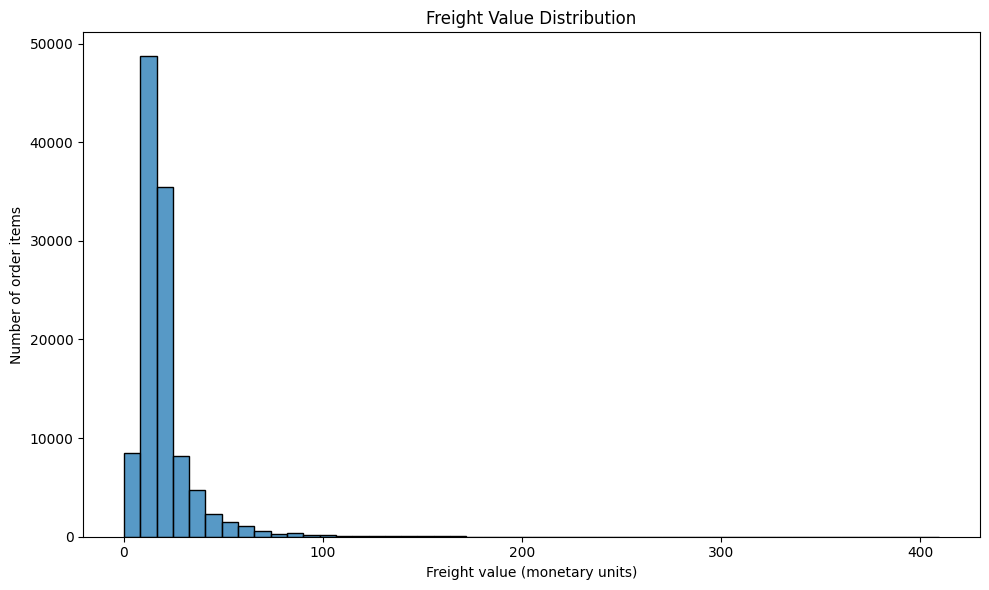

In [9]:
# =============================================================================
# 4.7 CHART 3 — FREIGHT VALUE DISTRIBUTION
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    order_items_eda["freight_value"].dropna(),
    bins=50,
    ax=ax,
)
ax.set_title("Freight Value Distribution")
ax.set_xlabel("Freight value (monetary units)")
ax.set_ylabel("Number of order items")
fig.tight_layout()
plt.show()

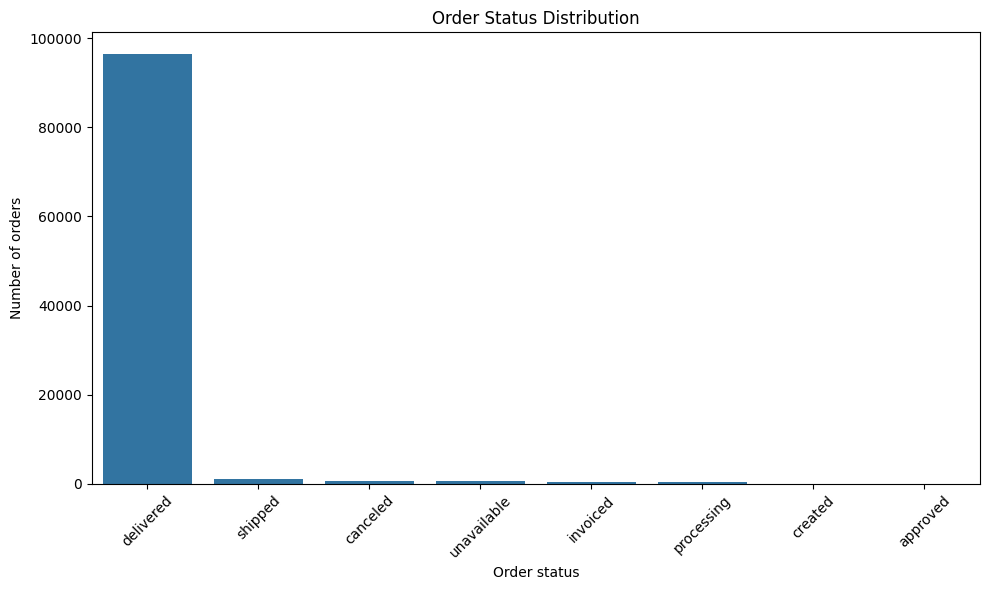

In [10]:
# =============================================================================
# 4.8 CHART 4 — ORDER STATUS DISTRIBUTION
# =============================================================================

order_status_counts = (
    orders_eda["order_status"]
    .fillna("Missing")
    .value_counts()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    x=order_status_counts.index,
    y=order_status_counts.values,
    ax=ax,
)
ax.set_title("Order Status Distribution")
ax.set_xlabel("Order status")
ax.set_ylabel("Number of orders")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

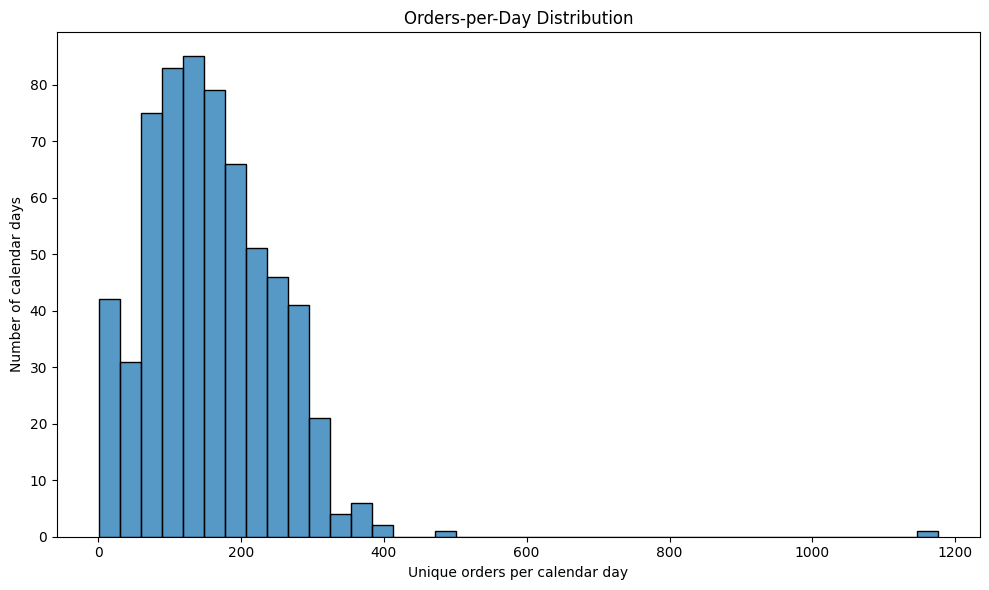

In [11]:
# =============================================================================
# 4.9 CHART 5 — ORDERS-PER-DAY DISTRIBUTION
# =============================================================================

orders_with_valid_dates = orders_eda.dropna(
    subset=["order_id", "order_purchase_timestamp"]
)[["order_id", "order_purchase_timestamp"]].drop_duplicates("order_id")

orders_per_day = (
    orders_with_valid_dates
    .assign(order_date=lambda frame: frame["order_purchase_timestamp"].dt.floor("D"))
    .groupby("order_date", as_index=False)["order_id"]
    .nunique()
    .rename(columns={"order_id": "order_count"})
)

assert pd.api.types.is_datetime64_any_dtype(
    orders_eda["order_purchase_timestamp"]
)
assert orders_per_day["order_date"].dt.hour.eq(0).all()
assert orders_per_day["order_count"].sum() == orders_with_valid_dates["order_id"].nunique()

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    orders_per_day["order_count"],
    bins=40,
    ax=ax,
)
ax.set_title("Orders-per-Day Distribution")
ax.set_xlabel("Unique orders per calendar day")
ax.set_ylabel("Number of calendar days")
fig.tight_layout()
plt.show()

In [12]:
# =============================================================================
# 4.10 ANOMALY DETECTION — IQR METHOD
# =============================================================================

def calculate_iqr_bounds(series):
    clean_series = series.dropna()
    q1 = clean_series.quantile(0.25)
    q3 = clean_series.quantile(0.75)
    iqr = q3 - q1
    return {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": q1 - 1.5 * iqr,
        "Upper Bound": q3 + 1.5 * iqr,
    }


def high_anomalies(frame, column, bounds):
    return frame[frame[column] > bounds["Upper Bound"]].copy()


order_value_bounds = calculate_iqr_bounds(order_sales["order_sales"])
item_price_bounds = calculate_iqr_bounds(order_items_eda["price"])
freight_bounds = calculate_iqr_bounds(order_items_eda["freight_value"])
item_count_bounds = calculate_iqr_bounds(order_sales["order_item_count"])

order_value_anomalies = high_anomalies(
    order_sales, "order_sales", order_value_bounds
)
item_price_anomalies = high_anomalies(
    order_items_eda, "price", item_price_bounds
)
freight_anomalies = high_anomalies(
    order_items_eda, "freight_value", freight_bounds
)
item_count_anomalies = order_sales[
    ~order_sales["order_item_count"].between(
        item_count_bounds["Lower Bound"],
        item_count_bounds["Upper Bound"],
    )
].copy()

anomaly_definitions = [
    ("Extremely high-value orders", "Order value", order_value_bounds, order_value_anomalies),
    ("Extremely high-priced items", "Item price", item_price_bounds, item_price_anomalies),
    ("Extreme freight values", "Freight value", freight_bounds, freight_anomalies),
    ("Unusual order-item counts", "Order-item count", item_count_bounds, item_count_anomalies),
]

anomaly_summary = pd.DataFrame([
    {
        "Anomaly Type": anomaly_type,
        "Metric": metric_label,
        "Q1": bounds["Q1"],
        "Q3": bounds["Q3"],
        "IQR": bounds["IQR"],
        "Lower Bound": bounds["Lower Bound"],
        "Upper Bound": bounds["Upper Bound"],
        "Anomaly Count": len(anomalies),
    }
    for anomaly_type, metric_label, bounds, anomalies in anomaly_definitions
])

display(anomaly_summary)

,Anomaly Type,Metric,Q1,Q3,IQR,Lower Bound,Upper Bound,Anomaly Count
0,Extremely high-value orders,Order value,45.90,149.90,104.00,-110.100,305.900,7913
1,Extremely high-priced items,Item price,39.90,134.90,95.00,-102.600,277.400,8427
2,Extreme freight values,Freight value,13.08,21.15,8.07,0.975,33.255,11613
3,Unusual order-item counts,Order-item count,1.00,1.00,0.00,1.000,1.000,9803


In [13]:
# =============================================================================
# 4.11 TOP 20 ANOMALIES
# =============================================================================

print("EXTREMELY HIGH-VALUE ORDERS")
display(
    order_value_anomalies[
        [
            "order_id",
            "order_sales",
            "order_item_count",
            "order_status",
            "order_purchase_timestamp",
        ]
    ].sort_values("order_sales", ascending=False).head(20)
)

print("EXTREMELY HIGH-PRICED ITEMS")
display(
    item_price_anomalies[
        ["order_id", "order_item_id", "price", "freight_value"]
    ].sort_values("price", ascending=False).head(20)
)

print("EXTREME FREIGHT VALUES")
display(
    freight_anomalies[
        ["order_id", "order_item_id", "price", "freight_value"]
    ].sort_values("freight_value", ascending=False).head(20)
)

print("UNUSUAL ORDER-ITEM COUNTS")
display(
    item_count_anomalies[
        ["order_id", "order_item_count", "order_sales", "order_status"]
    ].sort_values("order_item_count", ascending=False).head(20)
)

EXTREMELY HIGH-VALUE ORDERS


,order_id,order_sales,order_item_count,order_status,order_purchase_timestamp
1455,03caa2c082116e1d31e67e9ae3700499,13440.00,8,delivered,2017-09-29 15:24:52
44467,736e1922ae60d0d6a89247b851902527,7160.00,4,delivered,2018-07-15 14:49:44
3130,0812eb902a67711a1cb742b3cdaa65ae,6735.00,1,delivered,2017-02-12 20:37:36
98298,fefacc66af859508bf1a7934eab1e97f,6729.00,1,delivered,2018-07-25 18:10:17
94439,f5136e38d1a14a4dbd87dff67da82701,6499.00,1,delivered,2017-05-24 18:14:34
17114,2cc9089445046817a7539d90805e6e5a,5934.60,6,delivered,2017-11-24 11:03:35
65046,a96610ab360d42a2e5335a3998b4718a,4799.00,1,delivered,2017-04-01 15:58:40
9868,199af31afc78c699f0dbf71fb178d4d4,4690.00,1,delivered,2017-04-18 18:50:13
69531,b4c4b76c642808cbe472a32b86cddc95,4599.90,2,canceled,2018-07-12 12:08:36
54353,8dbc85d1447242f3b127dda390d56e19,4590.00,1,delivered,2018-06-22 12:23:19


EXTREMELY HIGH-PRICED ITEMS


,order_id,order_item_id,price,freight_value
3556,0812eb902a67711a1cb742b3cdaa65ae,1,6735.00,194.31
112233,fefacc66af859508bf1a7934eab1e97f,1,6729.00,193.21
107841,f5136e38d1a14a4dbd87dff67da82701,1,6499.00,227.66
74336,a96610ab360d42a2e5335a3998b4718a,1,4799.00,151.34
11249,199af31afc78c699f0dbf71fb178d4d4,1,4690.00,74.34
62086,8dbc85d1447242f3b127dda390d56e19,1,4590.00,91.78
29193,426a9742b533fc6fed17d1fd6d143d7e,1,4399.87,113.45
45843,68101694e5c5dc7330c91e1bbc36214f,1,4099.99,75.27
78310,b239ca7cd485940b31882363b52e6674,1,4059.00,104.51
59137,86c4eab1571921a6a6e248ed312f5a5a,1,3999.90,17.01


EXTREME FREIGHT VALUES


,order_id,order_item_id,price,freight_value
73486,a77e1550db865202c56b19ddc6dc4d53,1,979.00,409.68
3303,076d1555fb53a89b0ef4d529e527a0f6,1,2338.08,375.28
28044,3fde74c28a3d5d618c00f26d51baafa0,1,2338.08,375.28
69797,9f49bd16053df810384e793386312674,1,1149.00,339.59
16731,264a7e199467906c0727394df82d1a6a,1,1050.00,338.30
87936,c7a07ddd52bbe18b61da49a8d89853d3,1,1050.00,322.10
5037,0b6230647ed16f4b3e70282dc4b5b87f,1,1050.00,321.88
3584,0822bcde10bb5d023755a71bc8f7797f,1,990.00,321.46
29787,43bdbd9dc0931d72befdf4765af6c442,1,3089.00,317.47
48320,6ddfbf514959b49b6410c01ad93054bb,1,1045.00,314.40


UNUSUAL ORDER-ITEM COUNTS


,order_id,order_item_count,order_sales,order_status
50137,8272b63d03f5f79c56e9e4120aec44ef,21,31.80,delivered
65715,ab14fdcfbe524636d65ee38360e22ce8,20,1974.00,delivered
10459,1b15974a0141d54e36626dca3fdc731a,20,2000.00,delivered
60941,9ef13efd6949e4573a18964dd1bbe7f5,15,765.00,delivered
25583,428a2f660dc84138d969ccd69a0ab6d5,15,982.35,delivered
59688,9bdc4d4c71aa1de4606060929dee888c,14,419.86,delivered
44594,73c8ab38f07dc94389065f7eba4f297a,14,826.00,delivered
21484,37ee401157a3a0b28c9c6d0ed8c3b24b,13,389.87,delivered
22378,3a213fcdfe7d98be74ea0dc05a8b31ae,12,1296.00,delivered
74094,c05d6a79e55da72ca780ce90364abed9,12,213.84,delivered


## 5. Time-Series Analysis

Use `order_purchase_timestamp` to analyze daily, monthly, quarterly, and yearly orders and sales.

### Required charts
1. Monthly sales trend
2. Monthly order trend
3. Quarterly sales trend
4. Daily sales trend

**Important:** Do not treat 2016 as directly comparable to a complete calendar year because the dataset has incomplete coverage at the beginning of the period.

In [14]:
# =============================================================================
# 5. TIME-SERIES ANALYSIS
# =============================================================================

# Use the validated order purchase timestamp as the primary time dimension.
# order_sales was created in Section 4 at one-row-per-order grain.

orders_ts = orders_eda.copy()
order_sales_ts = order_sales.copy()

orders_ts["order_purchase_timestamp"] = pd.to_datetime(
    orders_ts["order_purchase_timestamp"],
    errors="coerce"
)

order_sales_ts["order_purchase_timestamp"] = pd.to_datetime(
    order_sales_ts["order_purchase_timestamp"],
    errors="coerce"
)

# Validate the required timestamp
assert orders_ts["order_purchase_timestamp"].notna().any(), (
    "No valid order_purchase_timestamp values found."
)

assert order_sales_ts["order_purchase_timestamp"].notna().any(), (
    "No valid order_purchase_timestamp values found in order_sales."
)

# Validate one row per order in the order-level sales table
assert order_sales_ts["order_id"].is_unique, (
    "order_sales_ts must contain exactly one row per order_id."
)

print("=" * 80)
print("PHASE 10 — TIME-SERIES ANALYSIS")
print("=" * 80)

print(
    f"Order records available       : {len(orders_ts):,}"
)

print(
    f"Item-backed order records     : {len(order_sales_ts):,}"
)

print(
    "Purchase date range           : "
    f"{orders_ts['order_purchase_timestamp'].min():%Y-%m-%d} "
    f"to "
    f"{orders_ts['order_purchase_timestamp'].max():%Y-%m-%d}"
)

PHASE 10 — TIME-SERIES ANALYSIS
Order records available       : 99,441
Item-backed order records     : 98,666
Purchase date range           : 2016-09-04 to 2018-10-17


In [15]:
# =============================================================================
# 5.1 DAILY ORDERS
# =============================================================================

orders_for_time_series = (
    orders_ts
    .dropna(subset=["order_id", "order_purchase_timestamp"])
    [["order_id", "order_purchase_timestamp"]]
    .drop_duplicates("order_id")
)

daily_orders = (
    orders_for_time_series
    .assign(
        order_date=lambda df:
            df["order_purchase_timestamp"].dt.floor("D")
    )
    .groupby("order_date", as_index=False)
    .agg(
        orders=("order_id", "nunique")
    )
    .sort_values("order_date")
)

assert daily_orders["order_date"].is_unique
assert daily_orders["orders"].sum() == orders_ts["order_id"].nunique(), (
    "Daily order counts do not reconcile to the unique order population."
)


# =============================================================================
# 5.2 DAILY SALES
# =============================================================================

daily_sales = (
    order_sales_ts
    .dropna(subset=["order_purchase_timestamp"])
    .assign(
        order_date=lambda df:
            df["order_purchase_timestamp"].dt.floor("D")
    )
    .groupby("order_date", as_index=False)
    .agg(
        sales=("order_sales", "sum")
    )
    .sort_values("order_date")
)

assert daily_sales["order_date"].is_unique
assert np.isclose(
    daily_sales["sales"].sum(),
    order_sales_ts["order_sales"].sum()
), "Daily sales do not reconcile to total order-level sales."

print("Daily order aggregation : PASS")
print("Daily sales aggregation : PASS")

Daily order aggregation : PASS
Daily sales aggregation : PASS


In [16]:
# =============================================================================
# 5.3 MONTHLY ORDERS AND MONTHLY SALES
# =============================================================================

monthly_orders = (
    orders_for_time_series
    .assign(
        month=lambda df:
            df["order_purchase_timestamp"].dt.to_period("M")
    )
    .groupby("month", as_index=False)
    .agg(
        orders=("order_id", "nunique")
    )
    .sort_values("month")
)

monthly_sales = (
    order_sales_ts
    .dropna(subset=["order_purchase_timestamp"])
    .assign(
        month=lambda df:
            df["order_purchase_timestamp"].dt.to_period("M")
    )
    .groupby("month", as_index=False)
    .agg(
        sales=("order_sales", "sum")
    )
    .sort_values("month")
)

# Convert Period values to timestamps for plotting and display.
monthly_orders["month"] = monthly_orders["month"].dt.to_timestamp()
monthly_sales["month"] = monthly_sales["month"].dt.to_timestamp()

assert monthly_orders["month"].is_unique
assert monthly_sales["month"].is_unique
assert monthly_orders["orders"].sum() == orders_ts["order_id"].nunique(), (
    "Monthly order counts do not reconcile to the unique order population."
)
assert np.isclose(
    monthly_sales["sales"].sum(),
    order_sales_ts["order_sales"].sum()
), "Monthly sales do not reconcile to total order-level sales."

print("Monthly order aggregation : PASS")
print("Monthly sales aggregation : PASS")

Monthly order aggregation : PASS
Monthly sales aggregation : PASS


In [17]:
# =============================================================================
# 5.5 QUARTERLY SALES
# =============================================================================

quarterly_sales = (
    order_sales_ts
    .dropna(subset=["order_purchase_timestamp"])
    .assign(
        quarter=lambda df:
            df["order_purchase_timestamp"].dt.to_period("Q")
    )
    .groupby("quarter", as_index=False)
    .agg(
        sales=("order_sales", "sum")
    )
    .sort_values("quarter")
)


# =============================================================================
# 5.6 YEARLY SALES
# =============================================================================

yearly_sales = (
    order_sales_ts
    .dropna(subset=["order_purchase_timestamp"])
    .assign(
        year=lambda df:
            df["order_purchase_timestamp"].dt.year
    )
    .groupby("year", as_index=False)
    .agg(
        sales=("order_sales", "sum")
    )
    .sort_values("year")
)


# Convert quarterly Period values into timestamps for plotting.
quarterly_sales["quarter"] = (
    quarterly_sales["quarter"]
    .dt.start_time
)


# =============================================================================
# VALIDATION
# =============================================================================

assert quarterly_sales["quarter"].is_unique
assert yearly_sales["year"].is_unique

assert np.isclose(
    quarterly_sales["sales"].sum(),
    order_sales_ts["order_sales"].sum()
), (
    "Quarterly sales do not reconcile to total order-level sales."
)

assert np.isclose(
    yearly_sales["sales"].sum(),
    order_sales_ts["order_sales"].sum()
), (
    "Yearly sales do not reconcile to total order-level sales."
)


print("=" * 80)
print("QUARTERLY & YEARLY SALES VALIDATION")
print("=" * 80)

print(f"Quarters : {len(quarterly_sales):,}")
print(f"Years    : {len(yearly_sales):,}")

print("Quarterly sales aggregation : PASS")
print("Yearly sales aggregation    : PASS")

QUARTERLY & YEARLY SALES VALIDATION
Quarters : 9
Years    : 3
Quarterly sales aggregation : PASS
Yearly sales aggregation    : PASS


In [18]:
# =============================================================================
# 5.7 TIME-SERIES TABLES
# =============================================================================

print("=" * 80)
print("DAILY ORDERS")
print("=" * 80)

display(daily_orders.head(10))


print("=" * 80)
print("DAILY SALES")
print("=" * 80)

display(daily_sales.head(10))


print("=" * 80)
print("MONTHLY ORDERS")
print("=" * 80)

display(monthly_orders)


print("=" * 80)
print("MONTHLY SALES")
print("=" * 80)

display(monthly_sales)


print("=" * 80)
print("QUARTERLY SALES")
print("=" * 80)

display(quarterly_sales)


print("=" * 80)
print("YEARLY SALES")
print("=" * 80)

display(yearly_sales)

DAILY ORDERS


,order_date,orders
0,2016-09-04,1
1,2016-09-05,1
2,2016-09-13,1
3,2016-09-15,1
4,2016-10-02,1
5,2016-10-03,8
6,2016-10-04,63
7,2016-10-05,47
8,2016-10-06,51
9,2016-10-07,46


DAILY SALES


,order_date,sales
0,2016-09-04,72.89
1,2016-09-05,59.50
2,2016-09-15,134.97
3,2016-10-02,100.00
4,2016-10-03,463.48
5,2016-10-04,9940.96
6,2016-10-05,8343.25
7,2016-10-06,7960.51
8,2016-10-07,7228.05
9,2016-10-08,8441.85


MONTHLY ORDERS


...

,month,sales
0,2016-09-01,267.36
1,2016-10-01,49507.66
2,2016-12-01,10.90
3,2017-01-01,120312.87
4,2017-02-01,247303.02
5,2017-03-01,374344.30
6,2017-04-01,359927.23
7,2017-05-01,506071.14
8,2017-06-01,433038.60
9,2017-07-01,498031.48


QUARTERLY SALES


,quarter,sales
0,2016-07-01,267.36
1,2016-10-01,49518.56
2,2017-01-01,741960.19
3,2017-04-01,1299036.97
4,2017-07-01,1696404.85
5,2017-10-01,2418404.97
6,2018-01-01,2777422.51
7,2018-04-01,2858289.74
8,2018-07-01,1750338.55


YEARLY SALES


,year,sales
0,2016,49785.92
1,2017,6155806.98
2,2018,7386050.80


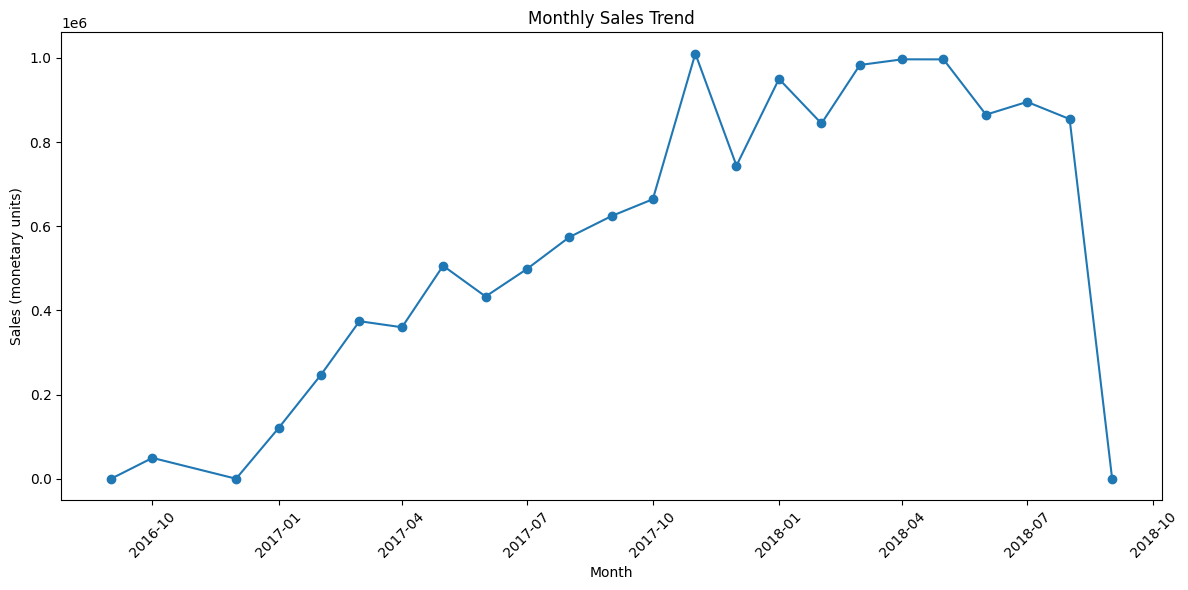

In [19]:
# =============================================================================
# 5.8 CHART 1 — MONTHLY SALES TREND
# =============================================================================

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["month"],
    monthly_sales["sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales (monetary units)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

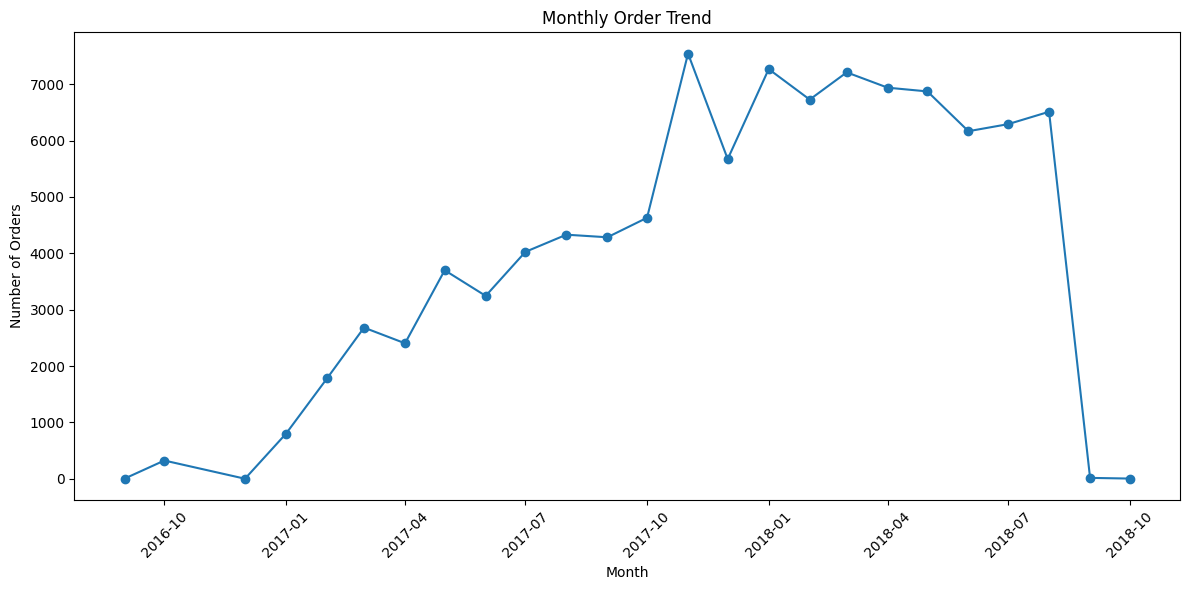

In [20]:
# =============================================================================
# 5.9 CHART 2 — MONTHLY ORDER TREND
# =============================================================================

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_orders["month"],
    monthly_orders["orders"],
    marker="o"
)

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

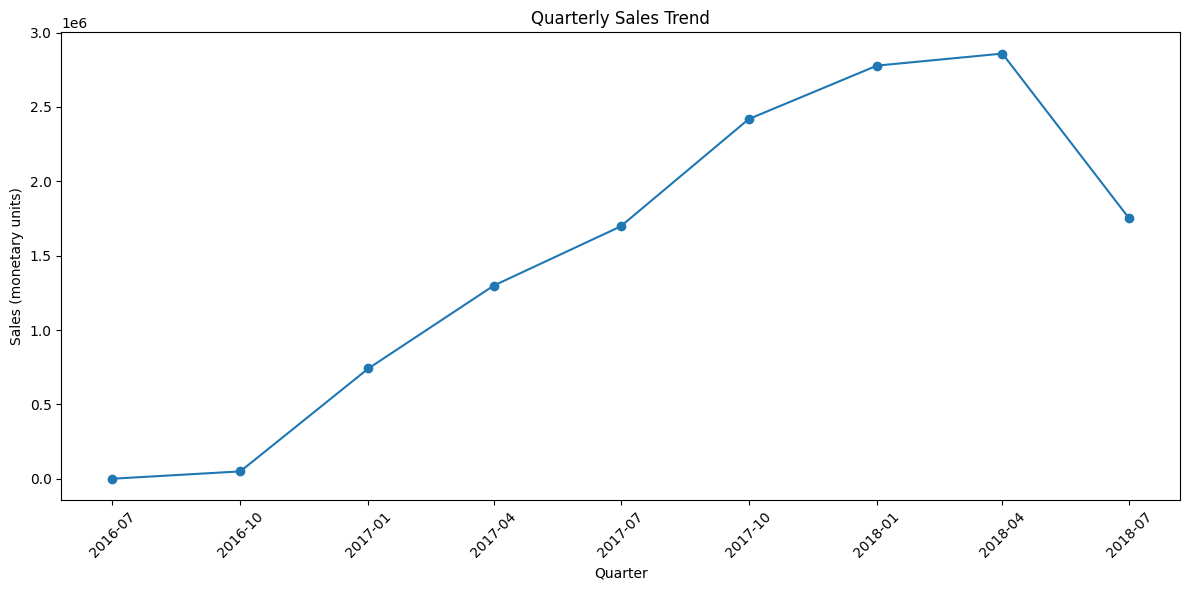

In [21]:
# =============================================================================
# 5.10 CHART 3 — QUARTERLY SALES TREND
# =============================================================================

plt.figure(figsize=(12, 6))

plt.plot(
    quarterly_sales["quarter"],
    quarterly_sales["sales"],
    marker="o"
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Sales (monetary units)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

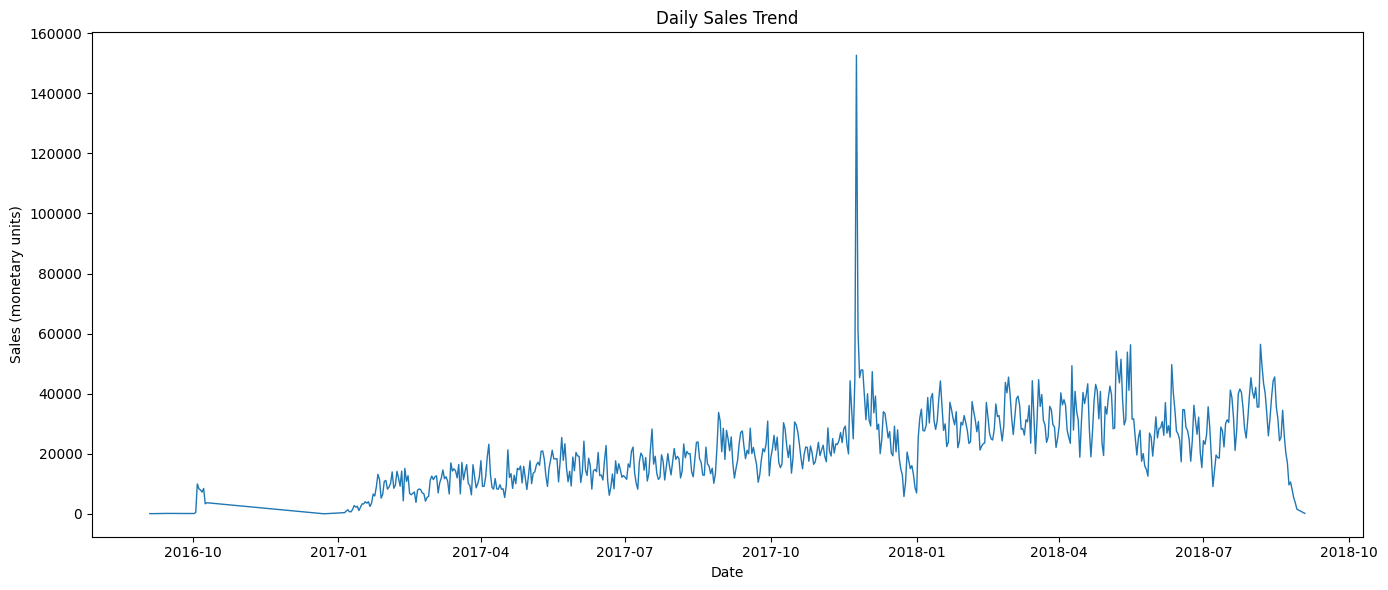

In [22]:
# =============================================================================
# 5.11 CHART 4 — DAILY SALES TREND
# =============================================================================

plt.figure(figsize=(14, 6))

plt.plot(
    daily_sales["order_date"],
    daily_sales["sales"],
    linewidth=1
)

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales (monetary units)")
plt.tight_layout()

plt.show()

In [23]:
# =============================================================================
# 5.12 2016 PARTIAL-YEAR COVERAGE
# =============================================================================

purchase_dates = orders_ts[
    "order_purchase_timestamp"
].dropna()

first_purchase_date = purchase_dates.min()
last_purchase_date = purchase_dates.max()

first_year = first_purchase_date.year
last_year = last_purchase_date.year

print("=" * 80)
print("TIME COVERAGE ASSESSMENT")
print("=" * 80)

print(f"First purchase date : {first_purchase_date:%Y-%m-%d}")
print(f"Last purchase date  : {last_purchase_date:%Y-%m-%d}")
print()

if first_year == 2016:

    print(
        "2016 is a partial observation period and must not be "
        "compared directly with a complete calendar year."
    )

    print(
        f"2016 observed period: "
        f"{first_purchase_date:%Y-%m-%d} "
        f"to "
        f"{first_purchase_date.replace(month=12, day=31):%Y-%m-%d}"
    )

else:

    print(
        f"First observed year is {first_year}; "
        "no 2016 partial-year adjustment is required."
    )

TIME COVERAGE ASSESSMENT
First purchase date : 2016-09-04
Last purchase date  : 2018-10-17

2016 is a partial observation period and must not be compared directly with a complete calendar year.
2016 observed period: 2016-09-04 to 2016-12-31


## 6. Seasonality Analysis

Analyze recurring patterns across comparable calendar periods, separate from directional trend over time.

- **Trend** is a directional change across chronological time.
- **Seasonality** is a recurring pattern across comparable months, quarters, weekdays, or weekend/weekday groups.

Month-of-year results aggregate comparable calendar months across available years. A single unusually high or low month is not treated as evidence of seasonality. Quarterly performance is reported for comparison but is not automatically interpreted as seasonal behavior.

Required charts:
1. Sales by month-of-year
2. Orders by month-of-year
3. Sales by weekday
4. Orders by weekday

In [24]:
# =============================================================================
# 6.1 SEASONALITY PREPARATION AND AGGREGATIONS
# =============================================================================

orders_seasonality = orders_ts.copy()
order_sales_seasonality = order_sales_ts.copy()

orders_seasonality["order_purchase_timestamp"] = pd.to_datetime(
    orders_seasonality["order_purchase_timestamp"],
    errors="coerce",
)
order_sales_seasonality["order_purchase_timestamp"] = pd.to_datetime(
    order_sales_seasonality["order_purchase_timestamp"],
    errors="coerce",
)

orders_seasonality = (
    orders_seasonality
    .dropna(subset=["order_id", "order_purchase_timestamp"])
    [["order_id", "order_purchase_timestamp"]]
    .drop_duplicates("order_id")
    .assign(
        month_of_year=lambda df: df["order_purchase_timestamp"].dt.month,
        weekday_number=lambda df: df["order_purchase_timestamp"].dt.weekday,
        weekday=lambda df: df["order_purchase_timestamp"].dt.day_name(),
        is_weekend=lambda df: df["weekday_number"].isin([5, 6]),
    )
)

order_sales_seasonality = (
    order_sales_seasonality
    .dropna(subset=["order_id", "order_purchase_timestamp"])
    [["order_id", "order_purchase_timestamp", "order_sales"]]
    .drop_duplicates("order_id")
    .assign(
        month_of_year=lambda df: df["order_purchase_timestamp"].dt.month,
        quarter=lambda df: df["order_purchase_timestamp"].dt.quarter,
        weekday_number=lambda df: df["order_purchase_timestamp"].dt.weekday,
        weekday=lambda df: df["order_purchase_timestamp"].dt.day_name(),
        is_weekend=lambda df: df["weekday_number"].isin([5, 6]),
    )
)

month_names = list(pd.date_range("2000-01-01", periods=12, freq="MS").strftime("%B"))

month_of_year_sales = (
    order_sales_seasonality
    .groupby("month_of_year", as_index=False)
    .agg(sales=("order_sales", "sum"))
    .sort_values("month_of_year")
)
month_of_year_sales["month"] = month_of_year_sales["month_of_year"].map(
    dict(enumerate(month_names, start=1))
)

month_of_year_orders = (
    orders_seasonality
    .groupby("month_of_year", as_index=False)
    .agg(orders=("order_id", "nunique"))
    .sort_values("month_of_year")
)
month_of_year_orders["month"] = month_of_year_orders["month_of_year"].map(
    dict(enumerate(month_names, start=1))
)

quarter_performance = (
    order_sales_seasonality
    .groupby("quarter", as_index=False)
    .agg(
        sales=("order_sales", "sum"),
        orders=("order_id", "nunique"),
    )
    .sort_values("quarter")
)

weekday_performance = (
    order_sales_seasonality
    .groupby(["weekday_number", "weekday"], as_index=False)
    .agg(
        sales=("order_sales", "sum"),
        orders=("order_id", "nunique"),
    )
    .sort_values("weekday_number")
)

weekend_weekday_comparison = (
    order_sales_seasonality
    .assign(day_type=lambda df: np.where(df["is_weekend"], "Weekend", "Weekday"))
    .groupby("day_type", as_index=False)
    .agg(
        sales=("order_sales", "sum"),
        orders=("order_id", "nunique"),
    )
)
weekend_weekday_comparison["day_type"] = pd.Categorical(
    weekend_weekday_comparison["day_type"],
    categories=["Weekday", "Weekend"],
    ordered=True,
)
weekend_weekday_comparison = weekend_weekday_comparison.sort_values("day_type")

assert month_of_year_sales["month_of_year"].is_unique
assert month_of_year_orders["month_of_year"].is_unique
assert weekday_performance["weekday_number"].tolist() == list(range(7))
assert month_of_year_orders["orders"].sum() == orders_seasonality["order_id"].nunique()
assert np.isclose(
    month_of_year_sales["sales"].sum(),
    order_sales_seasonality["order_sales"].sum(),
)
assert quarter_performance["orders"].sum() == order_sales_seasonality["order_id"].nunique()
assert np.isclose(
    quarter_performance["sales"].sum(),
    order_sales_seasonality["order_sales"].sum(),
)
assert weekday_performance["orders"].sum() == order_sales_seasonality["order_id"].nunique()
assert np.isclose(
    weekday_performance["sales"].sum(),
    order_sales_seasonality["order_sales"].sum(),
)
assert weekend_weekday_comparison["orders"].sum() == order_sales_seasonality["order_id"].nunique()

print("Seasonality aggregations and reconciliations : PASS")

Seasonality aggregations and reconciliations : PASS


In [25]:
# =============================================================================
# 6.2 SEASONALITY TABLES
# =============================================================================

display(month_of_year_sales)
display(month_of_year_orders)
display(quarter_performance)
display(weekday_performance)
display(weekend_weekday_comparison)

,month_of_year,sales,month
0,1,1070343.23,January
1,2,1091481.73,February
2,3,1357557.74,March
3,4,1356574.98,April
4,5,1502588.82,May
5,6,1298162.91,June
6,7,1393538.70,July
7,8,1428658.01,August
8,9,624814.05,September
9,10,713727.09,October


,month_of_year,orders,month
0,1,8069,January
1,2,8508,February
2,3,9893,March
3,4,9343,April
4,5,10573,May
5,6,9412,June
6,7,10318,July
7,8,10843,August
8,9,4305,September
9,10,4959,October


,quarter,sales,orders
0,1,3519382.70,26265
1,2,4157326.71,29215
2,3,3447010.76,25234
3,4,2467923.53,17952


,weekday_number,weekday,sales,orders
0,0,Monday,2230812.51,16068
1,1,Tuesday,2172647.82,15831
2,2,Wednesday,2113843.59,15425
3,3,Thursday,2018615.78,14639
4,4,Friday,1962426.75,14002
5,5,Saturday,1504018.36,10813
6,6,Sunday,1589278.89,11888


,day_type,sales,orders
0,Weekday,10498346.45,75965
1,Weekend,3093297.25,22701


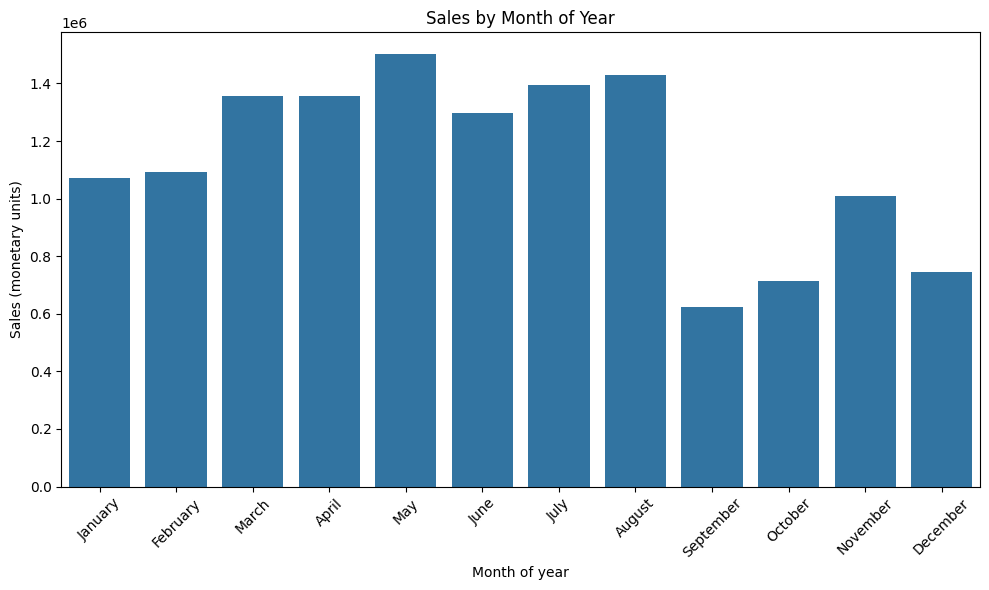

In [26]:
# =============================================================================
# 6.3 CHART 1 — SALES BY MONTH-OF-YEAR
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=month_of_year_sales,
    x="month",
    y="sales",
    ax=ax,
)
ax.set_title("Sales by Month of Year")
ax.set_xlabel("Month of year")
ax.set_ylabel("Sales (monetary units)")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

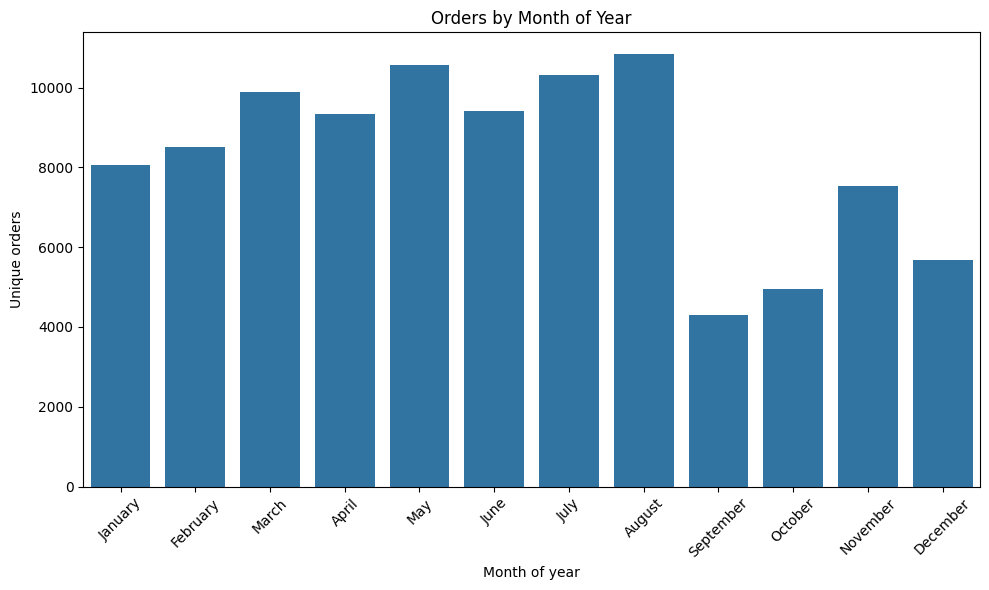

In [27]:
# =============================================================================
# 6.4 CHART 2 — ORDERS BY MONTH-OF-YEAR
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=month_of_year_orders,
    x="month",
    y="orders",
    ax=ax,
)
ax.set_title("Orders by Month of Year")
ax.set_xlabel("Month of year")
ax.set_ylabel("Unique orders")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

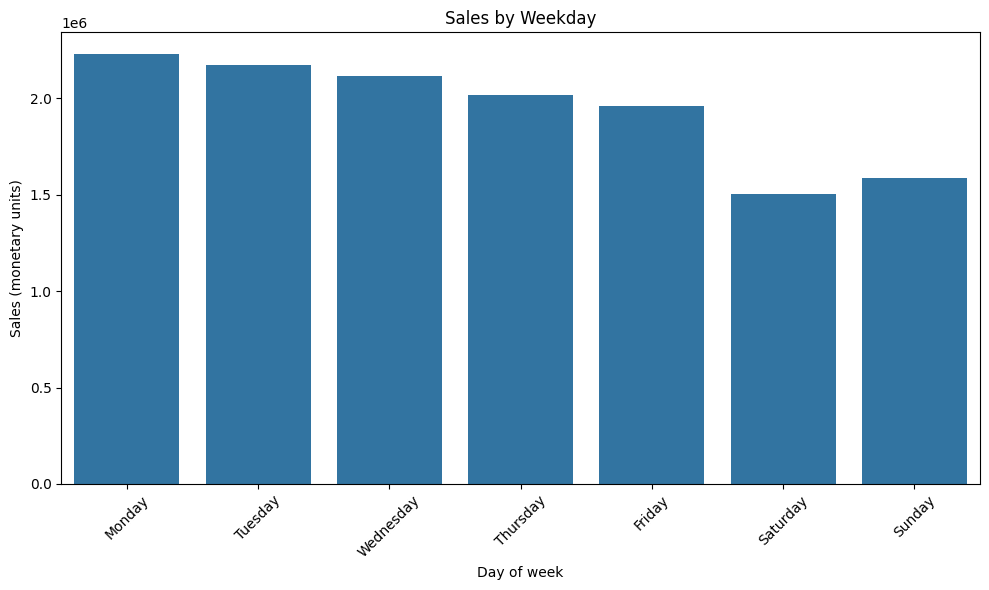

In [28]:
# =============================================================================
# 6.5 CHART 3 — SALES BY WEEKDAY
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=weekday_performance,
    x="weekday",
    y="sales",
    order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
    ax=ax,
)
ax.set_title("Sales by Weekday")
ax.set_xlabel("Day of week")
ax.set_ylabel("Sales (monetary units)")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

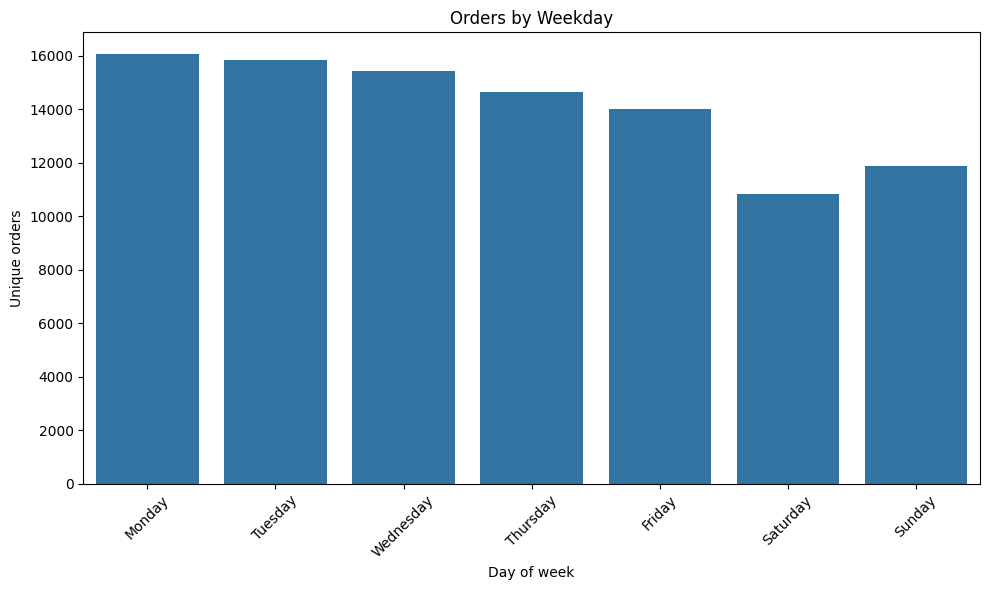

In [29]:
# =============================================================================
# 6.6 CHART 4 — ORDERS BY WEEKDAY
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=weekday_performance,
    x="weekday",
    y="orders",
    order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
    ax=ax,
)
ax.set_title("Orders by Weekday")
ax.set_xlabel("Day of week")
ax.set_ylabel("Unique orders")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

## 7. Category & Product Analysis

Analyze translated product categories, category revenue contribution, rankings, concentration, top/bottom products, product sales distribution, and Pareto behavior.

### Required charts
- Top 10 categories by sales
- Bottom 10 categories by sales
- Category revenue share
- Category ranking
- Top 10 products
- Top 20 products
- Product revenue distribution
- Product concentration/Pareto chart

Use `product_ranking.csv` for SQL cross-validation.

In [30]:
# =============================================================================
# 7.1 CATEGORY PREPARATION AND ANALYSIS
# =============================================================================

category_source = order_items_eda.copy()

if "product_category_name_english" in category_source.columns:
    category_field_used = "product_category_name_english"
    category_source["category"] = category_source[category_field_used]
else:
    available_category_fields = [
        field
        for field in ["product_category_name", "product_category"]
        if field in category_source.columns
    ]
    if not available_category_fields:
        raise KeyError(
            "No supported product category field is available in order_items."
        )
    category_field_used = available_category_fields[0]
    category_source["category"] = category_source[category_field_used]

if "sales_amount" in category_source.columns:
    revenue_field_used = "sales_amount"
elif "price" in category_source.columns:
    revenue_field_used = "price"
else:
    raise KeyError("No validated item-level sales field is available.")

missing_category_mask = (
    category_source["category"].isna()
    | category_source["category"].astype("string").str.strip().eq("")
)
missing_category_count = int(missing_category_mask.sum())
category_source["category"] = (
    category_source["category"]
    .astype("string")
    .str.strip()
    .fillna("Unknown / Untranslated")
    .replace("", "Unknown / Untranslated")
)

category_source[revenue_field_used] = pd.to_numeric(
    category_source[revenue_field_used],
    errors="coerce",
)
category_source = category_source.dropna(subset=[revenue_field_used]).copy()

total_category_sales = category_source[revenue_field_used].sum()
category_summary = (
    category_source
    .groupby("category", as_index=False)
    .agg(
        sales=(revenue_field_used, "sum"),
        order_count=("order_id", "nunique"),
        item_count=("order_id", "size"),
    )
    .sort_values(["sales", "category"], ascending=[False, True])
    .reset_index(drop=True)
)

category_summary["revenue_share_pct"] = (
    category_summary["sales"] / total_category_sales * 100
)
category_summary["sales_rank"] = (
    category_summary["sales"]
    .rank(method="first", ascending=False)
    .astype(int)
)
category_summary["cumulative_sales"] = category_summary["sales"].cumsum()
category_summary["cumulative_revenue_pct"] = (
    category_summary["cumulative_sales"] / total_category_sales * 100
)

category_summary = category_summary[
    [
        "category",
        "sales",
        "order_count",
        "item_count",
        "revenue_share_pct",
        "sales_rank",
        "cumulative_sales",
        "cumulative_revenue_pct",
    ]
]

category_count = len(category_summary)
pareto_reach = category_summary[
    category_summary["cumulative_revenue_pct"] >= 80
]
pareto_category_count = int(pareto_reach.index[0] + 1) if not pareto_reach.empty else category_count
pareto_revenue_pct = float(
    category_summary.iloc[pareto_category_count - 1]["cumulative_revenue_pct"]
)

category_top10 = category_summary.head(10).copy()
category_bottom10 = (
    category_summary
    .sort_values(["sales", "category"], ascending=[True, True])
    .head(10)
    .sort_values(["sales", "category"], ascending=[False, True])
    .copy()
)
category_ranking_subset = category_summary.head(20).copy()

pareto_summary = pd.DataFrame({
    "Metric": [
        "Total categories",
        "Categories required to reach approximately 80% of revenue",
        "Cumulative revenue at that category count (%)",
        "Total category sales (monetary units)",
    ],
    "Value": [
        category_count,
        pareto_category_count,
        pareto_revenue_pct,
        total_category_sales,
    ],
})

missing_category_assessment = pd.DataFrame({
    "Metric": [
        "Category field used",
        "Missing / untranslated item records",
        "Missing / untranslated share (%)",
        "Treatment",
    ],
    "Value": [
        category_field_used,
        missing_category_count,
        missing_category_count / len(order_items_eda) * 100,
        "Represented as Unknown / Untranslated",
    ],
})

assert category_field_used in order_items_eda.columns
assert not category_summary.empty
assert category_summary["category"].is_unique
assert (category_summary["sales"] >= 0).all()
assert np.isclose(category_summary["sales"].sum(), total_category_sales)
assert np.isclose(category_summary["revenue_share_pct"].sum(), 100)
assert category_summary["sales_rank"].tolist() == list(range(1, category_count + 1))
assert np.isclose(category_summary["cumulative_revenue_pct"].iloc[-1], 100)

print(
    f"Category analysis validated: {category_count} categories; "
    f"{missing_category_count:,} missing/untranslated item records."
)

Category analysis validated: 72 categories; 1,627 missing/untranslated item records.


In [31]:
# =============================================================================
# 7.2 CATEGORY OUTPUT TABLES
# =============================================================================

display(category_summary)
display(category_top10)
display(category_bottom10)
display(pareto_summary)
display(missing_category_assessment)

print(
    f"{pareto_category_count} categories account for approximately "
    f"{pareto_revenue_pct:.2f}% of category revenue."
)

,category,sales,order_count,item_count,revenue_share_pct,sales_rank,cumulative_sales,cumulative_revenue_pct
0,health_beauty,1258681.34,8836,9670,9.260700,1,1258681.34,9.260700
1,watches_gifts,1205005.68,5624,5991,8.865783,2,2463687.02,18.126483
2,bed_bath_table,1036988.68,9417,11115,7.629605,3,3500675.70,25.756088
3,sports_leisure,988048.97,7720,8641,7.269533,4,4488724.67,33.025621
4,computers_accessories,911954.32,6689,7827,6.709669,5,5400678.99,39.735290
...,...,...,...,...,...,...,...,...
67,flowers,1110.04,29,33,0.008167,68,13589300.29,99.982758
68,home_comfort_2,760.27,24,30,0.005594,69,13590060.56,99.988352
69,cds_dvds_musicals,730.00,12,14,0.005371,70,13590790.56,99.993723
70,fashion_childrens_clothes,569.85,8,8,0.004193,71,13591360.41,99.997916


,category,sales,order_count,item_count,revenue_share_pct,sales_rank,cumulative_sales,cumulative_revenue_pct
0,health_beauty,1258681.34,8836,9670,9.260700,1,1258681.34,9.260700
1,watches_gifts,1205005.68,5624,5991,8.865783,2,2463687.02,18.126483
2,bed_bath_table,1036988.68,9417,11115,7.629605,3,3500675.70,25.756088
3,sports_leisure,988048.97,7720,8641,7.269533,4,4488724.67,33.025621
4,computers_accessories,911954.32,6689,7827,6.709669,5,5400678.99,39.735290
5,furniture_decor,729762.49,6449,8334,5.369200,6,6130441.48,45.104489
6,cool_stuff,635290.85,3632,3796,4.674128,7,6765732.33,49.778618
7,housewares,632248.66,5884,6964,4.651745,8,7397980.99,54.430363
8,auto,592720.11,3897,4235,4.360916,9,7990701.10,58.791278
9,garden_tools,485256.46,3518,4347,3.570256,10,8475957.56,62.361534


,category,sales,order_count,item_count,revenue_share_pct,sales_rank,cumulative_sales,cumulative_revenue_pct
62,fashio_female_clothing,2803.64,39,48,0.020628,63,13580634.15,99.918998
63,fashion_sport,2119.51,27,30,0.015594,64,13582753.66,99.934592
64,la_cuisine,2054.99,13,14,0.015120,65,13584808.65,99.949711
65,arts_and_craftmanship,1814.01,23,24,0.013347,66,13586622.66,99.963058
66,diapers_and_hygiene,1567.59,27,39,0.011533,67,13588190.25,99.974591
67,flowers,1110.04,29,33,0.008167,68,13589300.29,99.982758
68,home_comfort_2,760.27,24,30,0.005594,69,13590060.56,99.988352
69,cds_dvds_musicals,730.00,12,14,0.005371,70,13590790.56,99.993723
70,fashion_childrens_clothes,569.85,8,8,0.004193,71,13591360.41,99.997916
71,security_and_services,283.29,2,2,0.002084,72,13591643.70,100.000000


,Metric,Value
0,Total categories,7.200000e+01
1,Categories required to reach approximately 80%...,1.800000e+01
2,Cumulative revenue at that category count (%),8.120169e+01
3,Total category sales (monetary units),1.359164e+07


,Metric,Value
0,Category field used,product_category_name_english
1,Missing / untranslated item records,1627
2,Missing / untranslated share (%),1.444296
3,Treatment,Represented as Unknown / Untranslated


18 categories account for approximately 81.20% of category revenue.


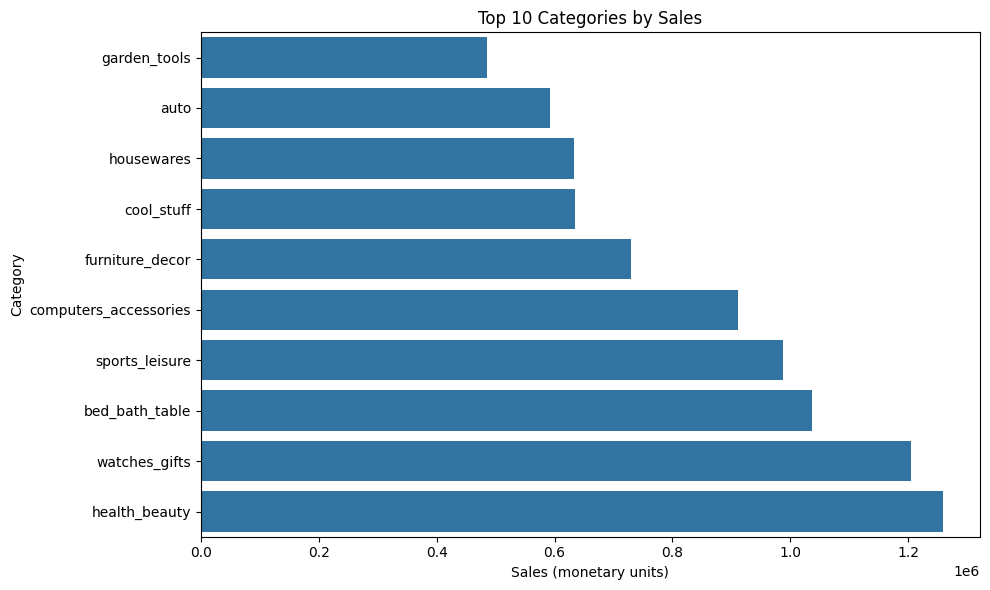

In [32]:
# =============================================================================
# 7.3 CHART 1 — TOP 10 CATEGORIES BY SALES
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=category_top10.sort_values("sales"),
    x="sales",
    y="category",
    ax=ax,
)
ax.set_title("Top 10 Categories by Sales")
ax.set_xlabel("Sales (monetary units)")
ax.set_ylabel("Category")
fig.tight_layout()
plt.show()

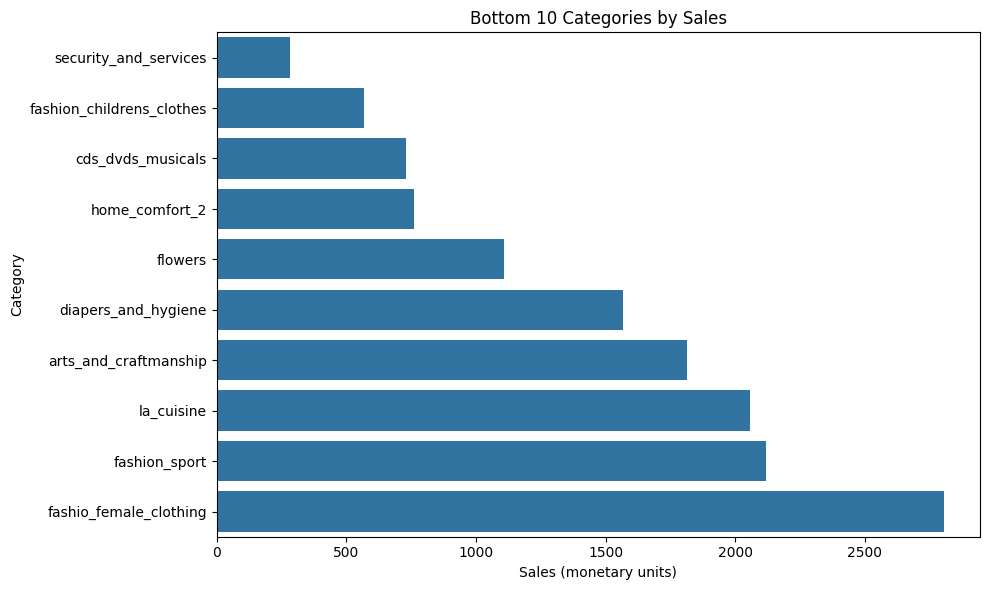

In [33]:
# =============================================================================
# 7.4 CHART 2 — BOTTOM 10 CATEGORIES BY SALES
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=category_bottom10.sort_values("sales"),
    x="sales",
    y="category",
    ax=ax,
)
ax.set_title("Bottom 10 Categories by Sales")
ax.set_xlabel("Sales (monetary units)")
ax.set_ylabel("Category")
fig.tight_layout()
plt.show()

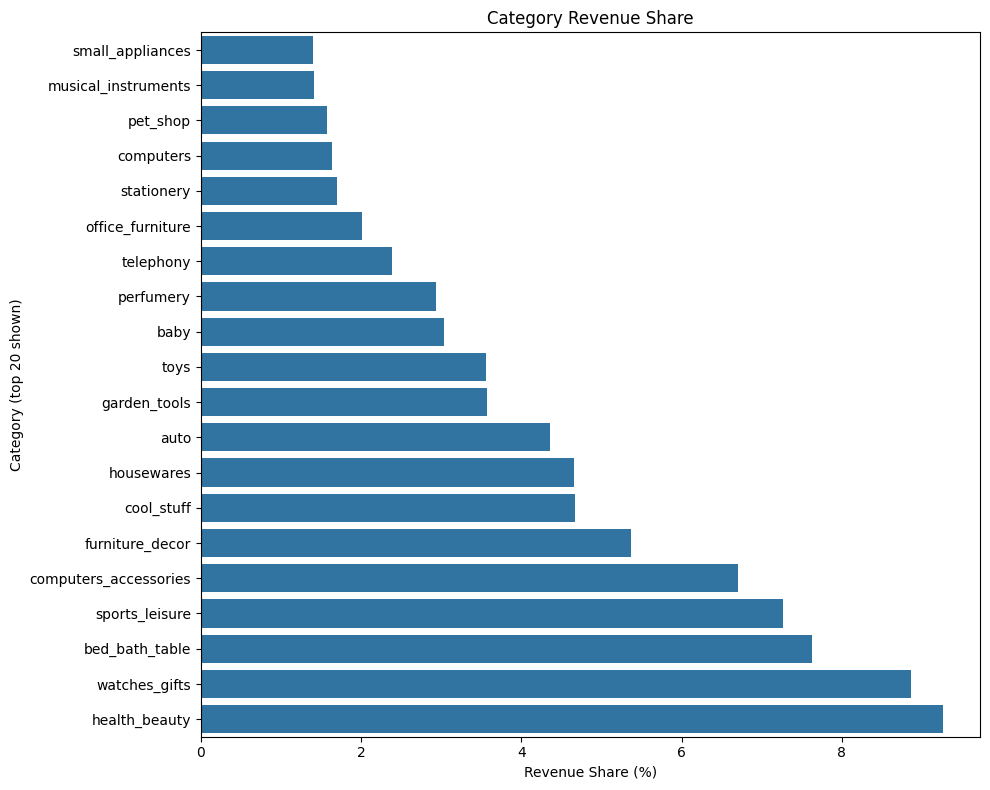

In [34]:
# =============================================================================
# 7.5 CHART 3 — CATEGORY REVENUE SHARE
# =============================================================================

category_share_chart = category_summary.head(20).sort_values("revenue_share_pct")
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(
    data=category_share_chart,
    x="revenue_share_pct",
    y="category",
    ax=ax,
)
ax.set_title("Category Revenue Share")
ax.set_xlabel("Revenue Share (%)")
ax.set_ylabel("Category (top 20 shown)")
fig.tight_layout()
plt.show()

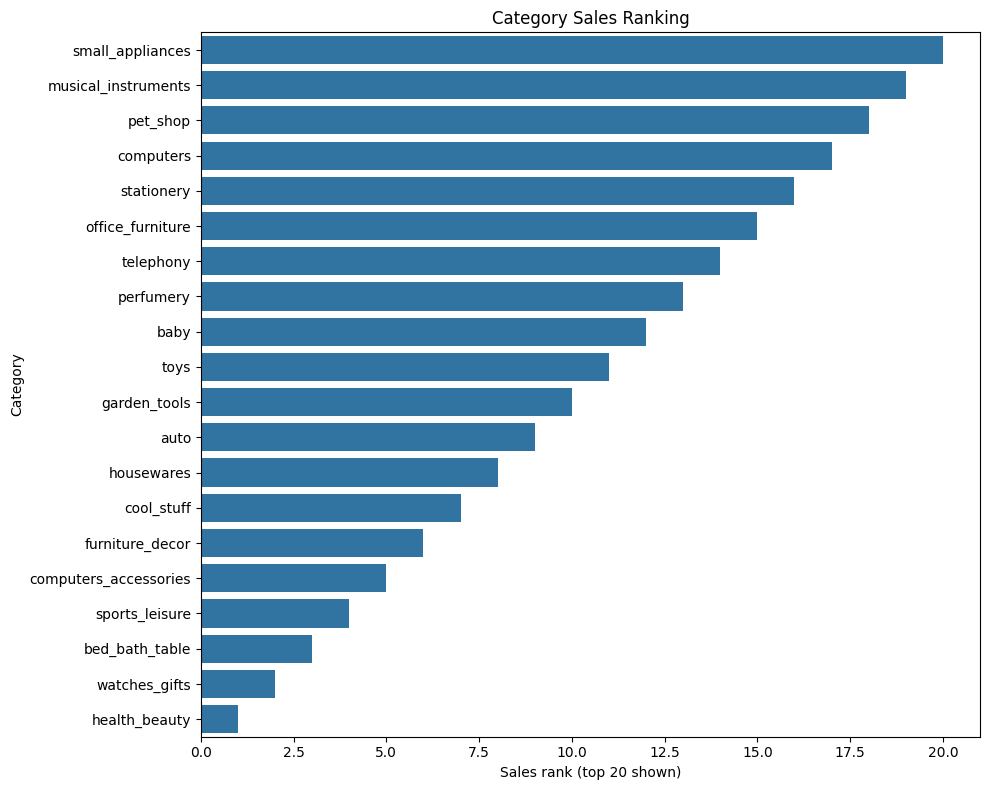

In [35]:
# =============================================================================
# 7.6 CHART 4 — CATEGORY RANKING
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(
    data=category_ranking_subset.sort_values("sales"),
    x="sales_rank",
    y="category",
    ax=ax,
)
ax.set_title("Category Sales Ranking")
ax.set_xlabel("Sales rank (top 20 shown)")
ax.set_ylabel("Category")
fig.tight_layout()
plt.show()

## 8. Product Analysis

Analyze product-level sales performance using the validated `sales_amount` field and `product_id`. The complete product summary is retained for analysis; charts use readable top-ranked subsets where necessary.

In [36]:
# =============================================================================
# 8.1 PRODUCT ANALYSIS — PREPARATION, METRICS & SQL CROSS-VALIDATION
# =============================================================================

print("=" * 80)
print("PHASE 10 — PRODUCT ANALYSIS")
print("=" * 80)

# -----------------------------------------------------------------------------
# 1. Validate source data
# -----------------------------------------------------------------------------

required_fields = ["product_id", "order_id", "sales_amount"]

missing_fields = [
    col for col in required_fields
    if col not in order_items_eda.columns
]

if missing_fields:
    raise KeyError(
        "Missing required fields in order_items_eda: "
        + ", ".join(missing_fields)
    )

product_sales_source = order_items_eda[
    ["product_id", "order_id", "sales_amount"]
].copy()

product_sales_source["sales_amount"] = pd.to_numeric(
    product_sales_source["sales_amount"],
    errors="coerce"
)

product_sales_source = product_sales_source.dropna(
    subset=["product_id", "sales_amount"]
).copy()

product_sales_source["product_id"] = (
    product_sales_source["product_id"]
    .astype(str)
    .str.strip()
)

product_sales_source = product_sales_source[
    product_sales_source["product_id"].ne("")
].copy()

# -----------------------------------------------------------------------------
# 2. Product-level aggregation
# -----------------------------------------------------------------------------

product_summary = (
    product_sales_source
    .groupby("product_id", as_index=False)
    .agg(
        sales=("sales_amount", "sum"),
        order_count=("order_id", "nunique"),
        item_count=("product_id", "size")
    )
    .sort_values(
        ["sales", "product_id"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

# Ranking
product_summary["sales_rank"] = (
    product_summary["sales"]
    .rank(method="first", ascending=False)
    .astype(int)
)

# Revenue share
total_product_sales = product_summary["sales"].sum()

product_summary["revenue_share_pct"] = (
    product_summary["sales"] /
    total_product_sales *
    100
)

# Cumulative revenue
product_summary["cumulative_sales"] = (
    product_summary["sales"].cumsum()
)

product_summary["cumulative_revenue_pct"] = (
    product_summary["cumulative_sales"] /
    total_product_sales *
    100
)

# -----------------------------------------------------------------------------
# 3. Required product subsets
# -----------------------------------------------------------------------------

product_top10 = product_summary.head(10).copy()

product_top20 = product_summary.head(20).copy()

product_bottom10 = (
    product_summary
    .sort_values(
        ["sales", "product_id"],
        ascending=[True, True]
    )
    .head(10)
    .sort_values(
        ["sales", "product_id"],
        ascending=[False, True]
    )
    .copy()
)

# -----------------------------------------------------------------------------
# 4. Product population metrics
# -----------------------------------------------------------------------------

products_generating_sales = product_summary["product_id"].nunique()

products_in_master = (
    products["product_id"]
    .dropna()
    .astype(str)
    .str.strip()
    .nunique()
)

products_without_sales = max(
    products_in_master - products_generating_sales,
    0
)

# -----------------------------------------------------------------------------
# 5. Revenue concentration
# -----------------------------------------------------------------------------

top10_revenue_share = (
    product_top10["revenue_share_pct"].sum()
)

top20_revenue_share = (
    product_top20["revenue_share_pct"].sum()
)

products_80 = product_summary[
    product_summary["cumulative_revenue_pct"] >= 80
]

products_required_for_80 = (
    int(products_80.index[0] + 1)
    if not products_80.empty
    else products_generating_sales
)

product_concentration = pd.DataFrame({
    "Metric": [
        "Products generating sales",
        "Products in product master",
        "Products without observed sales",
        "Total product sales",
        "Top 10 revenue share (%)",
        "Top 20 revenue share (%)",
        "Products required for ~80% revenue"
    ],
    "Value": [
        products_generating_sales,
        products_in_master,
        products_without_sales,
        total_product_sales,
        top10_revenue_share,
        top20_revenue_share,
        products_required_for_80
    ]
})

# -----------------------------------------------------------------------------
# 6. SQL cross-validation
# -----------------------------------------------------------------------------

sql_ranking_path = (
    PROJECT_ROOT
    / "reports"
    / "sql"
    / "analytical_outputs"
    / "product_ranking.csv"
)

if not sql_ranking_path.is_file():
    raise FileNotFoundError(
        f"SQL product ranking file not found:\n{sql_ranking_path}"
    )

sql_product_ranking = pd.read_csv(sql_ranking_path)

required_sql_columns = ["product_id", "sales"]

missing_sql_columns = [
    col
    for col in required_sql_columns
    if col not in sql_product_ranking.columns
]

if missing_sql_columns:
    raise KeyError(
        "SQL product_ranking.csv is missing: "
        + ", ".join(missing_sql_columns)
    )

sql_product_ranking["product_id"] = (
    sql_product_ranking["product_id"]
    .astype(str)
    .str.strip()
)

sql_product_ranking["sales"] = pd.to_numeric(
    sql_product_ranking["sales"],
    errors="coerce"
)

sql_product_ranking = sql_product_ranking.dropna(
    subset=["product_id", "sales"]
)

# Compare Python and PostgreSQL
product_sql_comparison = product_summary[
    ["product_id", "sales", "sales_rank"]
].merge(
    sql_product_ranking[
        ["product_id", "sales"]
    ].rename(columns={"sales": "sql_sales"}),
    on="product_id",
    how="inner"
)

product_sql_comparison["sales_difference"] = (
    product_sql_comparison["sales"]
    - product_sql_comparison["sql_sales"]
)

product_sql_comparison["sales_match"] = np.isclose(
    product_sql_comparison["sales"],
    product_sql_comparison["sql_sales"],
    rtol=1e-9,
    atol=1e-8
)

# -----------------------------------------------------------------------------
# 7. Validation
# -----------------------------------------------------------------------------

assert not product_summary.empty
assert product_summary["product_id"].is_unique
assert (product_summary["sales"] >= 0).all()

assert np.isclose(
    product_summary["sales"].sum(),
    product_sales_source["sales_amount"].sum()
)

assert np.isclose(
    product_summary["revenue_share_pct"].sum(),
    100
)

assert np.isclose(
    product_summary["cumulative_revenue_pct"].iloc[-1],
    100
)

assert len(product_sql_comparison) > 0

assert product_sql_comparison["sales_match"].all(), (
    "Python product sales do not reconcile with PostgreSQL product ranking."
)

print(f"Products generating sales : {products_generating_sales:,}")
print(f"Products in master        : {products_in_master:,}")
print(f"Products without sales    : {products_without_sales:,}")
print(f"Total product sales       : {total_product_sales:,.2f}")
print(f"Top 10 revenue share      : {top10_revenue_share:.2f}%")
print(f"Top 20 revenue share      : {top20_revenue_share:.2f}%")
print(f"Products for ~80% revenue : {products_required_for_80:,}")
print(f"SQL products compared     : {len(product_sql_comparison):,}")

print("-" * 80)
print("Product aggregation       : PASS")
print("Revenue-share validation  : PASS")
print("SQL cross-validation      : PASS")
print("PRODUCT ANALYSIS PREP     : PASS")
print("=" * 80)

PHASE 10 — PRODUCT ANALYSIS
Products generating sales : 32,951
Products in master        : 32,951
Products without sales    : 0
Total product sales       : 13,591,643.70
Top 10 revenue share      : 3.32%
Top 20 revenue share      : 5.38%
Products for ~80% revenue : 8,536
SQL products compared     : 32,951
--------------------------------------------------------------------------------
Product aggregation       : PASS
Revenue-share validation  : PASS
SQL cross-validation      : PASS
PRODUCT ANALYSIS PREP     : PASS


In [37]:
# =============================================================================
# 8.2 PRODUCT ANALYSIS — OUTPUT TABLES
# =============================================================================

print("=" * 80)
print("PRODUCT ANALYSIS — OUTPUT TABLES")
print("=" * 80)

print("\nTOP 10 PRODUCTS")
display(product_top10)

print("\nTOP 20 PRODUCTS")
display(product_top20)

print("\nBOTTOM 10 PRODUCTS")
display(product_bottom10)

print("\nPRODUCT POPULATION & CONCENTRATION")
display(product_concentration)

print("\nSQL CROSS-VALIDATION")
display(
    product_sql_comparison[
        [
            "product_id",
            "sales",
            "sql_sales",
            "sales_difference",
            "sales_match"
        ]
    ].head(20)
)

print("=" * 80)

PRODUCT ANALYSIS — OUTPUT TABLES

TOP 10 PRODUCTS


,product_id,sales,order_count,item_count,sales_rank,revenue_share_pct,cumulative_sales,cumulative_revenue_pct
0,bb50f2e236e5eea0100680137654686c,63885.00,187,195,1,0.470031,63885.00,0.470031
1,6cdd53843498f92890544667809f1595,54730.20,151,156,2,0.402675,118615.20,0.872707
2,d6160fb7873f184099d9bc95e30376af,48899.34,35,35,3,0.359775,167514.54,1.232482
3,d1c427060a0f73f6b889a5c7c61f2ac4,47214.51,323,343,4,0.347379,214729.05,1.579861
4,99a4788cb24856965c36a24e339b6058,43025.56,467,488,5,0.316559,257754.61,1.896420
5,3dd2a17168ec895c781a9191c1e95ad7,41082.60,255,274,6,0.302264,298837.21,2.198683
6,25c38557cf793876c5abdd5931f922db,38907.32,38,38,7,0.286259,337744.53,2.484942
7,5f504b3a1c75b73d6151be81eb05bdc9,37733.90,63,63,8,0.277626,375478.43,2.762568
8,53b36df67ebb7c41585e8d54d6772e08,37683.42,306,323,9,0.277254,413161.85,3.039823
9,aca2eb7d00ea1a7b8ebd4e68314663af,37608.90,431,527,10,0.276706,450770.75,3.316529



TOP 20 PRODUCTS


,product_id,sales,order_count,item_count,sales_rank,revenue_share_pct,cumulative_sales,cumulative_revenue_pct
0,bb50f2e236e5eea0100680137654686c,63885.00,187,195,1,0.470031,63885.00,0.470031
1,6cdd53843498f92890544667809f1595,54730.20,151,156,2,0.402675,118615.20,0.872707
2,d6160fb7873f184099d9bc95e30376af,48899.34,35,35,3,0.359775,167514.54,1.232482
3,d1c427060a0f73f6b889a5c7c61f2ac4,47214.51,323,343,4,0.347379,214729.05,1.579861
4,99a4788cb24856965c36a24e339b6058,43025.56,467,488,5,0.316559,257754.61,1.896420
5,3dd2a17168ec895c781a9191c1e95ad7,41082.60,255,274,6,0.302264,298837.21,2.198683
6,25c38557cf793876c5abdd5931f922db,38907.32,38,38,7,0.286259,337744.53,2.484942
7,5f504b3a1c75b73d6151be81eb05bdc9,37733.90,63,63,8,0.277626,375478.43,2.762568
8,53b36df67ebb7c41585e8d54d6772e08,37683.42,306,323,9,0.277254,413161.85,3.039823
9,aca2eb7d00ea1a7b8ebd4e68314663af,37608.90,431,527,10,0.276706,450770.75,3.316529



BOTTOM 10 PRODUCTS


,product_id,sales,order_count,item_count,sales_rank,revenue_share_pct,cumulative_sales,cumulative_revenue_pct
32940,836c4b48c2b383bb38bb5788f828c596,3.90,1,1,32941,0.000029,1.359161e+07,99.999765
32941,c2fb26742f8484dbfe9a8d70bdc54025,3.90,1,1,32942,0.000029,1.359162e+07,99.999793
32942,dc9f66a56b89e4278d921898a861a29a,3.90,1,1,32943,0.000029,1.359162e+07,99.999822
32944,0eeeb45e2f5911fd44282e5bb0c624ff,3.85,1,1,32945,0.000028,1.359163e+07,99.999879
32945,5304ff3fa35856a156e1170a6022d34d,3.50,1,1,32946,0.000026,1.359163e+07,99.999905
32946,2e8316b31db34314f393806fd7b6e185,2.99,1,1,32947,0.000022,1.359163e+07,99.999927
32947,680cc8535be7cc69544238c1d6a83fe8,2.90,1,1,32948,0.000021,1.359164e+07,99.999948
32948,8a3254bee785a526d548a81a9bc3c9be,2.55,3,3,32949,0.000019,1.359164e+07,99.999967
32949,310dc32058903b6416c71faff132df9e,2.29,1,1,32950,0.000017,1.359164e+07,99.999984
32950,46fce52cef5caa7cc225a5531c946c8b,2.20,1,1,32951,0.000016,1.359164e+07,100.000000



PRODUCT POPULATION & CONCENTRATION


,Metric,Value
0,Products generating sales,3.295100e+04
1,Products in product master,3.295100e+04
2,Products without observed sales,0.000000e+00
3,Total product sales,1.359164e+07
4,Top 10 revenue share (%),3.316529e+00
5,Top 20 revenue share (%),5.384588e+00
6,Products required for ~80% revenue,8.536000e+03



SQL CROSS-VALIDATION


,product_id,sales,sql_sales,sales_difference,sales_match
0,bb50f2e236e5eea0100680137654686c,63885.00,63885.00,0.000000e+00,True
1,6cdd53843498f92890544667809f1595,54730.20,54730.20,0.000000e+00,True
2,d6160fb7873f184099d9bc95e30376af,48899.34,48899.34,7.275958e-12,True
3,d1c427060a0f73f6b889a5c7c61f2ac4,47214.51,47214.51,0.000000e+00,True
4,99a4788cb24856965c36a24e339b6058,43025.56,43025.56,7.275958e-12,True
5,3dd2a17168ec895c781a9191c1e95ad7,41082.60,41082.60,0.000000e+00,True
6,25c38557cf793876c5abdd5931f922db,38907.32,38907.32,0.000000e+00,True
7,5f504b3a1c75b73d6151be81eb05bdc9,37733.90,37733.90,0.000000e+00,True
8,53b36df67ebb7c41585e8d54d6772e08,37683.42,37683.42,0.000000e+00,True
9,aca2eb7d00ea1a7b8ebd4e68314663af,37608.90,37608.90,0.000000e+00,True


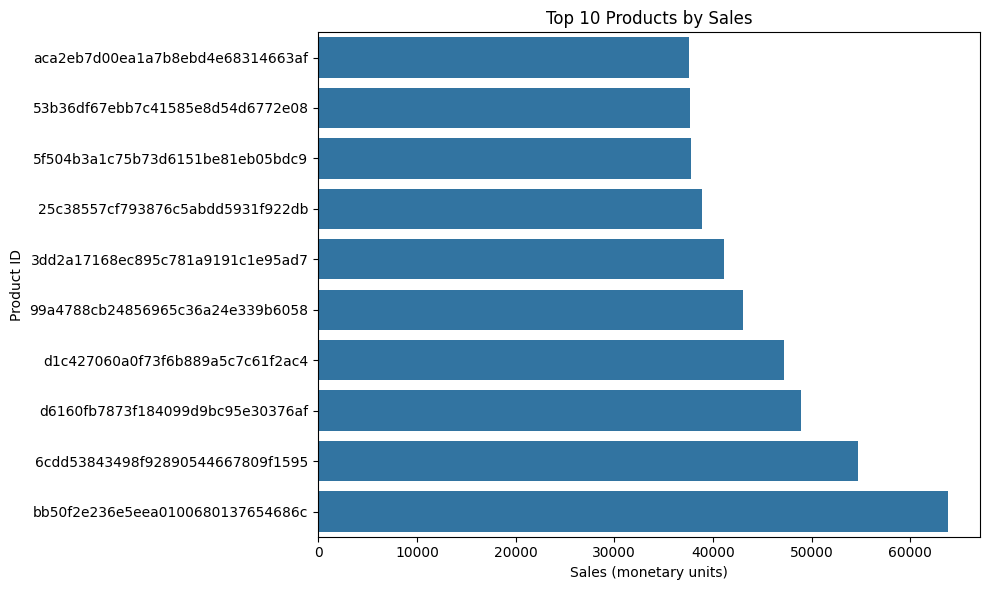

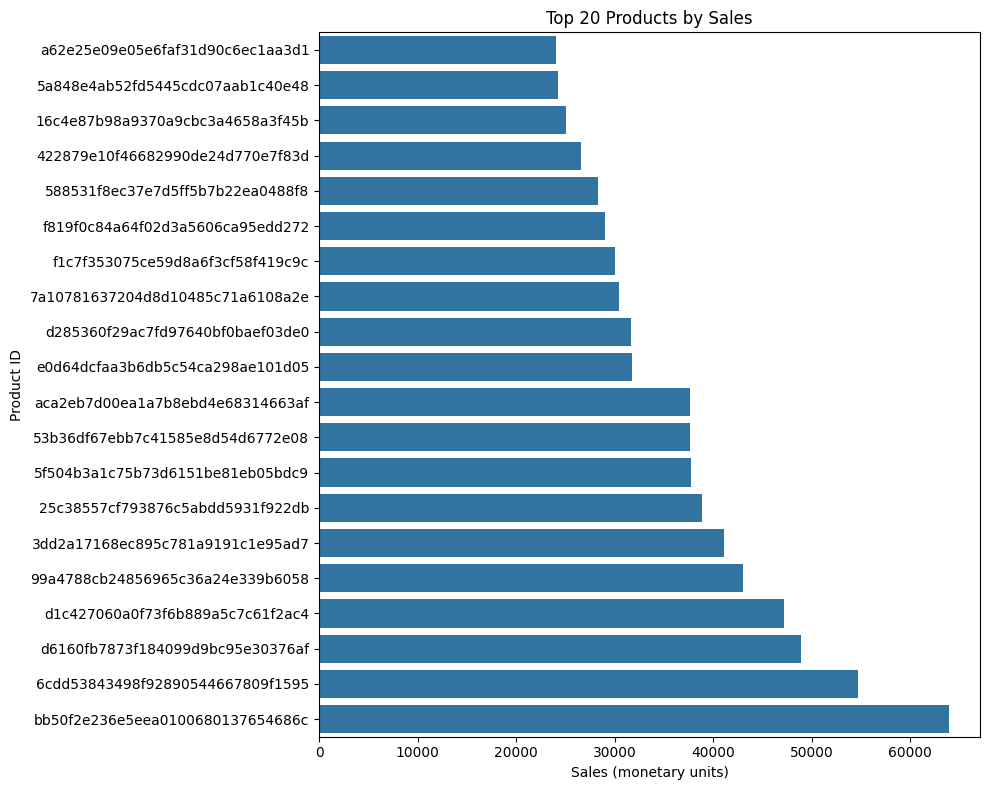

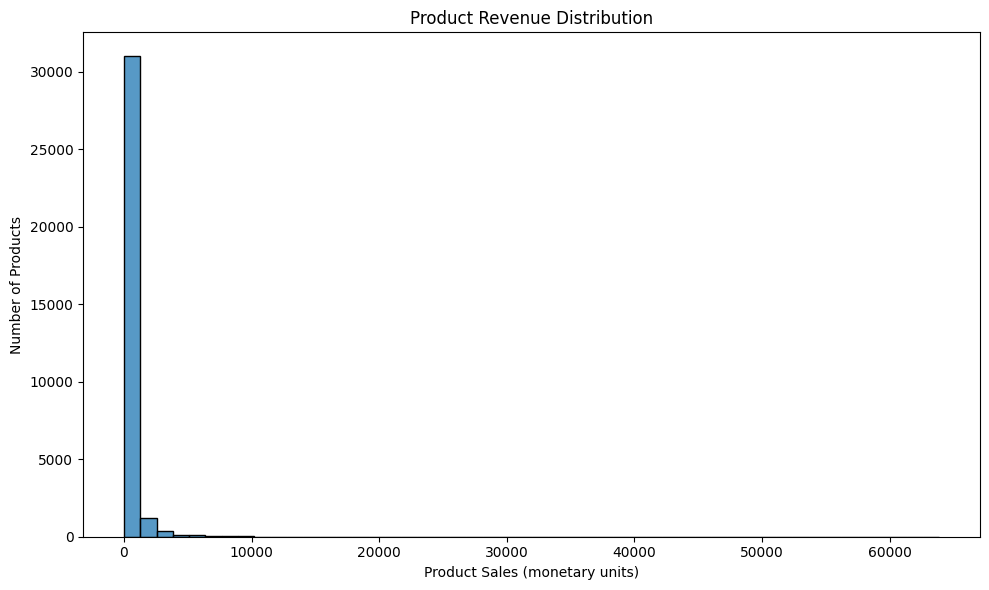

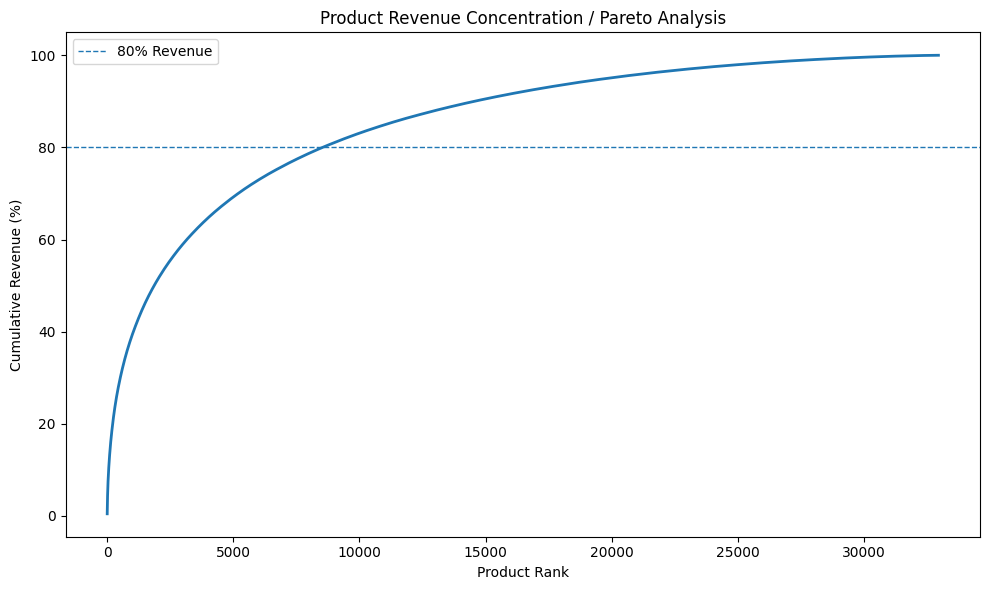

In [38]:
# =============================================================================
# 8.3–8.6 REQUIRED PRODUCT CHARTS
# =============================================================================

# -----------------------------------------------------------------------------
# CHART 1 — TOP 10 PRODUCTS
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=product_top10.sort_values("sales"),
    x="sales",
    y="product_id",
    ax=ax
)

ax.set_title("Top 10 Products by Sales")
ax.set_xlabel("Sales (monetary units)")
ax.set_ylabel("Product ID")

fig.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# CHART 2 — TOP 20 PRODUCTS
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 8))

sns.barplot(
    data=product_top20.sort_values("sales"),
    x="sales",
    y="product_id",
    ax=ax
)

ax.set_title("Top 20 Products by Sales")
ax.set_xlabel("Sales (monetary units)")
ax.set_ylabel("Product ID")

fig.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# CHART 3 — PRODUCT REVENUE DISTRIBUTION
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=product_summary,
    x="sales",
    bins=50,
    ax=ax
)

ax.set_title("Product Revenue Distribution")
ax.set_xlabel("Product Sales (monetary units)")
ax.set_ylabel("Number of Products")

fig.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# CHART 4 — PRODUCT CONCENTRATION / PARETO
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    product_summary["sales_rank"],
    product_summary["cumulative_revenue_pct"],
    linewidth=2
)

ax.axhline(
    80,
    linestyle="--",
    linewidth=1,
    label="80% Revenue"
)

ax.set_title("Product Revenue Concentration / Pareto Analysis")
ax.set_xlabel("Product Rank")
ax.set_ylabel("Cumulative Revenue (%)")

ax.legend()

fig.tight_layout()
plt.show()

## 9. Customer Analysis

Analyze customer behavior using `customer_unique_id`.

- Unique customers
- Orders per customer
- Repeat customers
- One-time customers
- Customer revenue
- AOV by customer segment
- Customer concentration

### Required charts

1. Orders-per-customer distribution
2. New vs repeat customer comparison
3. Top customers by revenue
4. Customer revenue concentration

**Critical rule:** Do not use `customer_id` to define repeat customers. Use `customer_unique_id`.

In [39]:
# =============================================================================
# 9.1 CUSTOMER METRICS
# =============================================================================

customer_order_sales = (
    order_sales[["order_id", "order_sales"]]
    .merge(
        orders_eda[["order_id", "customer_id"]],
        on="order_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        customers[["customer_id", "customer_unique_id"]].drop_duplicates(),
        on="customer_id",
        how="left",
        validate="many_to_one",
    )
    .drop(columns="customer_id")
)

assert customer_order_sales["order_id"].is_unique
assert customer_order_sales["customer_unique_id"].notna().all()
assert len(customer_order_sales) == len(order_sales)
assert np.isclose(
    customer_order_sales["order_sales"].sum(), order_sales["order_sales"].sum()
)

customer_summary = (
    customer_order_sales
    .groupby("customer_unique_id", as_index=False)
    .agg(
        order_count=("order_id", "nunique"),
        customer_revenue=("order_sales", "sum"),
    )
)
customer_summary["customer_segment"] = np.where(
    customer_summary["order_count"].gt(1), "Repeat", "One-time"
)
customer_summary["customer_aov"] = (
    customer_summary["customer_revenue"] / customer_summary["order_count"]
)

unique_customer_count = customer_summary["customer_unique_id"].nunique()
repeat_customer_count = int(customer_summary["customer_segment"].eq("Repeat").sum())
one_time_customer_count = int(customer_summary["customer_segment"].eq("One-time").sum())
assert unique_customer_count == repeat_customer_count + one_time_customer_count
assert customer_summary["order_count"].sum() == len(customer_order_sales)
assert np.isclose(
    customer_summary["customer_revenue"].sum(), customer_order_sales["order_sales"].sum()
)

customer_segment_summary = (
    customer_summary
    .groupby("customer_segment", as_index=False)
    .agg(
        customers=("customer_unique_id", "nunique"),
        orders=("order_count", "sum"),
        revenue=("customer_revenue", "sum"),
    )
)
customer_segment_summary["aov"] = (
    customer_segment_summary["revenue"] / customer_segment_summary["orders"]
)
customer_segment_summary["customer_share_pct"] = (
    customer_segment_summary["customers"] / unique_customer_count * 100
)

customer_revenue_concentration = (
    customer_summary
    .sort_values("customer_revenue", ascending=False)
    .reset_index(drop=True)
)
customer_revenue_concentration["customer_rank"] = (
    customer_revenue_concentration.index + 1
)
customer_revenue_concentration["revenue_share_pct"] = (
    customer_revenue_concentration["customer_revenue"]
    / customer_revenue_concentration["customer_revenue"].sum()
    * 100
)
customer_revenue_concentration["cumulative_revenue_pct"] = (
    customer_revenue_concentration["revenue_share_pct"].cumsum()
)

customer_summary_table = pd.DataFrame(
    {
        "metric": [
            "Unique customers",
            "Orders",
            "Repeat customers",
            "One-time customers",
            "Customer revenue",
        ],
        "value": [
            unique_customer_count,
            len(customer_order_sales),
            repeat_customer_count,
            one_time_customer_count,
            customer_summary["customer_revenue"].sum(),
        ],
    }
)

display(customer_summary_table)
display(customer_segment_summary)
display(customer_summary.sort_values("customer_revenue", ascending=False).head(10))

,metric,value
0,Unique customers,95420.0
1,Orders,98666.0
2,Repeat customers,2913.0
3,One-time customers,92507.0
4,Customer revenue,13591643.7


,customer_segment,customers,orders,revenue,aov,customer_share_pct
0,One-time,92507,92507,12828351.84,138.674390,96.947181
1,Repeat,2913,6159,763291.86,123.931135,3.052819


,customer_unique_id,order_count,customer_revenue,customer_segment,customer_aov
3799,0a0a92112bd4c708ca5fde585afaa872,1,13440.0,One-time,13440.0
81388,da122df9eeddfedc1dc1f5349a1a690c,2,7388.0,Repeat,3694.0
44139,763c8b1c9c68a0229c42c9fc6f662b93,1,7160.0,One-time,7160.0
82230,dc4802a71eae9be1dd28f5d788ceb526,1,6735.0,One-time,6735.0
26015,459bef486812aa25204be022145caa62,1,6729.0,One-time,6729.0
95131,ff4159b92c40ebe40454e3e6a7c35ed6,1,6499.0,One-time,6499.0
23947,4007669dec559734d6f53e029e360987,1,5934.6,One-time,5934.6
89056,eebb5dda148d3893cdaf5b5ca3040ccb,1,4690.0,One-time,4690.0
34820,5d0a2980b292d049061542014e8960bf,1,4599.9,One-time,4599.9
27242,48e1ac109decbb87765a3eade6854098,1,4590.0,One-time,4590.0


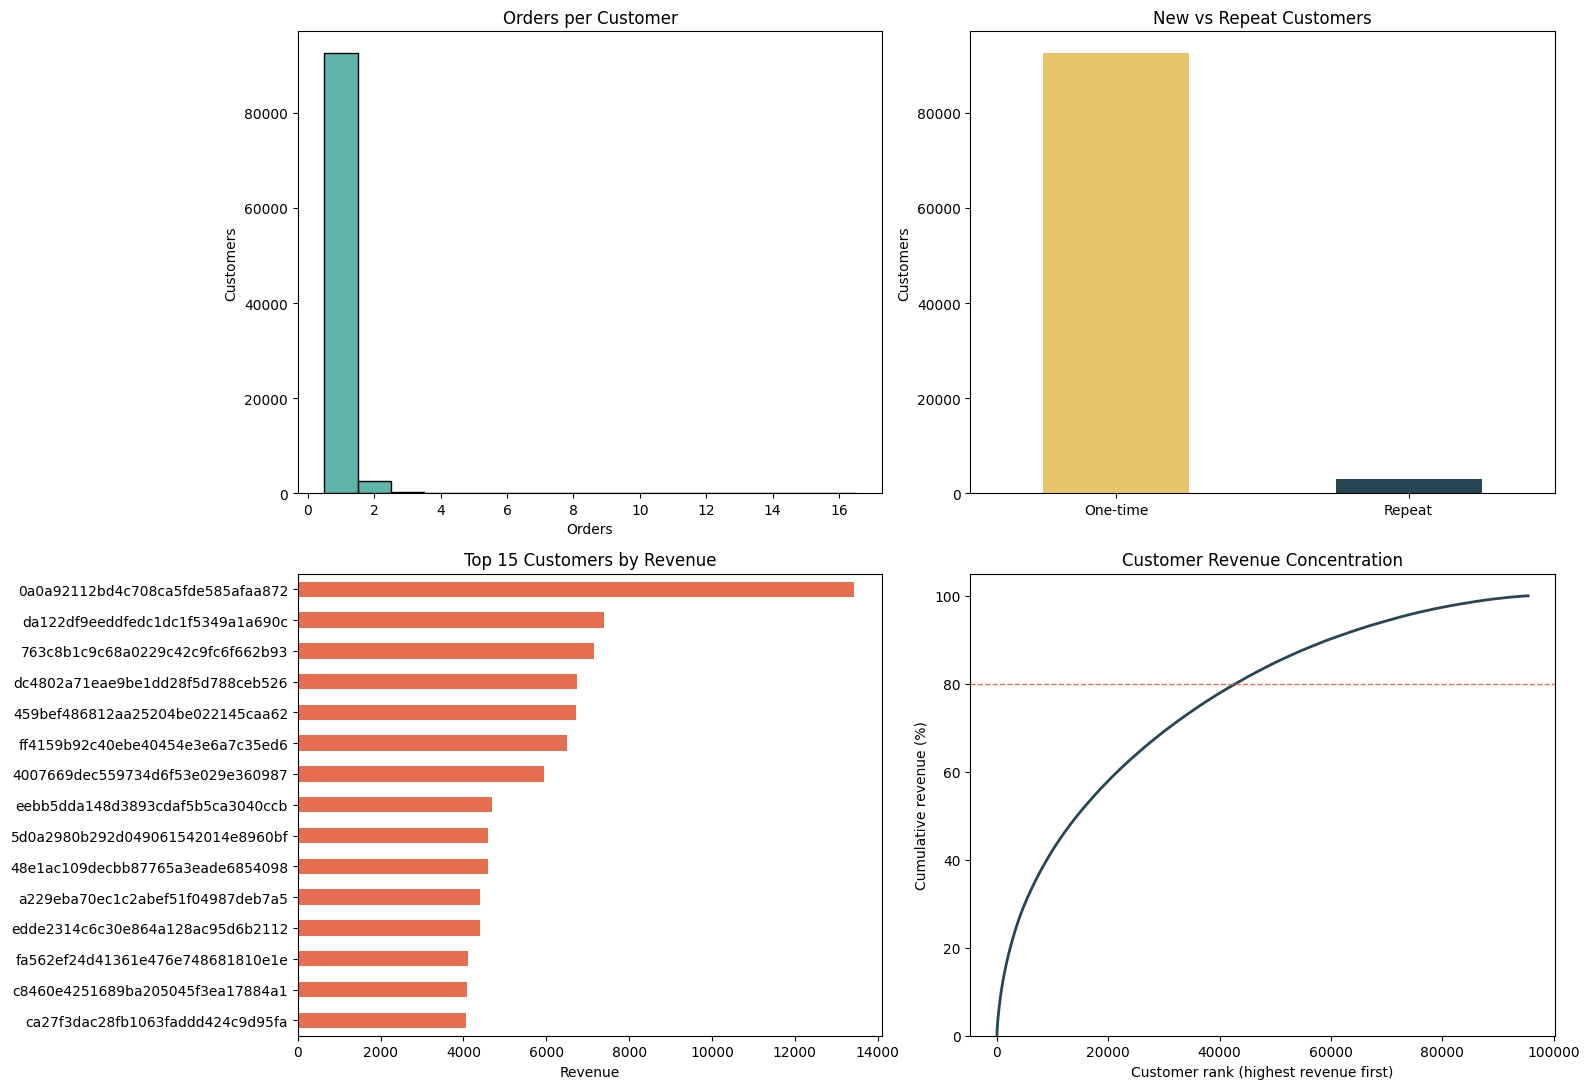

In [40]:
# =============================================================================
# 9.2 CUSTOMER CHARTS
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.histplot(
    customer_summary["order_count"],
    discrete=True,
    ax=axes[0, 0],
    color="#2a9d8f",
)
axes[0, 0].set_title("Orders per Customer")
axes[0, 0].set_xlabel("Orders")
axes[0, 0].set_ylabel("Customers")

segment_order_counts = customer_segment_summary.set_index("customer_segment")["customers"].reindex(
    ["One-time", "Repeat"]
)
segment_order_counts.plot(kind="bar", ax=axes[0, 1], color=["#e9c46a", "#264653"])
axes[0, 1].set_title("New vs Repeat Customers")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Customers")
axes[0, 1].tick_params(axis="x", rotation=0)

customer_revenue_concentration.head(15).sort_values("customer_revenue").plot.barh(
    x="customer_unique_id",
    y="customer_revenue",
    ax=axes[1, 0],
    legend=False,
    color="#e76f51",
)
axes[1, 0].set_title("Top 15 Customers by Revenue")
axes[1, 0].set_xlabel("Revenue")
axes[1, 0].set_ylabel("")

axes[1, 1].plot(
    customer_revenue_concentration["customer_rank"],
    customer_revenue_concentration["cumulative_revenue_pct"],
    color="#264653",
    linewidth=2,
)
axes[1, 1].axhline(80, color="#e76f51", linestyle="--", linewidth=1)
axes[1, 1].set_title("Customer Revenue Concentration")
axes[1, 1].set_xlabel("Customer rank (highest revenue first)")
axes[1, 1].set_ylabel("Cumulative revenue (%)")
axes[1, 1].set_ylim(0, 105)

fig.tight_layout()
plt.show()

## 10. Geographic Analysis

Analyze customer geography using state-level sales, orders, customer distribution, seller distribution, and customer-versus-seller geography.

### Required charts
1. Sales by state
2. Orders by state
3. Customers by state
4. Sellers by state

Treat geolocation as reference/enrichment data consistent with the existing data model.

In [42]:
# =============================================================================
# 10.1 GEOGRAPHIC PREPARATION AND AGGREGATION
# =============================================================================

print("=" * 80)
print("PHASE 10 — GEOGRAPHIC ANALYSIS")
print("=" * 80)

# =============================================================================
# 1. VALIDATE REQUIRED SOURCE COLUMNS
# =============================================================================

required_customer = [
    "customer_id",
    "customer_unique_id",
    "customer_state",
]

required_seller = [
    "seller_id",
    "seller_state",
]

required_orders = [
    "order_id",
    "customer_id",
]

required_items = [
    "order_id",
    "sales_amount",
]

for field in required_customer:
    assert field in customers.columns, (
        f"Missing customer field: {field}"
    )

for field in required_seller:
    assert field in sellers.columns, (
        f"Missing seller field: {field}"
    )

for field in required_orders:
    assert field in orders.columns, (
        f"Missing order field: {field}"
    )

for field in required_items:
    assert field in order_items.columns, (
        f"Missing order-item field: {field}"
    )


# =============================================================================
# 2. CUSTOMER GEOGRAPHY
# =============================================================================

customer_geo = customers[
    ["customer_id", "customer_unique_id", "customer_state"]
].copy()

customer_geo["customer_state"] = (
    customer_geo["customer_state"]
    .astype("string")
    .str.strip()
    .fillna("Unknown / Missing")
    .replace("", "Unknown / Missing")
)

# One customer_id must map to one customer record.
assert customer_geo["customer_id"].is_unique


# -----------------------------------------------------------------------------
# Assign exactly one analytical state to each customer_unique_id
#
# customer_unique_id is the required customer-level grain.
# If the same unique customer appears in multiple customer records/states,
# use the most frequently observed state as the analytical assignment.
# -----------------------------------------------------------------------------

customer_state_assignment = (
    customer_geo
    .groupby(
        ["customer_unique_id", "customer_state"],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "record_count"})
    .sort_values(
        [
            "customer_unique_id",
            "record_count",
            "customer_state",
        ],
        ascending=[True, False, True],
    )
    .drop_duplicates(
        subset=["customer_unique_id"],
        keep="first",
    )
    .reset_index(drop=True)
)

assert customer_state_assignment["customer_unique_id"].is_unique


# -----------------------------------------------------------------------------
# Customer distribution by state
# -----------------------------------------------------------------------------

customer_state_distribution = (
    customer_state_assignment
    .groupby("customer_state", as_index=False)
    .agg(
        customers=("customer_unique_id", "nunique"),
    )
    .sort_values(
        "customers",
        ascending=False,
    )
    .reset_index(drop=True)
)


# =============================================================================
# 3. SELLER GEOGRAPHY
# =============================================================================

seller_geo = sellers[
    ["seller_id", "seller_state"]
].copy()

seller_geo["seller_state"] = (
    seller_geo["seller_state"]
    .astype("string")
    .str.strip()
    .fillna("Unknown / Missing")
    .replace("", "Unknown / Missing")
)

assert seller_geo["seller_id"].is_unique


seller_state_distribution = (
    seller_geo
    .groupby("seller_state", as_index=False)
    .agg(
        sellers=("seller_id", "nunique"),
    )
    .sort_values(
        "sellers",
        ascending=False,
    )
    .reset_index(drop=True)
)


# =============================================================================
# 4. ORDER-LEVEL CUSTOMER GEOGRAPHY
# =============================================================================

geo_orders = orders[
    ["order_id", "customer_id"]
].copy()

geo_orders = geo_orders.merge(
    customer_geo[
        [
            "customer_id",
            "customer_unique_id",
            "customer_state",
        ]
    ],
    on="customer_id",
    how="left",
    validate="many_to_one",
)

geo_orders["customer_state"] = (
    geo_orders["customer_state"]
    .astype("string")
    .fillna("Unknown / Missing")
    .replace("", "Unknown / Missing")
)

# One row per order.
assert geo_orders["order_id"].is_unique


# =============================================================================
# 5. ORDERS BY STATE
# =============================================================================

state_orders = (
    geo_orders
    .groupby("customer_state", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
    )
    .sort_values(
        "orders",
        ascending=False,
    )
    .reset_index(drop=True)
)


# =============================================================================
# 6. SALES BY CUSTOMER STATE
# =============================================================================

geo_sales = order_items[
    ["order_id", "sales_amount"]
].copy()

geo_sales["sales_amount"] = pd.to_numeric(
    geo_sales["sales_amount"],
    errors="coerce",
)

geo_sales = geo_sales.dropna(
    subset=["sales_amount"]
).copy()

geo_sales = geo_sales.merge(
    geo_orders[
        [
            "order_id",
            "customer_state",
        ]
    ],
    on="order_id",
    how="left",
    validate="many_to_one",
)

geo_sales["customer_state"] = (
    geo_sales["customer_state"]
    .astype("string")
    .fillna("Unknown / Missing")
    .replace("", "Unknown / Missing")
)


state_sales = (
    geo_sales
    .groupby("customer_state", as_index=False)
    .agg(
        sales=("sales_amount", "sum"),
    )
    .sort_values(
        "sales",
        ascending=False,
    )
    .reset_index(drop=True)
)


# =============================================================================
# 7. CUSTOMER VS SELLER GEOGRAPHY
# =============================================================================

customer_seller_geography = (
    customer_state_distribution
    .rename(
        columns={
            "customer_state": "state",
        }
    )
    .merge(
        seller_state_distribution.rename(
            columns={
                "seller_state": "state",
            }
        ),
        on="state",
        how="outer",
    )
    .merge(
        state_orders.rename(
            columns={
                "customer_state": "state",
            }
        ),
        on="state",
        how="outer",
    )
    .merge(
        state_sales.rename(
            columns={
                "customer_state": "state",
            }
        ),
        on="state",
        how="outer",
    )
)

numeric_columns = [
    "customers",
    "sellers",
    "orders",
    "sales",
]

for column in numeric_columns:
    customer_seller_geography[column] = (
        pd.to_numeric(
            customer_seller_geography[column],
            errors="coerce",
        )
        .fillna(0)
    )

customer_seller_geography = (
    customer_seller_geography
    .sort_values(
        [
            "sales",
            "orders",
            "customers",
            "sellers",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)


# =============================================================================
# 8. VALIDATION
# =============================================================================

# Sales reconciliation
assert np.isclose(
    state_sales["sales"].sum(),
    geo_sales["sales_amount"].sum(),
)


# Order reconciliation
assert (
    state_orders["orders"].sum()
    == geo_orders["order_id"].nunique()
)


# Customer-level reconciliation
assert (
    customer_state_distribution["customers"].sum()
    == customer_state_assignment["customer_unique_id"].nunique()
)

assert (
    customer_state_assignment["customer_unique_id"].is_unique
)


# Seller reconciliation
assert (
    seller_state_distribution["sellers"].sum()
    == seller_geo["seller_id"].nunique()
)


# Sales must not be negative
assert (
    state_sales["sales"] >= 0
).all()


# Analytical outputs must not be empty
assert not state_sales.empty
assert not state_orders.empty
assert not customer_state_distribution.empty
assert not seller_state_distribution.empty
assert not customer_seller_geography.empty


# =============================================================================
# 9. VALIDATION SUMMARY
# =============================================================================

unique_customers = (
    customer_state_assignment["customer_unique_id"].nunique()
)

total_sellers = (
    seller_geo["seller_id"].nunique()
)

total_orders = (
    geo_orders["order_id"].nunique()
)

total_sales = (
    geo_sales["sales_amount"].sum()
)

print(
    f"States represented        : "
    f"{len(customer_seller_geography):,}"
)

print(
    f"Unique customers analyzed : "
    f"{unique_customers:,}"
)

print(
    f"Sellers analyzed          : "
    f"{total_sellers:,}"
)

print(
    f"Orders analyzed           : "
    f"{total_orders:,}"
)

print(
    f"Sales analyzed            : "
    f"{total_sales:,.2f}"
)

print("-" * 80)

print(
    "Geolocation role          : "
    "Reference / enrichment only"
)

print("State sales validation     : PASS")
print("State orders validation    : PASS")
print("Customer validation        : PASS")
print("Seller validation          : PASS")
print("Sales non-negative check   : PASS")
print("GEOGRAPHIC ANALYSIS PREP   : PASS")

print("=" * 80)

PHASE 10 — GEOGRAPHIC ANALYSIS
States represented        : 27
Unique customers analyzed : 96,096
Sellers analyzed          : 3,095
Orders analyzed           : 99,441
Sales analyzed            : 13,591,643.70
--------------------------------------------------------------------------------
Geolocation role          : Reference / enrichment only
State sales validation     : PASS
State orders validation    : PASS
Customer validation        : PASS
Seller validation          : PASS
Sales non-negative check   : PASS
GEOGRAPHIC ANALYSIS PREP   : PASS


In [43]:
# =============================================================================
# 10.2 GEOGRAPHIC OUTPUT TABLES
# =============================================================================

print("=" * 80)
print("GEOGRAPHIC ANALYSIS — OUTPUT TABLES")
print("=" * 80)

display(state_sales)
display(state_orders)
display(customer_state_distribution)
display(seller_state_distribution)
display(customer_seller_geography)

print("All geographic analytical tables generated successfully.")

GEOGRAPHIC ANALYSIS — OUTPUT TABLES


,customer_state,sales
0,sp,5202955.05
1,rj,1824092.67
2,mg,1585308.03
3,rs,750304.02
4,pr,683083.76
5,sc,520553.34
6,ba,511349.99
7,df,302603.94
8,go,294591.95
9,es,275037.31


,customer_state,orders
0,sp,41746
1,rj,12852
2,mg,11635
3,rs,5466
4,pr,5045
5,sc,3637
6,ba,3380
7,df,2140
8,es,2033
9,go,2020


,customer_state,customers
0,sp,40285
1,rj,12380
2,mg,11257
3,rs,5276
4,pr,4882
5,sc,3530
6,ba,3277
7,df,2075
8,es,1964
9,go,1951


,seller_state,sellers
0,sp,1849
1,pr,349
2,mg,244
3,sc,190
4,rj,171
5,rs,129
6,go,40
7,df,30
8,es,23
9,ba,19


,state,customers,sellers,orders,sales
0,sp,40285,1849.0,41746,5202955.05
1,rj,12380,171.0,12852,1824092.67
2,mg,11257,244.0,11635,1585308.03
3,rs,5276,129.0,5466,750304.02
4,pr,4882,349.0,5045,683083.76
5,sc,3530,190.0,3637,520553.34
6,ba,3277,19.0,3380,511349.99
7,df,2075,30.0,2140,302603.94
8,go,1951,40.0,2020,294591.95
9,es,1964,23.0,2033,275037.31


All geographic analytical tables generated successfully.


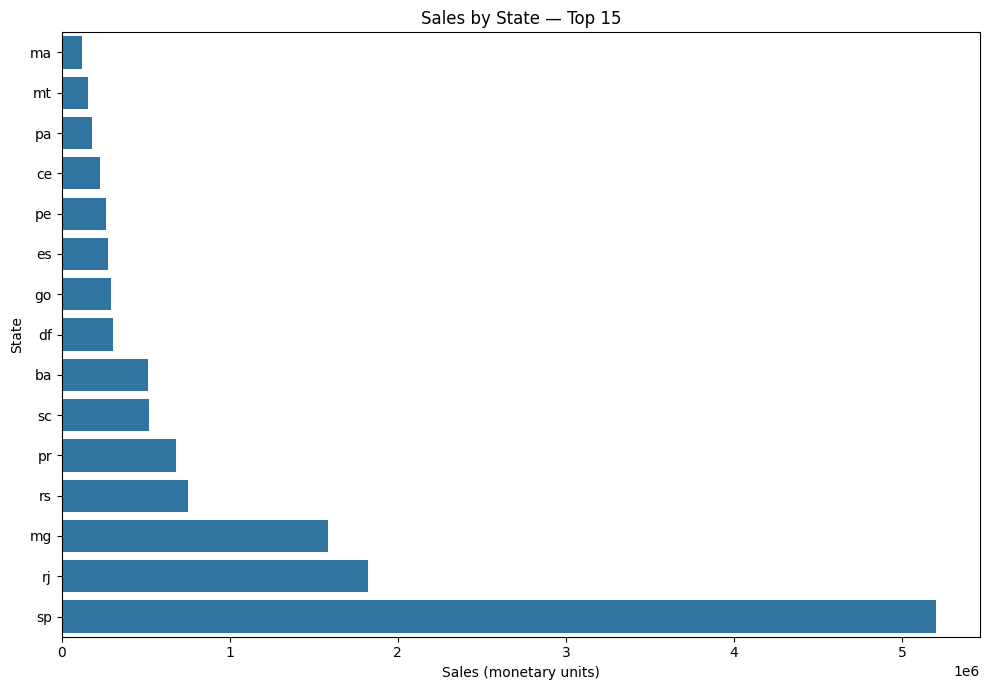

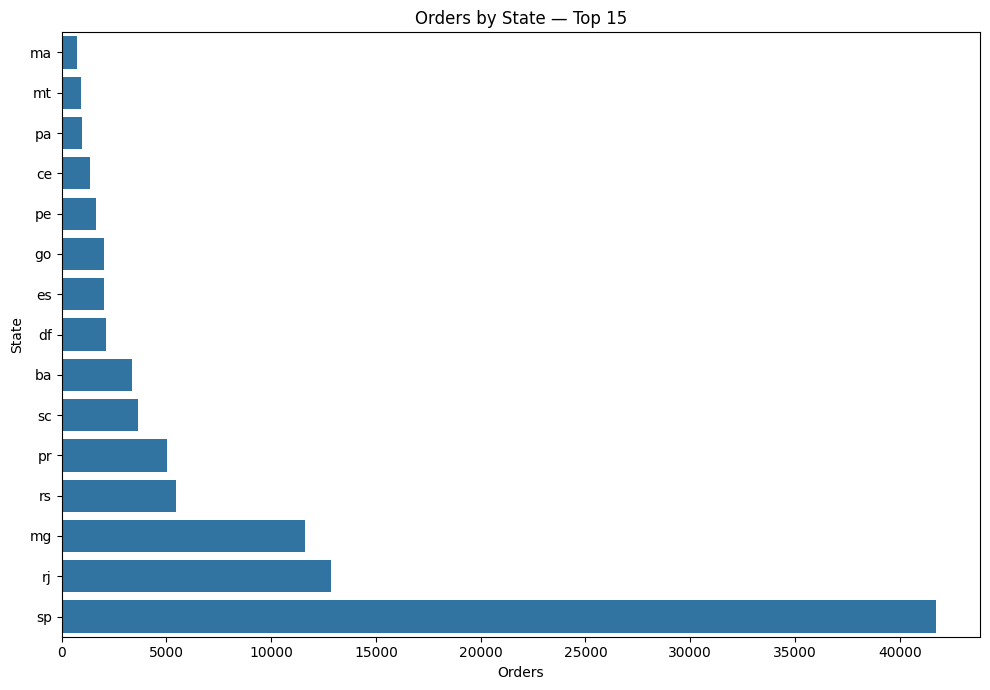

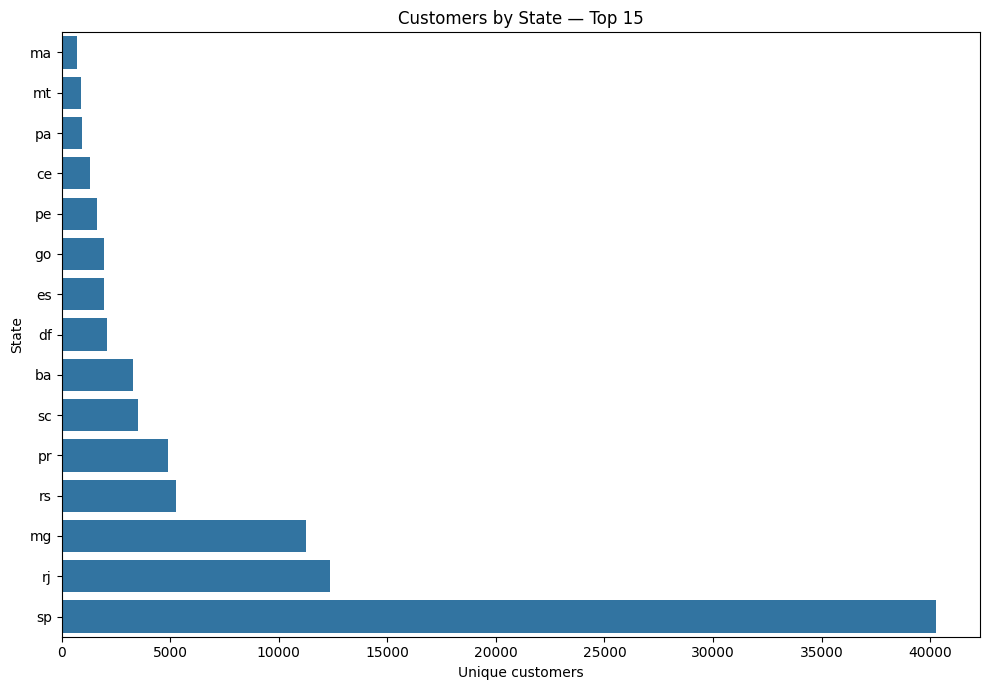

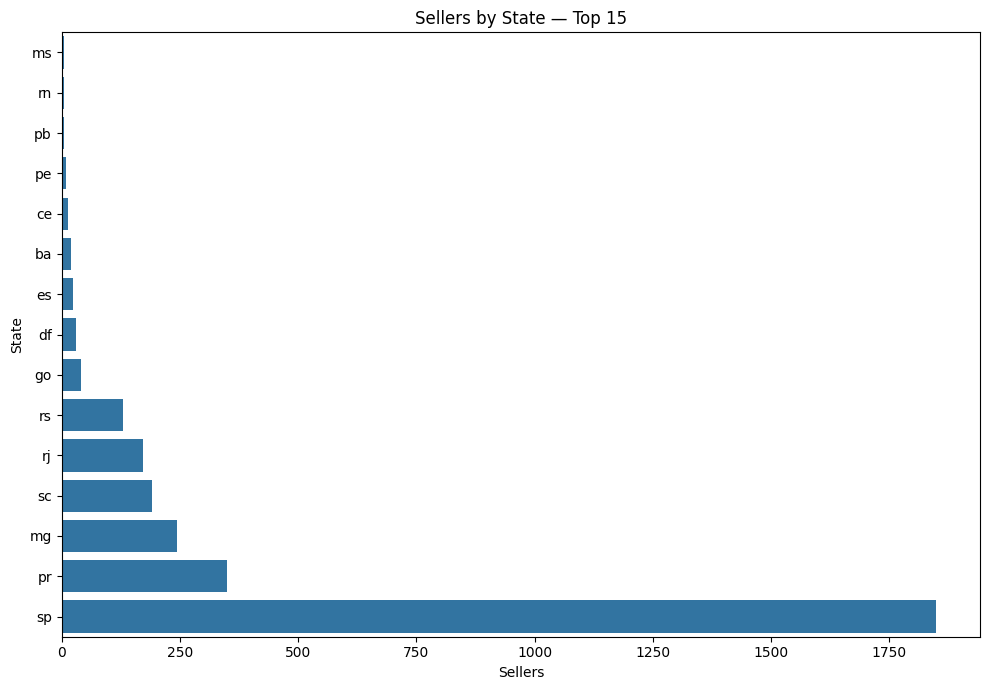

ALL 4 REQUIRED GEOGRAPHIC CHARTS EXECUTED SUCCESSFULLY


In [44]:
# =============================================================================
# 10.3 REQUIRED GEOGRAPHIC CHARTS
# =============================================================================

# -------------------------------------------------------------------------
# Chart 1 — Sales by State
# -------------------------------------------------------------------------

plot_sales = state_sales.head(15).sort_values("sales")

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(
    data=plot_sales,
    x="sales",
    y="customer_state",
    ax=ax,
)
ax.set_title("Sales by State — Top 15")
ax.set_xlabel("Sales (monetary units)")
ax.set_ylabel("State")
fig.tight_layout()
plt.show()


# -------------------------------------------------------------------------
# Chart 2 — Orders by State
# -------------------------------------------------------------------------

plot_orders = state_orders.head(15).sort_values("orders")

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(
    data=plot_orders,
    x="orders",
    y="customer_state",
    ax=ax,
)
ax.set_title("Orders by State — Top 15")
ax.set_xlabel("Orders")
ax.set_ylabel("State")
fig.tight_layout()
plt.show()


# -------------------------------------------------------------------------
# Chart 3 — Customers by State
# -------------------------------------------------------------------------

plot_customers = customer_state_distribution.head(15).sort_values(
    "customers"
)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(
    data=plot_customers,
    x="customers",
    y="customer_state",
    ax=ax,
)
ax.set_title("Customers by State — Top 15")
ax.set_xlabel("Unique customers")
ax.set_ylabel("State")
fig.tight_layout()
plt.show()


# -------------------------------------------------------------------------
# Chart 4 — Sellers by State
# -------------------------------------------------------------------------

plot_sellers = seller_state_distribution.head(15).sort_values(
    "sellers"
)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(
    data=plot_sellers,
    x="sellers",
    y="seller_state",
    ax=ax,
)
ax.set_title("Sellers by State — Top 15")
ax.set_xlabel("Sellers")
ax.set_ylabel("State")
fig.tight_layout()
plt.show()

print("=" * 80)
print("ALL 4 REQUIRED GEOGRAPHIC CHARTS EXECUTED SUCCESSFULLY")
print("=" * 80)

## 11. Payment Analysis

Analyze payment type, payment value, installments, orders by payment method, and revenue by payment method.
    
### Required charts
1. Payment-method distribution
2. Payment-method revenue
3. Installment distribution
4. Payment value distribution

Cross-check major metrics with `payment_analysis.csv`.

In [52]:
# =============================================================================
# 11.1 PAYMENT ANALYSIS — PREPARATION AND AGGREGATION
# =============================================================================

print("=" * 80)
print("PHASE 10 — PAYMENT ANALYSIS")
print("=" * 80)

# -------------------------------------------------------------------------
# Validate source columns
# -------------------------------------------------------------------------

required_payment_fields = [
    "order_id",
    "payment_type",
    "payment_value",
    "payment_installments",
]

missing_fields = [
    field
    for field in required_payment_fields
    if field not in payments.columns
]

if missing_fields:
    raise KeyError(
        "Missing required payment fields: "
        + ", ".join(missing_fields)
    )


# -------------------------------------------------------------------------
# Prepare payment data
# -------------------------------------------------------------------------

payment_eda = payments[
    required_payment_fields
].copy()

payment_eda["payment_value"] = pd.to_numeric(
    payment_eda["payment_value"],
    errors="coerce",
)

payment_eda["payment_installments"] = pd.to_numeric(
    payment_eda["payment_installments"],
    errors="coerce",
)

payment_eda["payment_type"] = (
    payment_eda["payment_type"]
    .astype("string")
    .str.strip()
    .fillna("Unknown / Missing")
    .replace("", "Unknown / Missing")
)

payment_eda = payment_eda.dropna(
    subset=["payment_value"]
).copy()


# -------------------------------------------------------------------------
# Payment-method summary
# -------------------------------------------------------------------------

payment_method_summary = (
    payment_eda
    .groupby("payment_type", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        payment_value=("payment_value", "sum"),
        transaction_count=("order_id", "size"),
    )
    .sort_values(
        "payment_value",
        ascending=False,
    )
    .reset_index(drop=True)
)

total_payment_value = payment_method_summary["payment_value"].sum()

payment_method_summary["revenue_share_pct"] = (
    payment_method_summary["payment_value"]
    / total_payment_value
    * 100
)


# -------------------------------------------------------------------------
# Installment summary
# -------------------------------------------------------------------------

installment_summary = (
    payment_eda
    .dropna(subset=["payment_installments"])
    .groupby("payment_installments", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        payment_value=("payment_value", "sum"),
        transaction_count=("order_id", "size"),
    )
    .sort_values("payment_installments")
    .reset_index(drop=True)
)


# -------------------------------------------------------------------------
# Overall payment metrics
# -------------------------------------------------------------------------

payment_value_summary = pd.DataFrame({
    "Metric": [
        "Payment transactions",
        "Unique orders with payments",
        "Payment methods",
        "Total payment value",
        "Average payment value",
        "Median payment value",
        "Minimum payment value",
        "Maximum payment value",
        "Average installments",
        "Median installments",
        "Maximum installments",
    ],
    "Value": [
        len(payment_eda),
        payment_eda["order_id"].nunique(),
        payment_eda["payment_type"].nunique(),
        payment_eda["payment_value"].sum(),
        payment_eda["payment_value"].mean(),
        payment_eda["payment_value"].median(),
        payment_eda["payment_value"].min(),
        payment_eda["payment_value"].max(),
        payment_eda["payment_installments"].mean(),
        payment_eda["payment_installments"].median(),
        payment_eda["payment_installments"].max(),
    ],
})


# -------------------------------------------------------------------------
# Validation
# -------------------------------------------------------------------------

assert not payment_eda.empty
assert not payment_method_summary.empty
assert not installment_summary.empty

assert np.isclose(
    payment_method_summary["payment_value"].sum(),
    payment_eda["payment_value"].sum(),
)

assert np.isclose(
    payment_method_summary["revenue_share_pct"].sum(),
    100,
)

assert (
    payment_eda["payment_value"] >= 0
).all()

assert (
    payment_eda["payment_installments"].dropna() >= 0
).all()

print(
    f"Payment transactions      : {len(payment_eda):,}"
)
print(
    f"Orders with payments      : "
    f"{payment_eda['order_id'].nunique():,}"
)
print(
    f"Payment methods           : "
    f"{payment_eda['payment_type'].nunique():,}"
)
print(
    f"Total payment value       : "
    f"{payment_eda['payment_value'].sum():,.2f}"
)
print(
    f"Average payment value     : "
    f"{payment_eda['payment_value'].mean():,.2f}"
)
print("-" * 80)
print("Payment aggregation       : PASS")
print("Payment-share validation  : PASS")
print("PAYMENT ANALYSIS PREP     : PASS")
print("=" * 80)

PHASE 10 — PAYMENT ANALYSIS
Payment transactions      : 103,886
Orders with payments      : 99,440
Payment methods           : 5
Total payment value       : 16,008,872.12
Average payment value     : 154.10
--------------------------------------------------------------------------------
Payment aggregation       : PASS
Payment-share validation  : PASS
PAYMENT ANALYSIS PREP     : PASS


In [53]:
# =============================================================================
# 11.2 PAYMENT ANALYSIS — SQL CROSS-VALIDATION AND OUTPUTS
# =============================================================================

payment_sql_path = (
    PROJECT_ROOT
    / "reports"
    / "sql"
    / "analytical_outputs"
    / "payment_analysis.csv"
)

if not payment_sql_path.is_file():
    raise FileNotFoundError(
        f"SQL payment-analysis output not found: {payment_sql_path}"
    )

sql_payment = pd.read_csv(payment_sql_path)


# -------------------------------------------------------------------------
# Validate SQL payment-value results
# -------------------------------------------------------------------------

required_sql_fields = [
    "payment_type",
    "payment_value",
]

missing_sql_fields = [
    field
    for field in required_sql_fields
    if field not in sql_payment.columns
]

if missing_sql_fields:
    raise KeyError(
        "SQL payment-analysis output is missing: "
        + ", ".join(missing_sql_fields)
    )

sql_payment["payment_type"] = (
    sql_payment["payment_type"]
    .astype("string")
    .str.strip()
    .fillna("Unknown / Missing")
    .replace("", "Unknown / Missing")
)

sql_payment["payment_value"] = pd.to_numeric(
    sql_payment["payment_value"],
    errors="coerce",
)

sql_payment = sql_payment.dropna(
    subset=["payment_value"]
).copy()


# -------------------------------------------------------------------------
# SQL payment-method aggregation
# -------------------------------------------------------------------------

sql_method_summary = (
    sql_payment
    .groupby("payment_type", as_index=False)
    .agg(
        sql_payment_value=("payment_value", "sum")
    )
)


# -------------------------------------------------------------------------
# Python vs SQL comparison
# -------------------------------------------------------------------------

payment_sql_comparison = (
    payment_method_summary[
        ["payment_type", "payment_value"]
    ]
    .merge(
        sql_method_summary,
        on="payment_type",
        how="outer",
    )
    .fillna(0)
)

payment_sql_comparison["difference"] = (
    payment_sql_comparison["payment_value"]
    - payment_sql_comparison["sql_payment_value"]
)

payment_sql_comparison["value_match"] = np.isclose(
    payment_sql_comparison["payment_value"],
    payment_sql_comparison["sql_payment_value"],
)


# -------------------------------------------------------------------------
# Overall reconciliation
# -------------------------------------------------------------------------

python_total = payment_eda["payment_value"].sum()
sql_total = sql_payment["payment_value"].sum()

total_value_match = np.isclose(
    python_total,
    sql_total,
)


# -------------------------------------------------------------------------
# SQL order-count comparison — diagnostic only
# -------------------------------------------------------------------------

sql_order_check = "Not available"

if {"payment_type", "orders"}.issubset(sql_payment.columns):

    sql_orders = sql_payment[
        ["payment_type", "orders"]
    ].copy()

    sql_orders["orders"] = pd.to_numeric(
        sql_orders["orders"],
        errors="coerce",
    )

    sql_orders = sql_orders.dropna(
        subset=["orders"]
    )

    sql_orders = (
        sql_orders
        .groupby("payment_type", as_index=False)
        .agg(
            sql_orders=("orders", "sum")
        )
    )

    payment_order_comparison = (
        payment_method_summary[
            ["payment_type", "orders"]
        ]
        .merge(
            sql_orders,
            on="payment_type",
            how="outer",
        )
        .fillna(0)
    )

    payment_order_comparison["order_difference"] = (
        payment_order_comparison["orders"]
        - payment_order_comparison["sql_orders"]
    )

    payment_order_comparison["orders_match"] = (
        payment_order_comparison["order_difference"] == 0
    )

    sql_order_check = bool(
        payment_order_comparison["orders_match"].all()
    )


# -------------------------------------------------------------------------
# Cross-validation summary
# -------------------------------------------------------------------------

sql_cross_validation = pd.DataFrame({
    "Check": [
        "Payment methods compared",
        "Total payment value matches SQL",
        "Payment-method revenue matches SQL",
        "SQL order-count diagnostic",
        "Python payment analysis retained as primary result",
    ],
    "Result": [
        len(payment_sql_comparison),
        total_value_match,
        bool(payment_sql_comparison["value_match"].all()),
        sql_order_check,
        True,
    ],
})


# -------------------------------------------------------------------------
# Final SQL validation
# -------------------------------------------------------------------------

assert len(payment_sql_comparison) > 0
assert total_value_match
assert bool(payment_sql_comparison["value_match"].all())


# -------------------------------------------------------------------------
# Display results
# -------------------------------------------------------------------------

display(payment_value_summary)
display(payment_method_summary)
display(installment_summary)
display(payment_sql_comparison)
display(sql_cross_validation)

print("-" * 80)
print("Payment aggregation       : PASS")
print("Payment-share validation  : PASS")
print("SQL revenue validation    : PASS")
print("PAYMENT ANALYSIS COMPLETE : PASS")
print("=" * 80)

,Metric,Value
0,Payment transactions,1.038860e+05
1,Unique orders with payments,9.944000e+04
2,Payment methods,5.000000e+00
3,Total payment value,1.600887e+07
4,Average payment value,1.541004e+02
5,Median payment value,1.000000e+02
6,Minimum payment value,0.000000e+00
7,Maximum payment value,1.366408e+04
8,Average installments,2.853404e+00
9,Median installments,1.000000e+00


,payment_type,orders,payment_value,transaction_count,revenue_share_pct
0,credit_card,76505,12542084.19,76795,78.344584
1,boleto,19784,2869361.27,19784,17.923569
2,voucher,3866,379436.87,5775,2.370166
3,debit_card,1528,217989.79,1529,1.361681
4,not_defined,3,0.00,3,0.000000


,payment_installments,orders,payment_value,transaction_count
0,1.0,49060,5907233.36,52546
1,2.0,12389,1579283.03,12413
2,3.0,10443,1491103.80,10461
3,4.0,7088,1163907.61,7098
4,5.0,5234,961174.30,5239
5,6.0,3916,822611.81,3920
6,7.0,1623,305157.39,1626
7,8.0,4253,1313423.34,4268
8,9.0,644,131015.92,644
9,10.0,5315,2211577.34,5328


,payment_type,payment_value,sql_payment_value,difference,value_match
0,boleto,2869361.27,2869361.27,0.0,True
1,credit_card,12542084.19,12542084.19,0.0,True
2,debit_card,217989.79,217989.79,0.0,True
3,not_defined,0.00,0.00,0.0,True
4,voucher,379436.87,379436.87,0.0,True


,Check,Result
0,Payment methods compared,5
1,Total payment value matches SQL,True
2,Payment-method revenue matches SQL,True
3,SQL order-count diagnostic,False
4,Python payment analysis retained as primary re...,True


--------------------------------------------------------------------------------
Payment aggregation       : PASS
Payment-share validation  : PASS
SQL revenue validation    : PASS
PAYMENT ANALYSIS COMPLETE : PASS


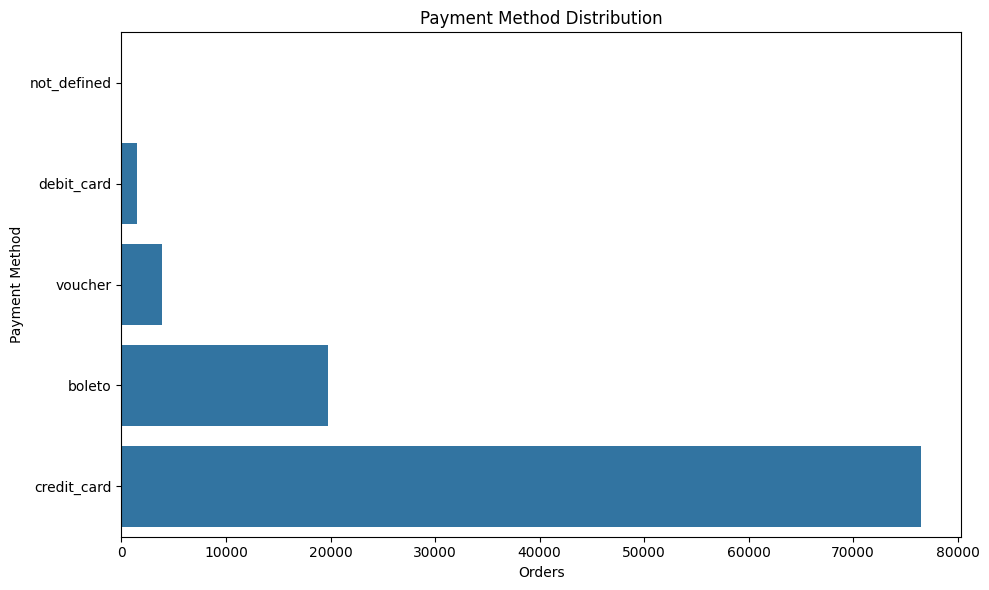

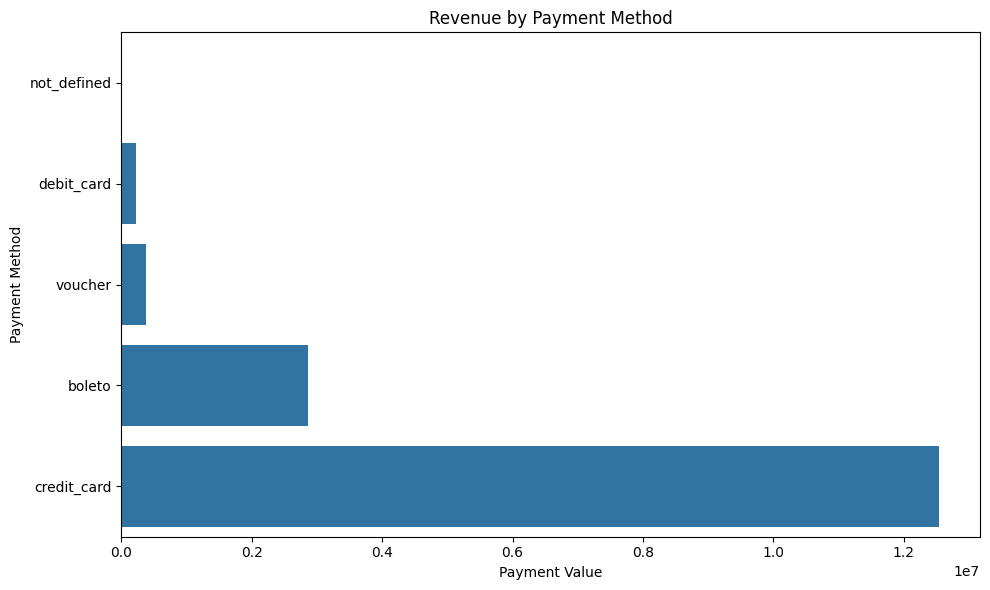

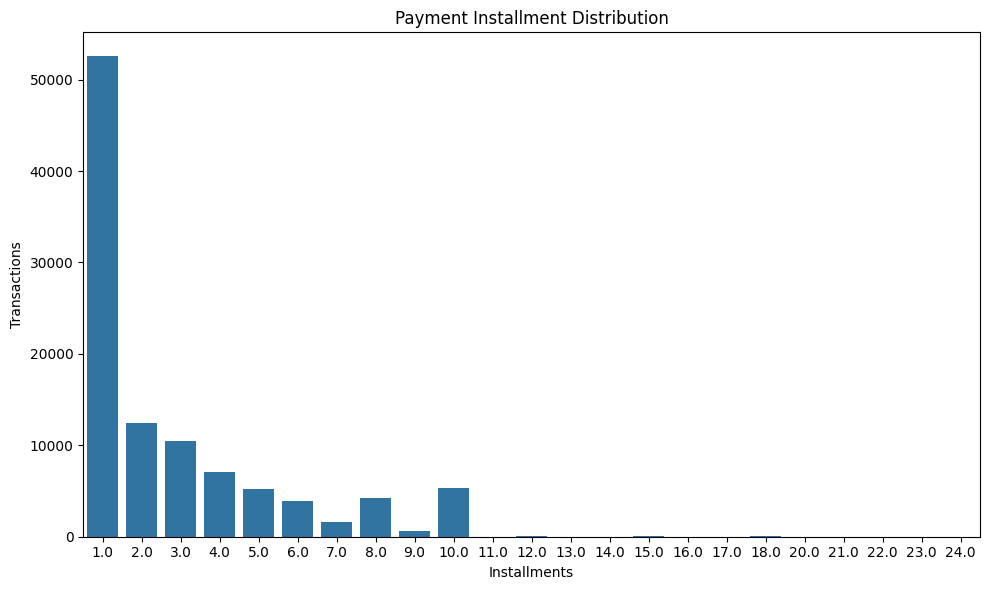

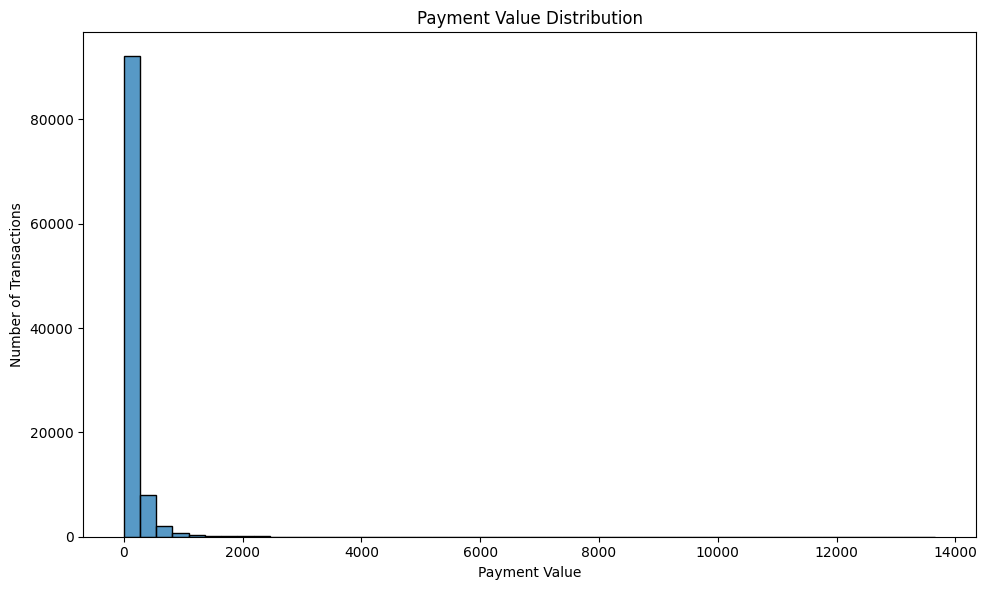

In [54]:
# =============================================================================
# 11.3 REQUIRED PAYMENT ANALYSIS CHARTS
# =============================================================================

# -----------------------------------------------------------------------------
# CHART 1 — PAYMENT-METHOD DISTRIBUTION
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=payment_method_summary.sort_values("orders"),
    x="orders",
    y="payment_type",
    ax=ax,
)

ax.set_title("Payment Method Distribution")
ax.set_xlabel("Orders")
ax.set_ylabel("Payment Method")

fig.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# CHART 2 — PAYMENT-METHOD REVENUE
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=payment_method_summary.sort_values("payment_value"),
    x="payment_value",
    y="payment_type",
    ax=ax,
)

ax.set_title("Revenue by Payment Method")
ax.set_xlabel("Payment Value")
ax.set_ylabel("Payment Method")

fig.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# CHART 3 — INSTALLMENT DISTRIBUTION
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

installment_chart = (
    payment_eda["payment_installments"]
    .value_counts()
    .sort_index()
    .reset_index()
)

installment_chart.columns = [
    "payment_installments",
    "transactions",
]

sns.barplot(
    data=installment_chart,
    x="payment_installments",
    y="transactions",
    ax=ax,
)

ax.set_title("Payment Installment Distribution")
ax.set_xlabel("Installments")
ax.set_ylabel("Transactions")

fig.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# CHART 4 — PAYMENT VALUE DISTRIBUTION
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=payment_eda,
    x="payment_value",
    bins=50,
    kde=False,
    ax=ax,
)

ax.set_title("Payment Value Distribution")
ax.set_xlabel("Payment Value")
ax.set_ylabel("Number of Transactions")

fig.tight_layout()
plt.show()

## 12. Review Analysis

Analyze review-score distribution, average review score, review scores by category and payment method, and review scores versus delivery performance.

### Required charts
1. Review-score distribution
2. Average score by category
3. Review score vs delivery delay

The objective is to investigate relationships between customer satisfaction and operational performance without claiming causality.

In [56]:
# =============================================================================
# 12.1 REVIEW ANALYSIS — PREPARATION AND AGGREGATION
# =============================================================================

print("=" * 80)
print("PHASE 10 — REVIEW ANALYSIS")
print("=" * 80)

# -------------------------------------------------------------------------
# Validate required source columns
# -------------------------------------------------------------------------

required_review_fields = [
    "order_id",
    "review_score",
]

required_order_fields = [
    "order_id",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for field in required_review_fields:
    if field not in reviews.columns:
        raise KeyError(f"Missing review field: {field}")

missing_order_fields = [
    field for field in required_order_fields
    if field not in orders.columns
]

if missing_order_fields:
    raise KeyError(
        "Missing order delivery fields: "
        + ", ".join(missing_order_fields)
    )


# -------------------------------------------------------------------------
# Prepare reviews
# -------------------------------------------------------------------------

review_eda = reviews[
    ["order_id", "review_score"]
].copy()

review_eda["review_score"] = pd.to_numeric(
    review_eda["review_score"],
    errors="coerce",
)

review_eda = review_eda.dropna(
    subset=["review_score"]
).copy()

review_eda["review_score"] = review_eda["review_score"].astype(int)

assert review_eda["review_score"].between(1, 5).all()


# -------------------------------------------------------------------------
# Review-score distribution
# -------------------------------------------------------------------------

review_score_distribution = (
    review_eda
    .groupby("review_score", as_index=False)
    .agg(
        reviews=("order_id", "size"),
        orders=("order_id", "nunique"),
    )
    .sort_values("review_score")
    .reset_index(drop=True)
)

review_score_distribution["percentage"] = (
    review_score_distribution["reviews"]
    / review_score_distribution["reviews"].sum()
    * 100
)


# -------------------------------------------------------------------------
# Review summary
# -------------------------------------------------------------------------

review_summary = pd.DataFrame({
    "Metric": [
        "Review records",
        "Orders with reviews",
        "Average review score",
        "Median review score",
        "Minimum review score",
        "Maximum review score",
        "5-star review share (%)",
        "1-star review share (%)",
    ],
    "Value": [
        len(review_eda),
        review_eda["order_id"].nunique(),
        review_eda["review_score"].mean(),
        review_eda["review_score"].median(),
        review_eda["review_score"].min(),
        review_eda["review_score"].max(),
        (review_eda["review_score"] == 5).mean() * 100,
        (review_eda["review_score"] == 1).mean() * 100,
    ],
})


# -------------------------------------------------------------------------
# Delivery performance
# -------------------------------------------------------------------------

delivery_eda = orders[
    [
        "order_id",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ]
].copy()

delivery_eda["order_delivered_customer_date"] = pd.to_datetime(
    delivery_eda["order_delivered_customer_date"],
    errors="coerce",
)

delivery_eda["order_estimated_delivery_date"] = pd.to_datetime(
    delivery_eda["order_estimated_delivery_date"],
    errors="coerce",
)

delivery_eda["delivery_delay_days"] = (
    delivery_eda["order_delivered_customer_date"]
    - delivery_eda["order_estimated_delivery_date"]
).dt.total_seconds() / (24 * 60 * 60)

delivery_eda = delivery_eda.dropna(
    subset=["delivery_delay_days"]
).copy()


# -------------------------------------------------------------------------
# Review score vs delivery delay
# -------------------------------------------------------------------------

review_delivery = review_eda.merge(
    delivery_eda[
        ["order_id", "delivery_delay_days"]
    ],
    on="order_id",
    how="inner",
    validate="many_to_one",
)

review_delay_summary = (
    review_delivery
    .groupby("review_score", as_index=False)
    .agg(
        reviews=("order_id", "size"),
        average_delay_days=("delivery_delay_days", "mean"),
        median_delay_days=("delivery_delay_days", "median"),
    )
    .sort_values("review_score")
    .reset_index(drop=True)
)


# -------------------------------------------------------------------------
# Review score by category
# -------------------------------------------------------------------------

required_category_field = "product_category_name_english"

if required_category_field not in order_items_eda.columns:
    raise KeyError(
        f"Missing category field: {required_category_field}"
    )

review_category = review_eda.merge(
    order_items_eda[
        [
            "order_id",
            "product_category_name_english",
        ]
    ],
    on="order_id",
    how="left",
)

review_category["product_category_name_english"] = (
    review_category["product_category_name_english"]
    .astype("string")
    .fillna("Unknown / Untranslated")
    .replace("", "Unknown / Untranslated")
)

category_review_summary = (
    review_category
    .groupby(
        "product_category_name_english",
        as_index=False,
    )
    .agg(
        reviews=("review_score", "size"),
        average_review_score=("review_score", "mean"),
    )
    .sort_values(
        ["average_review_score", "reviews"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)


# -------------------------------------------------------------------------
# Review score by payment method
# -------------------------------------------------------------------------

review_payment = review_eda.merge(
    payments[
        [
            "order_id",
            "payment_type",
        ]
    ],
    on="order_id",
    how="left",
)

review_payment["payment_type"] = (
    review_payment["payment_type"]
    .astype("string")
    .fillna("Unknown / Missing")
    .replace("", "Unknown / Missing")
)

payment_review_summary = (
    review_payment
    .groupby("payment_type", as_index=False)
    .agg(
        reviews=("review_score", "size"),
        average_review_score=("review_score", "mean"),
    )
    .sort_values(
        "average_review_score",
        ascending=False,
    )
    .reset_index(drop=True)
)


# -------------------------------------------------------------------------
# Validation
# -------------------------------------------------------------------------

assert not review_eda.empty

assert review_eda["review_score"].between(1, 5).all()

assert np.isclose(
    review_score_distribution["reviews"].sum(),
    len(review_eda),
)

assert not review_delivery.empty
assert not category_review_summary.empty
assert not payment_review_summary.empty

assert np.isfinite(
    review_delay_summary["average_delay_days"]
).all()


# -------------------------------------------------------------------------
# Summary
# -------------------------------------------------------------------------

print(
    f"Review records             : {len(review_eda):,}"
)

print(
    f"Orders with reviews        : "
    f"{review_eda['order_id'].nunique():,}"
)

print(
    f"Average review score       : "
    f"{review_eda['review_score'].mean():.2f}"
)

print(
    f"Delivery observations      : "
    f"{len(review_delivery):,}"
)

print(
    f"Categories analyzed        : "
    f"{len(category_review_summary):,}"
)

print(
    f"Payment methods analyzed   : "
    f"{len(payment_review_summary):,}"
)

print("-" * 80)
print("Review-score validation    : PASS")
print("Delivery-delay validation : PASS")
print("Category review analysis   : PASS")
print("Payment review analysis    : PASS")
print("REVIEW ANALYSIS PREP       : PASS")
print("=" * 80)

PHASE 10 — REVIEW ANALYSIS
Review records             : 99,224
Orders with reviews        : 98,673
Average review score       : 4.09
Delivery observations      : 96,336
Categories analyzed        : 72
Payment methods analyzed   : 6
--------------------------------------------------------------------------------
Review-score validation    : PASS
Delivery-delay validation : PASS
Category review analysis   : PASS
Payment review analysis    : PASS
REVIEW ANALYSIS PREP       : PASS


In [57]:
# =============================================================================
# 12.2 REVIEW ANALYSIS — OUTPUT TABLES
# =============================================================================

display(review_summary)

display(review_score_distribution)

display(
    category_review_summary
)

display(
    payment_review_summary
)

display(
    review_delay_summary
)

print("=" * 80)
print("REVIEW ANALYSIS OUTPUTS GENERATED")
print("=" * 80)

,Metric,Value
0,Review records,99224.000000
1,Orders with reviews,98673.000000
2,Average review score,4.086421
3,Median review score,5.000000
4,Minimum review score,1.000000
5,Maximum review score,5.000000
6,5-star review share (%),57.776344
7,1-star review share (%),11.513344


,review_score,reviews,orders,percentage
0,1,11424,11393,11.513344
1,2,3151,3148,3.175643
2,3,8179,8160,8.242965
3,4,19142,19098,19.291704
4,5,57328,57076,57.776344


,product_category_name_english,reviews,average_review_score
0,cds_dvds_musicals,14,4.642857
1,fashion_childrens_clothes,8,4.500000
2,books_general_interest,549,4.446266
3,costruction_tools_tools,99,4.444444
4,flowers,31,4.419355
...,...,...,...
67,home_comfort_2,27,3.629630
68,office_furniture,1687,3.493183
69,diapers_and_hygiene,39,3.256410
70,Unknown / Untranslated,2381,3.161277


,payment_type,reviews,average_review_score
0,debit_card,1529,4.168084
1,credit_card,76600,4.087637
2,boleto,19762,4.086631
3,voucher,5783,4.003804
4,not_defined,3,1.666667
5,Unknown / Missing,1,1.000000


,review_score,reviews,average_delay_days,median_delay_days
0,1,9401,-3.355117,-6.383484
1,2,2938,-7.929741,-9.290712
2,3,7959,-10.073013,-10.361806
3,4,18983,-11.680245,-11.493762
4,5,57055,-12.687152,-12.318808


REVIEW ANALYSIS OUTPUTS GENERATED


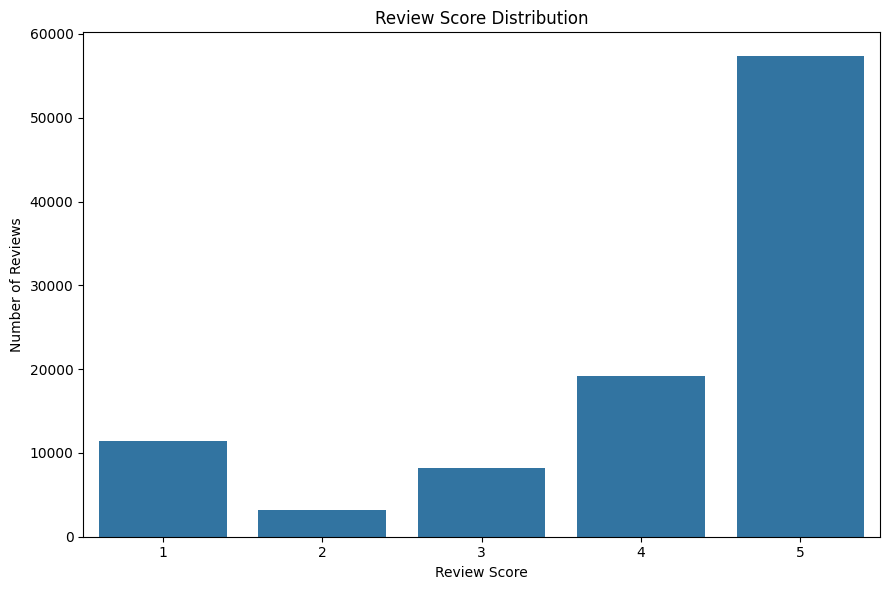

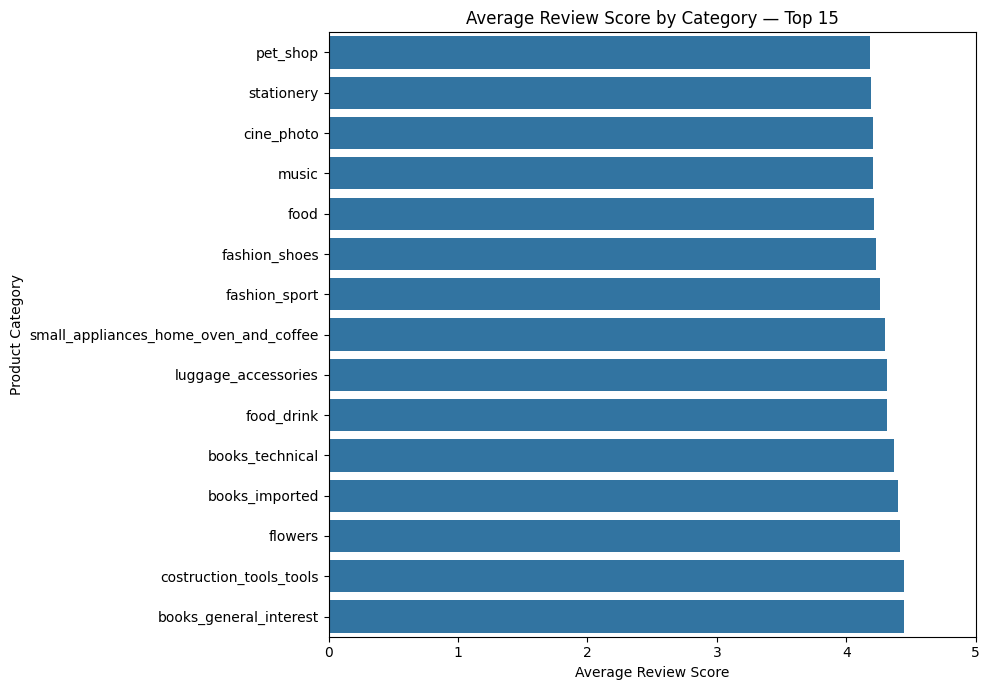

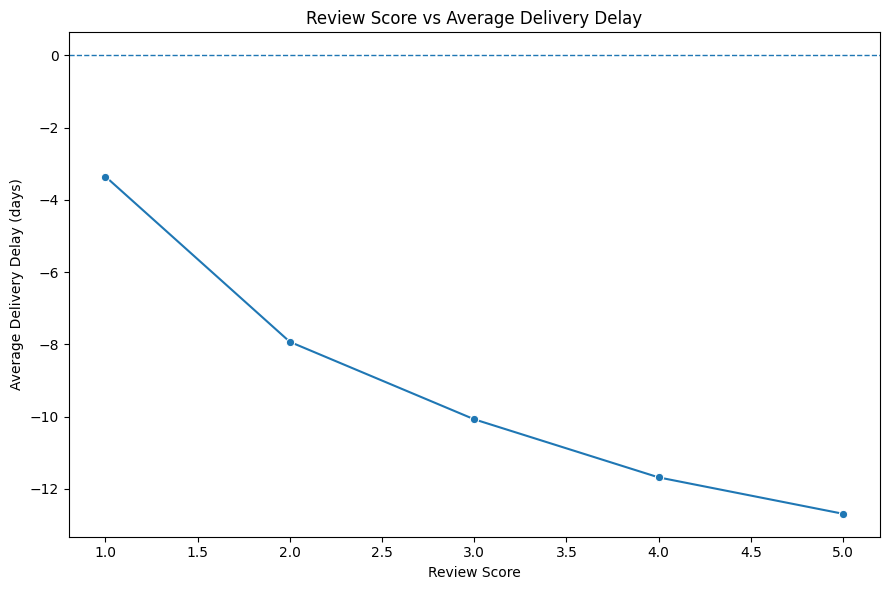

In [58]:
# =============================================================================
# 12.3 REQUIRED REVIEW ANALYSIS CHARTS
# =============================================================================

# -----------------------------------------------------------------------------
# CHART 1 — REVIEW-SCORE DISTRIBUTION
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 6))

sns.barplot(
    data=review_score_distribution,
    x="review_score",
    y="reviews",
    ax=ax,
)

ax.set_title("Review Score Distribution")
ax.set_xlabel("Review Score")
ax.set_ylabel("Number of Reviews")

fig.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# CHART 2 — AVERAGE SCORE BY CATEGORY
# -----------------------------------------------------------------------------

category_chart = (
    category_review_summary
    .query("reviews >= 20")
    .sort_values("average_review_score")
    .tail(15)
)

fig, ax = plt.subplots(figsize=(10, 7))

sns.barplot(
    data=category_chart,
    x="average_review_score",
    y="product_category_name_english",
    ax=ax,
)

ax.set_title("Average Review Score by Category — Top 15")
ax.set_xlabel("Average Review Score")
ax.set_ylabel("Product Category")
ax.set_xlim(0, 5)

fig.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# CHART 3 — REVIEW SCORE VS DELIVERY DELAY
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 6))

sns.lineplot(
    data=review_delay_summary,
    x="review_score",
    y="average_delay_days",
    marker="o",
    ax=ax,
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1,
)

ax.set_title("Review Score vs Average Delivery Delay")
ax.set_xlabel("Review Score")
ax.set_ylabel("Average Delivery Delay (days)")

fig.tight_layout()
plt.show()

## 13. Delivery Analysis

Analyze approval time, carrier handoff duration, delivery duration, estimated versus actual delivery, early/on-time/late delivery, and delivery-duration distribution.

### Required charts
1. Delivery-time distribution
2. Actual vs estimated delivery
3. Delivery performance by state
4. Delivery performance by category

Use `delivery_analysis.csv` for SQL validation.

In [61]:
# =============================================================================
# 13.1 DELIVERY ANALYSIS — PREPARATION, METRICS & SQL VALIDATION
# =============================================================================

print("=" * 80)
print("PHASE 10 — DELIVERY ANALYSIS")
print("=" * 80)

# -----------------------------------------------------------------------------
# 1. Validate source fields
# -----------------------------------------------------------------------------

required_fields = [
    "order_id",
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

missing_fields = [
    field for field in required_fields
    if field not in orders.columns
]

if missing_fields:
    raise KeyError(
        "Missing delivery fields: " + ", ".join(missing_fields)
    )

# -----------------------------------------------------------------------------
# 2. Create delivery analysis dataset
# -----------------------------------------------------------------------------

delivery_eda = orders[required_fields].copy()

timestamp_fields = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for field in timestamp_fields:
    delivery_eda[field] = pd.to_datetime(
        delivery_eda[field],
        errors="coerce",
    )

assert delivery_eda["order_id"].is_unique

# -----------------------------------------------------------------------------
# 3. Calculate delivery metrics
# -----------------------------------------------------------------------------

delivery_eda["approval_time_hours"] = (
    delivery_eda["order_approved_at"]
    - delivery_eda["order_purchase_timestamp"]
).dt.total_seconds() / 3600

delivery_eda["carrier_handoff_hours"] = (
    delivery_eda["order_delivered_carrier_date"]
    - delivery_eda["order_approved_at"]
).dt.total_seconds() / 3600

delivery_eda["delivery_duration_days"] = (
    delivery_eda["order_delivered_customer_date"]
    - delivery_eda["order_delivered_carrier_date"]
).dt.total_seconds() / 86400

delivery_eda["total_delivery_days"] = (
    delivery_eda["order_delivered_customer_date"]
    - delivery_eda["order_purchase_timestamp"]
).dt.total_seconds() / 86400

delivery_eda["delivery_variance_days"] = (
    delivery_eda["order_delivered_customer_date"]
    - delivery_eda["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

# -----------------------------------------------------------------------------
# 4. Delivery status
# -----------------------------------------------------------------------------

delivery_eda["delivery_status"] = np.select(
    [
        delivery_eda["delivery_variance_days"] < 0,
        delivery_eda["delivery_variance_days"] == 0,
        delivery_eda["delivery_variance_days"] > 0,
    ],
    [
        "Early",
        "On Time",
        "Late",
    ],
    default="Unknown",
)

# -----------------------------------------------------------------------------
# 5. Identify timestamp inconsistencies
# -----------------------------------------------------------------------------

invalid_approval = (
    delivery_eda["approval_time_hours"] < 0
)

invalid_handoff = (
    delivery_eda["carrier_handoff_hours"] < 0
)

invalid_delivery = (
    delivery_eda["delivery_duration_days"] < 0
)

invalid_total_delivery = (
    delivery_eda["total_delivery_days"] < 0
)

# -----------------------------------------------------------------------------
# 6. Valid duration populations
# -----------------------------------------------------------------------------

valid_approval = delivery_eda.loc[
    delivery_eda["approval_time_hours"].ge(0),
    "approval_time_hours",
]

valid_handoff = delivery_eda.loc[
    delivery_eda["carrier_handoff_hours"].ge(0),
    "carrier_handoff_hours",
]

valid_delivery = delivery_eda.loc[
    delivery_eda["delivery_duration_days"].ge(0),
    "delivery_duration_days",
]

valid_total_delivery = delivery_eda.loc[
    delivery_eda["total_delivery_days"].ge(0),
    "total_delivery_days",
]

# -----------------------------------------------------------------------------
# 7. Delivery summary
# -----------------------------------------------------------------------------

delivery_summary = pd.DataFrame({
    "Metric": [
        "Total orders",
        "Orders with approval timestamp",
        "Orders with carrier handoff",
        "Orders with delivered timestamp",

        "Average approval time (hours)",
        "Median approval time (hours)",

        "Average carrier handoff (hours)",
        "Median carrier handoff (hours)",

        "Average delivery duration (days)",
        "Median delivery duration (days)",

        "Average total delivery time (days)",
        "Median total delivery time (days)",

        "Average actual-vs-estimated variance (days)",
        "Median actual-vs-estimated variance (days)",

        "Early orders",
        "On-time orders",
        "Late orders",

        "Invalid approval durations",
        "Invalid carrier handoff durations",
        "Invalid delivery durations",
        "Invalid total delivery durations",
    ],
    "Value": [
        len(delivery_eda),

        delivery_eda["order_approved_at"].notna().sum(),
        delivery_eda["order_delivered_carrier_date"].notna().sum(),
        delivery_eda["order_delivered_customer_date"].notna().sum(),

        valid_approval.mean(),
        valid_approval.median(),

        valid_handoff.mean(),
        valid_handoff.median(),

        valid_delivery.mean(),
        valid_delivery.median(),

        valid_total_delivery.mean(),
        valid_total_delivery.median(),

        delivery_eda["delivery_variance_days"].mean(),
        delivery_eda["delivery_variance_days"].median(),

        (delivery_eda["delivery_status"] == "Early").sum(),
        (delivery_eda["delivery_status"] == "On Time").sum(),
        (delivery_eda["delivery_status"] == "Late").sum(),

        invalid_approval.sum(),
        invalid_handoff.sum(),
        invalid_delivery.sum(),
        invalid_total_delivery.sum(),
    ],
})

# -----------------------------------------------------------------------------
# 8. Delivery status summary
# -----------------------------------------------------------------------------

delivery_status_summary = (
    delivery_eda["delivery_status"]
    .value_counts()
    .rename_axis("delivery_status")
    .reset_index(name="orders")
)

delivery_status_summary["percentage"] = (
    delivery_status_summary["orders"]
    / delivery_status_summary["orders"].sum()
    * 100
)

# =============================================================================
# 9. SQL CROSS-VALIDATION
# =============================================================================

delivery_sql_path = (
    PROJECT_ROOT
    / "reports"
    / "sql"
    / "analytical_outputs"
    / "delivery_analysis.csv"
)

if not delivery_sql_path.is_file():
    raise FileNotFoundError(
        f"SQL delivery-analysis output not found: {delivery_sql_path}"
    )

sql_delivery = pd.read_csv(delivery_sql_path)

print("SQL output columns:", list(sql_delivery.columns))

sql_cross_validation = []

# -----------------------------------------------------------------------------
# Validate SQL metrics when matching columns exist
# -----------------------------------------------------------------------------

sql_metric_candidates = {
    "approval_time_hours": [
        "approval_time_hours",
        "avg_approval_time_hours",
    ],
    "carrier_handoff_hours": [
        "carrier_handoff_hours",
        "avg_carrier_handoff_hours",
    ],
    "delivery_duration_days": [
        "delivery_duration_days",
        "avg_delivery_duration_days",
    ],
    "delivery_variance_days": [
        "delivery_variance_days",
        "avg_delivery_variance_days",
    ],
}

for metric, candidates in sql_metric_candidates.items():

    sql_column = next(
        (
            column
            for column in candidates
            if column in sql_delivery.columns
        ),
        None,
    )

    if sql_column is None:
        continue

    sql_values = pd.to_numeric(
        sql_delivery[sql_column],
        errors="coerce",
    ).dropna()

    if sql_values.empty:
        continue

    sql_value = sql_values.mean()

    if metric == "approval_time_hours":
        python_value = valid_approval.mean()

    elif metric == "carrier_handoff_hours":
        python_value = valid_handoff.mean()

    elif metric == "delivery_duration_days":
        python_value = valid_delivery.mean()

    else:
        python_value = delivery_eda[
            "delivery_variance_days"
        ].mean()

    sql_cross_validation.append([
        metric,
        sql_column,
        python_value,
        sql_value,
        np.isclose(
            python_value,
            sql_value,
            equal_nan=True,
        ),
    ])

sql_cross_validation = pd.DataFrame(
    sql_cross_validation,
    columns=[
        "Metric",
        "SQL Column",
        "Python Value",
        "SQL Value",
        "Match",
    ],
)

# -----------------------------------------------------------------------------
# 10. Validation
# -----------------------------------------------------------------------------

assert not delivery_eda.empty
assert delivery_eda["order_id"].is_unique

assert (
    valid_approval >= 0
).all()

assert (
    valid_handoff >= 0
).all()

assert (
    valid_delivery >= 0
).all()

assert (
    valid_total_delivery >= 0
).all()

assert (
    delivery_status_summary["orders"].sum()
    == len(delivery_eda)
)

# -----------------------------------------------------------------------------
# 11. Outputs
# -----------------------------------------------------------------------------

display(delivery_summary)
display(delivery_status_summary)
display(sql_cross_validation)

print("-" * 80)
print(f"Orders analyzed              : {len(delivery_eda):,}")
print(
    f"Delivered orders             : "
    f"{delivery_eda['order_delivered_customer_date'].notna().sum():,}"
)
print(
    f"Average delivery duration    : "
    f"{valid_delivery.mean():.2f} days"
)
print(
    f"Average delivery variance    : "
    f"{delivery_eda['delivery_variance_days'].mean():.2f} days"
)
print(
    f"Early / On Time / Late       : "
    f"{(delivery_eda['delivery_status'] == 'Early').sum():,} / "
    f"{(delivery_eda['delivery_status'] == 'On Time').sum():,} / "
    f"{(delivery_eda['delivery_status'] == 'Late').sum():,}"
)

print("-" * 80)
print(
    f"Timestamp anomalies          : "
    f"Approval={invalid_approval.sum():,}, "
    f"Handoff={invalid_handoff.sum():,}, "
    f"Delivery={invalid_delivery.sum():,}, "
    f"Total={invalid_total_delivery.sum():,}"
)

if sql_cross_validation.empty:
    print("SQL cross-validation         : No compatible SQL metrics found")
else:
    print(
        "SQL cross-validation         : "
        + (
            "PASS"
            if sql_cross_validation["Match"].all()
            else "CHECK"
        )
    )

print("DELIVERY ANALYSIS PREP       : PASS")
print("=" * 80)

PHASE 10 — DELIVERY ANALYSIS
SQL output columns: ['delivery_status', 'orders', 'average_delivery_days', 'average_estimate_variance_days']


,Metric,Value
0,Total orders,99441.000000
1,Orders with approval timestamp,99281.000000
2,Orders with carrier handoff,97492.000000
3,Orders with delivered timestamp,96453.000000
4,Average approval time (hours),10.419094
5,Median approval time (hours),0.343333
6,Average carrier handoff (hours),68.620465
7,Median carrier handoff (hours),44.440000
8,Average delivery duration (days),9.335088
9,Median delivery duration (days),7.100752


,delivery_status,orders,percentage
0,Early,88626,89.124204
1,Late,7827,7.870999
2,Unknown,2988,3.004797


,Metric,SQL Column,Python Value,SQL Value,Match


--------------------------------------------------------------------------------
Orders analyzed              : 99,441
Delivered orders             : 96,453
Average delivery duration    : 9.34 days
Average delivery variance    : -11.18 days
Early / On Time / Late       : 88,626 / 0 / 7,827
--------------------------------------------------------------------------------
Timestamp anomalies          : Approval=0, Handoff=1,193, Delivery=0, Total=0
SQL cross-validation         : No compatible SQL metrics found
DELIVERY ANALYSIS PREP       : PASS


In [62]:
# =============================================================================
# 13.2 DELIVERY PERFORMANCE BY STATE & CATEGORY
# =============================================================================

# -----------------------------------------------------------------------------
# 1. Customer-state mapping
# -----------------------------------------------------------------------------

required_customer_fields = [
    "customer_id",
    "customer_state",
]

missing_customer_fields = [
    field
    for field in required_customer_fields
    if field not in customers.columns
]

if missing_customer_fields:
    raise KeyError(
        "Missing customer geography fields: "
        + ", ".join(missing_customer_fields)
    )

customer_state_map = customers[
    ["customer_id", "customer_state"]
].copy()

customer_state_map["customer_state"] = (
    customer_state_map["customer_state"]
    .astype("string")
    .str.strip()
    .fillna("Unknown / Missing")
    .replace("", "Unknown / Missing")
)

assert customer_state_map["customer_id"].is_unique

# -----------------------------------------------------------------------------
# 2. Delivery performance by state
# -----------------------------------------------------------------------------

delivery_state_base = delivery_eda[
    ["order_id"]
].merge(
    orders[["order_id", "customer_id"]],
    on="order_id",
    how="left",
    validate="one_to_one",
)

delivery_state_base = delivery_state_base.merge(
    customer_state_map,
    on="customer_id",
    how="left",
    validate="many_to_one",
)

delivery_state_base["customer_state"] = (
    delivery_state_base["customer_state"]
    .fillna("Unknown / Missing")
)

delivery_state_performance = (
    delivery_state_base
    .groupby("customer_state", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        average_delivery_days=(
            "order_id",
            lambda x: delivery_eda.loc[
                delivery_eda["order_id"].isin(x),
                "delivery_duration_days"
            ].where(lambda s: s >= 0).mean()
        ),
        median_delivery_days=(
            "order_id",
            lambda x: delivery_eda.loc[
                delivery_eda["order_id"].isin(x),
                "delivery_duration_days"
            ].where(lambda s: s >= 0).median()
        ),
        average_variance_days=(
            "order_id",
            lambda x: delivery_eda.loc[
                delivery_eda["order_id"].isin(x),
                "delivery_variance_days"
            ].mean()
        ),
        late_orders=(
            "order_id",
            lambda x: (
                delivery_eda.loc[
                    delivery_eda["order_id"].isin(x),
                    "delivery_status"
                ] == "Late"
            ).sum()
        ),
    )
)

delivery_state_performance["late_rate_pct"] = (
    delivery_state_performance["late_orders"]
    / delivery_state_performance["orders"]
    * 100
)

delivery_state_performance = (
    delivery_state_performance
    .sort_values("average_delivery_days", ascending=False)
    .reset_index(drop=True)
)

# -----------------------------------------------------------------------------
# 3. Product category mapping
# -----------------------------------------------------------------------------

required_product_fields = [
    "product_id",
    "product_category_name",
]

missing_product_fields = [
    field
    for field in required_product_fields
    if field not in products.columns
]

if missing_product_fields:
    raise KeyError(
        "Missing product category fields: "
        + ", ".join(missing_product_fields)
    )

product_category_map = products[
    ["product_id", "product_category_name"]
].copy()

# Use English category name if available.
if "product_category_name_english" in products.columns:

    product_category_map = products[
        [
            "product_id",
            "product_category_name",
            "product_category_name_english",
        ]
    ].copy()

else:

    product_category_map["product_category_name_english"] = (
        product_category_map["product_category_name"]
    )

product_category_map["product_category_name_english"] = (
    product_category_map["product_category_name_english"]
    .astype("string")
    .fillna("Unknown / Untranslated")
    .replace("", "Unknown / Untranslated")
)

assert product_category_map["product_id"].is_unique

# -----------------------------------------------------------------------------
# 4. Order → category bridge
# -----------------------------------------------------------------------------

category_order_bridge = order_items_eda[
    ["order_id", "product_id"]
].drop_duplicates()

category_order_bridge = category_order_bridge.merge(
    product_category_map[
        [
            "product_id",
            "product_category_name_english",
        ]
    ],
    on="product_id",
    how="left",
    validate="many_to_one",
)

category_order_bridge[
    "product_category_name_english"
] = (
    category_order_bridge[
        "product_category_name_english"
    ]
    .fillna("Unknown / Untranslated")
)

# -----------------------------------------------------------------------------
# 5. Delivery performance by category
# -----------------------------------------------------------------------------

delivery_category_base = delivery_eda[
    [
        "order_id",
        "delivery_duration_days",
        "delivery_variance_days",
        "delivery_status",
    ]
].merge(
    category_order_bridge,
    on="order_id",
    how="inner",
)

delivery_category_performance = (
    delivery_category_base
    .groupby(
        "product_category_name_english",
        as_index=False,
    )
    .agg(
        orders=("order_id", "nunique"),
        average_delivery_days=(
            "delivery_duration_days",
            lambda x: x.where(x >= 0).mean(),
        ),
        median_delivery_days=(
            "delivery_duration_days",
            lambda x: x.where(x >= 0).median(),
        ),
        average_variance_days=(
            "delivery_variance_days",
            "mean",
        ),
        late_orders=(
            "delivery_status",
            lambda x: (x == "Late").sum(),
        ),
    )
)

delivery_category_performance["late_rate_pct"] = (
    delivery_category_performance["late_orders"]
    / delivery_category_performance["orders"]
    * 100
)

# Avoid unstable conclusions from tiny categories.
delivery_category_performance = (
    delivery_category_performance
    .query("orders >= 20")
    .sort_values(
        "average_delivery_days",
        ascending=False,
    )
    .reset_index(drop=True)
)

# -----------------------------------------------------------------------------
# 6. Outputs
# -----------------------------------------------------------------------------

display(delivery_state_performance)
display(delivery_category_performance)

assert not delivery_state_performance.empty
assert not delivery_category_performance.empty

print("-" * 80)
print(
    f"States analyzed              : "
    f"{delivery_state_performance['customer_state'].nunique():,}"
)
print(
    f"Categories analyzed          : "
    f"{delivery_category_performance['product_category_name_english'].nunique():,}"
)
print("State delivery analysis      : PASS")
print("Category delivery analysis   : PASS")
print("=" * 80)

,customer_state,orders,average_delivery_days,median_delivery_days,average_variance_days,late_orders,late_rate_pct
0,rr,46,25.644176,22.589583,-16.594598,5,10.869565
1,ap,68,23.663524,21.002708,-19.059423,3,4.411765
2,am,148,23.519523,23.040613,-18.851817,6,4.054054
3,al,413,21.085233,18.123252,-8.032059,95,23.002421
4,pa,975,20.293187,17.295058,-13.386288,117,12.000000
5,ma,747,17.991157,15.698576,-8.887844,141,18.875502
6,se,350,17.963282,14.216557,-9.328641,51,14.571429
7,ce,1336,17.938105,14.765278,-10.110007,196,14.670659
8,ac,81,17.556667,15.135075,-20.077007,3,3.703704
9,pb,536,16.924062,14.120046,-12.599502,57,10.634328


,product_category_name_english,orders,average_delivery_days,median_delivery_days,average_variance_days,late_orders,late_rate_pct
0,casa_conforto_2,24,12.017796,9.053675,-8.043521,4,16.666667
1,artigos_de_natal,128,12.009609,8.852917,-11.425479,13,10.156250
2,moveis_colchao_e_estofado,38,11.645487,6.500590,-6.478407,5,13.157895
3,casa_conforto,397,10.969586,8.053443,-9.041985,42,10.579345
4,ferramentas_jardim,3518,10.544419,8.127083,-11.196399,281,7.987493
...,...,...,...,...,...,...,...
63,artigos_de_festas,39,6.784433,5.709618,-14.005991,1,2.564103
64,construcao_ferramentas_iluminacao,244,6.601091,5.642743,-10.750049,22,9.016393
65,fraldas_higiene,27,6.283826,5.933345,-11.759078,1,3.703704
66,livros_importados,53,5.415739,3.693304,-10.431224,2,3.773585


--------------------------------------------------------------------------------
States analyzed              : 27
Categories analyzed          : 68
State delivery analysis      : PASS
Category delivery analysis   : PASS


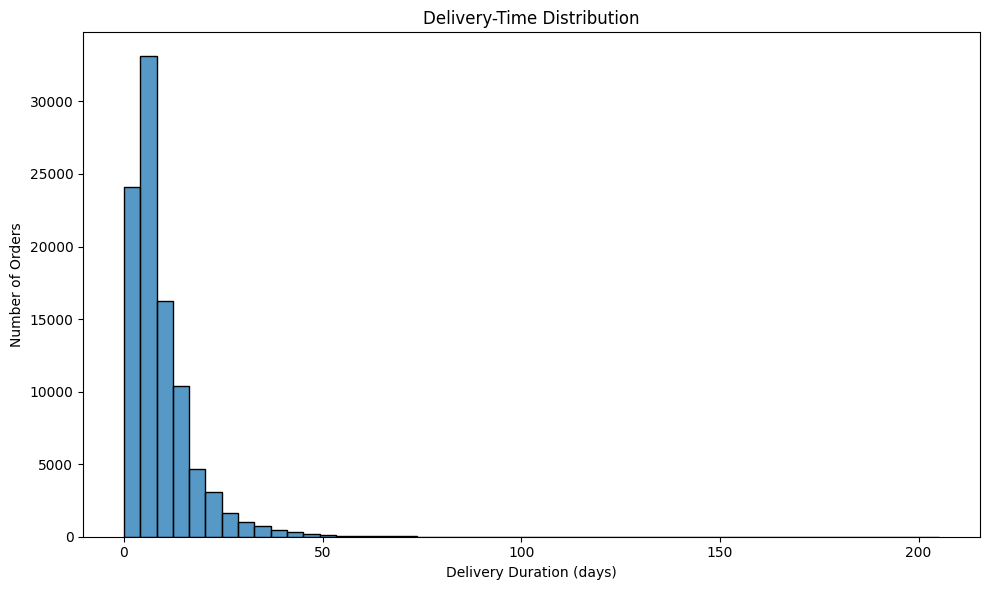

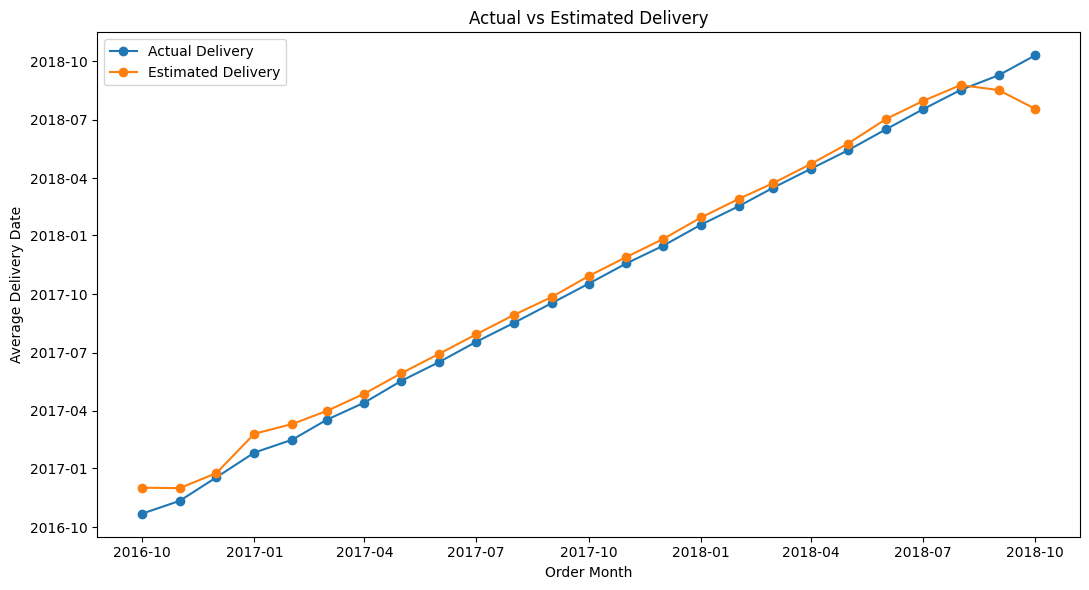

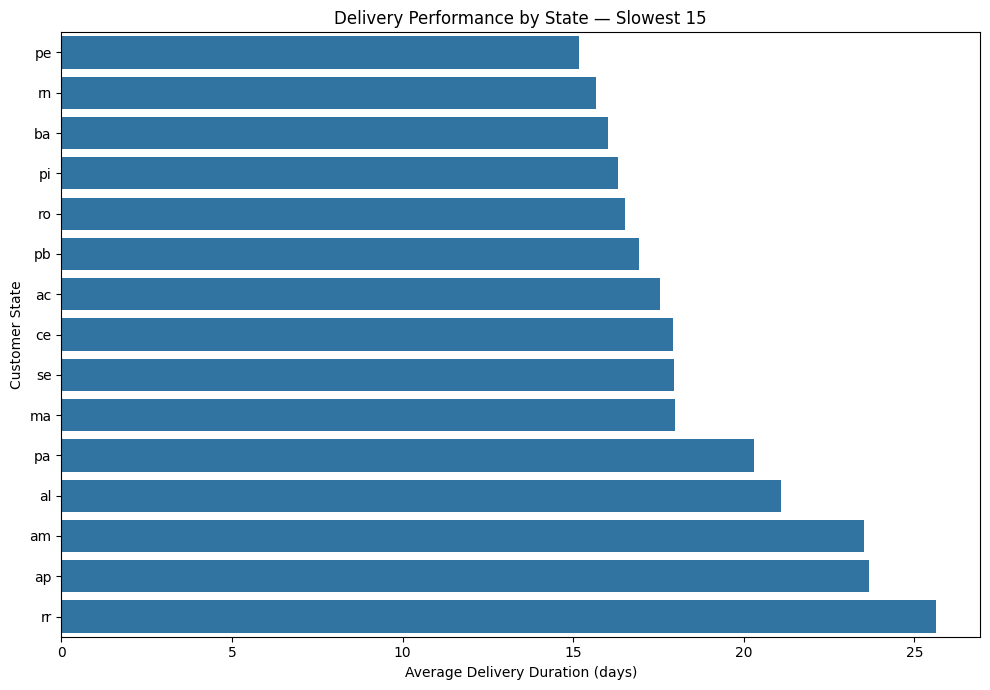

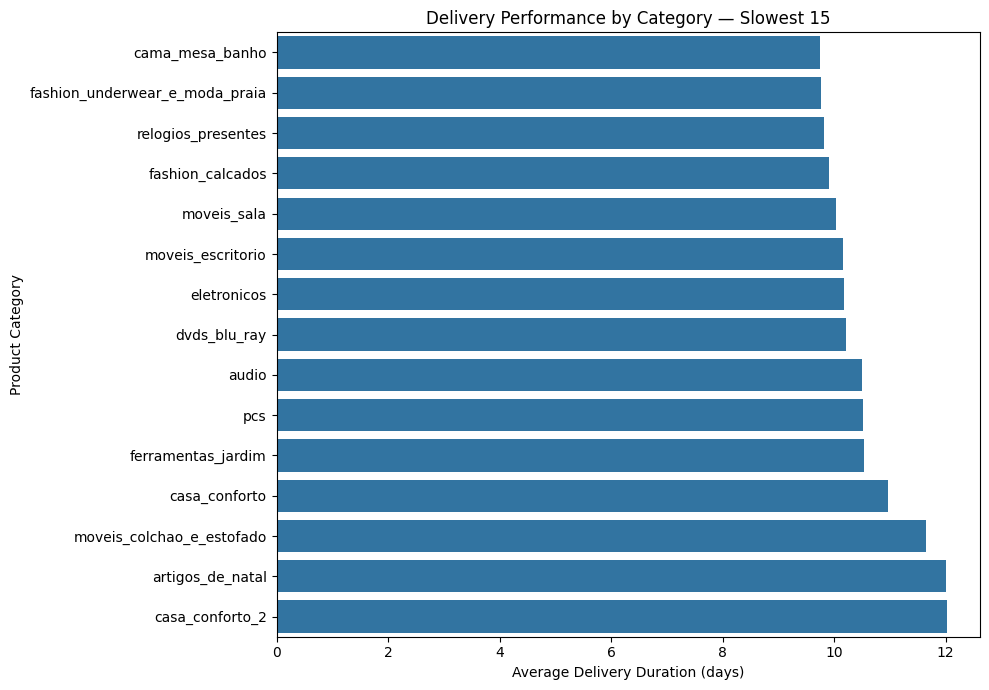

In [63]:
# =============================================================================
# 13.3 REQUIRED DELIVERY ANALYSIS CHARTS
# =============================================================================

# -----------------------------------------------------------------------------
# CHART 1 — DELIVERY-TIME DISTRIBUTION
# -----------------------------------------------------------------------------

delivery_chart_data = delivery_eda[
    delivery_eda["delivery_duration_days"].ge(0)
].copy()

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=delivery_chart_data,
    x="delivery_duration_days",
    bins=50,
    kde=False,
    ax=ax,
)

ax.set_title("Delivery-Time Distribution")
ax.set_xlabel("Delivery Duration (days)")
ax.set_ylabel("Number of Orders")

fig.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# CHART 2 — ACTUAL VS ESTIMATED DELIVERY
# -----------------------------------------------------------------------------

actual_estimated = delivery_eda.dropna(
    subset=[
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ]
).copy()

actual_estimated["month"] = (
    actual_estimated["order_delivered_customer_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

actual_estimated_monthly = (
    actual_estimated
    .groupby("month", as_index=False)
    .agg(
        actual_delivery=(
            "order_delivered_customer_date",
            "mean",
        ),
        estimated_delivery=(
            "order_estimated_delivery_date",
            "mean",
        ),
    )
)

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    actual_estimated_monthly["month"],
    actual_estimated_monthly["actual_delivery"],
    marker="o",
    label="Actual Delivery",
)

ax.plot(
    actual_estimated_monthly["month"],
    actual_estimated_monthly["estimated_delivery"],
    marker="o",
    label="Estimated Delivery",
)

ax.set_title("Actual vs Estimated Delivery")
ax.set_xlabel("Order Month")
ax.set_ylabel("Average Delivery Date")
ax.legend()

fig.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# CHART 3 — DELIVERY PERFORMANCE BY STATE
# -----------------------------------------------------------------------------

state_chart = (
    delivery_state_performance
    .dropna(subset=["average_delivery_days"])
    .sort_values("average_delivery_days")
    .tail(15)
)

fig, ax = plt.subplots(figsize=(10, 7))

sns.barplot(
    data=state_chart,
    x="average_delivery_days",
    y="customer_state",
    ax=ax,
)

ax.set_title("Delivery Performance by State — Slowest 15")
ax.set_xlabel("Average Delivery Duration (days)")
ax.set_ylabel("Customer State")

fig.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# CHART 4 — DELIVERY PERFORMANCE BY CATEGORY
# -----------------------------------------------------------------------------

category_chart = (
    delivery_category_performance
    .dropna(subset=["average_delivery_days"])
    .sort_values("average_delivery_days")
    .tail(15)
)

fig, ax = plt.subplots(figsize=(10, 7))

sns.barplot(
    data=category_chart,
    x="average_delivery_days",
    y="product_category_name_english",
    ax=ax,
)

ax.set_title("Delivery Performance by Category — Slowest 15")
ax.set_xlabel("Average Delivery Duration (days)")
ax.set_ylabel("Product Category")

fig.tight_layout()
plt.show()

## 14. Order Status Analysis

Analyze delivered, canceled, unavailable, invoiced, shipped, processing, approved, and created orders.

### Required charts
1. Order-status distribution
2. Status by month
3. Status by category
4. Status by state

Use this section to identify operational patterns and potential anomalies.

In [65]:
# =============================================================================
# 14.1 ORDER STATUS ANALYSIS — PREPARATION & AGGREGATION
# =============================================================================

print("=" * 80)
print("PHASE 10 — ORDER STATUS ANALYSIS")
print("=" * 80)

# -----------------------------------------------------------------------------
# 1. Validate order data
# -----------------------------------------------------------------------------

required_orders = [
    "order_id",
    "order_status",
    "order_purchase_timestamp",
    "customer_id",
]

for field in required_orders:
    assert field in orders.columns, f"Missing order field: {field}"

status_eda = orders[required_orders].copy()

status_eda["order_status"] = (
    status_eda["order_status"]
    .astype("string")
    .str.strip()
    .fillna("unknown")
    .replace("", "unknown")
)

status_eda["order_purchase_timestamp"] = pd.to_datetime(
    status_eda["order_purchase_timestamp"],
    errors="coerce",
)

status_eda["order_month"] = (
    status_eda["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype("string")
)

assert status_eda["order_id"].is_unique


# -----------------------------------------------------------------------------
# 2. Order-status distribution
# -----------------------------------------------------------------------------

order_status_distribution = (
    status_eda
    .groupby("order_status", as_index=False)
    .agg(
        orders=("order_id", "nunique")
    )
    .sort_values("orders", ascending=False)
    .reset_index(drop=True)
)

order_status_distribution["percentage"] = (
    order_status_distribution["orders"]
    / order_status_distribution["orders"].sum()
    * 100
)


# -----------------------------------------------------------------------------
# 3. Status by month
# -----------------------------------------------------------------------------

status_by_month = (
    status_eda
    .groupby(
        ["order_month", "order_status"],
        as_index=False,
    )
    .agg(
        orders=("order_id", "nunique")
    )
    .sort_values(
        ["order_month", "order_status"]
    )
    .reset_index(drop=True)
)


# -----------------------------------------------------------------------------
# 4. Customer state mapping
# -----------------------------------------------------------------------------

assert "customer_id" in customers.columns
assert "customer_state" in customers.columns

customer_state_map = customers[
    ["customer_id", "customer_state"]
].copy()

customer_state_map["customer_state"] = (
    customer_state_map["customer_state"]
    .astype("string")
    .str.strip()
    .fillna("Unknown / Missing")
    .replace("", "Unknown / Missing")
)

assert customer_state_map["customer_id"].is_unique

status_state_base = status_eda.merge(
    customer_state_map,
    on="customer_id",
    how="left",
    validate="many_to_one",
)

status_state_base["customer_state"] = (
    status_state_base["customer_state"]
    .astype("string")
    .fillna("Unknown / Missing")
)


# -----------------------------------------------------------------------------
# 5. Status by state
# -----------------------------------------------------------------------------

status_by_state = (
    status_state_base
    .groupby(
        ["customer_state", "order_status"],
        as_index=False,
    )
    .agg(
        orders=("order_id", "nunique")
    )
    .sort_values(
        ["customer_state", "orders"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)


# -----------------------------------------------------------------------------
# 6. Product/category mapping
# -----------------------------------------------------------------------------

assert "order_id" in order_items.columns
assert "product_id" in order_items.columns
assert "product_id" in products.columns

product_category_columns = [
    column
    for column in [
        "product_category_name_english",
        "product_category_name",
    ]
    if column in products.columns
]

assert product_category_columns, (
    "No product category column found in products."
)

product_category_column = product_category_columns[0]

category_map = order_items[
    ["order_id", "product_id"]
].merge(
    products[
        ["product_id", product_category_column]
    ],
    on="product_id",
    how="left",
    validate="many_to_one",
)

category_map = category_map.rename(
    columns={
        product_category_column: "product_category"
    }
)

category_map["product_category"] = (
    category_map["product_category"]
    .astype("string")
    .str.strip()
    .fillna("Unknown / Untranslated")
    .replace("", "Unknown / Untranslated")
)


# -----------------------------------------------------------------------------
# 7. Use category translation when available
# -----------------------------------------------------------------------------

if "category_translation" in globals():

    translation_columns = set(category_translation.columns)

    if {
        "product_category_name",
        "product_category_name_english",
    }.issubset(translation_columns):

        translation_map = category_translation[
            [
                "product_category_name",
                "product_category_name_english",
            ]
        ].drop_duplicates()

        translation_map["product_category_name"] = (
            translation_map["product_category_name"]
            .astype("string")
            .str.strip()
        )

        translation_map["product_category_name_english"] = (
            translation_map["product_category_name_english"]
            .astype("string")
            .str.strip()
        )

        category_map = category_map.merge(
            translation_map,
            left_on="product_category",
            right_on="product_category_name",
            how="left",
        )

        category_map["product_category"] = (
            category_map["product_category_name_english"]
            .fillna(category_map["product_category"])
            .fillna("Unknown / Untranslated")
        )

        category_map = category_map[
            ["order_id", "product_category"]
        ]

# One order can contain multiple products/categories.
# Remove duplicate order-category combinations so orders are not inflated.
category_map = category_map.drop_duplicates()


# -----------------------------------------------------------------------------
# 8. Status by category
# -----------------------------------------------------------------------------

status_by_category = status_eda[
    ["order_id", "order_status"]
].merge(
    category_map,
    on="order_id",
    how="inner",
)

status_by_category = (
    status_by_category
    .groupby(
        ["product_category", "order_status"],
        as_index=False,
    )
    .agg(
        orders=("order_id", "nunique")
    )
    .sort_values(
        ["product_category", "orders"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)


# -----------------------------------------------------------------------------
# 9. Summary
# -----------------------------------------------------------------------------

order_status_summary = pd.DataFrame({
    "Metric": [
        "Total orders",
        "Order statuses",
        "Delivered orders",
        "Canceled orders",
        "Unavailable orders",
        "Invoiced orders",
        "Shipped orders",
        "Processing orders",
        "Approved orders",
        "Created orders",
    ],
    "Value": [
        status_eda["order_id"].nunique(),
        status_eda["order_status"].nunique(),

        status_eda.loc[
            status_eda["order_status"] == "delivered",
            "order_id"
        ].nunique(),

        status_eda.loc[
            status_eda["order_status"] == "canceled",
            "order_id"
        ].nunique(),

        status_eda.loc[
            status_eda["order_status"] == "unavailable",
            "order_id"
        ].nunique(),

        status_eda.loc[
            status_eda["order_status"] == "invoiced",
            "order_id"
        ].nunique(),

        status_eda.loc[
            status_eda["order_status"] == "shipped",
            "order_id"
        ].nunique(),

        status_eda.loc[
            status_eda["order_status"] == "processing",
            "order_id"
        ].nunique(),

        status_eda.loc[
            status_eda["order_status"] == "approved",
            "order_id"
        ].nunique(),

        status_eda.loc[
            status_eda["order_status"] == "created",
            "order_id"
        ].nunique(),
    ],
})


# -----------------------------------------------------------------------------
# 10. Validation
# -----------------------------------------------------------------------------

assert not status_eda.empty
assert not order_status_distribution.empty
assert not status_by_month.empty
assert not status_by_state.empty
assert not status_by_category.empty

assert (
    order_status_distribution["orders"].sum()
    == status_eda["order_id"].nunique()
)

assert (
    status_by_month["orders"].sum()
    == status_eda["order_id"].nunique()
)

assert (
    status_by_state["orders"].sum()
    == status_eda["order_id"].nunique()
)

assert (
    order_status_distribution["percentage"].sum()
    >= 99.999
)

assert (
    order_status_distribution["percentage"].sum()
    <= 100.001
)


# -----------------------------------------------------------------------------
# 11. Output
# -----------------------------------------------------------------------------

display(order_status_summary)
display(order_status_distribution)
display(status_by_month.head(20))
display(status_by_state.head(30))
display(status_by_category.head(30))

print("-" * 80)
print(f"Orders analyzed       : {status_eda['order_id'].nunique():,}")
print(f"Statuses identified    : {status_eda['order_status'].nunique():,}")
print(f"Months analyzed       : {status_eda['order_month'].nunique():,}")
print(
    f"States analyzed       : "
    f"{status_by_state['customer_state'].nunique():,}"
)
print(
    f"Categories analyzed   : "
    f"{status_by_category['product_category'].nunique():,}"
)
print(f"Category source       : {product_category_column}")
print(
    "Category translation  : "
    + ("Applied" if "category_translation" in globals() else "Not available")
)
print("-" * 80)
print("Order-status aggregation : PASS")
print("Monthly validation       : PASS")
print("State validation         : PASS")
print("Category validation      : PASS")
print("ORDER STATUS ANALYSIS PREP : PASS")
print("=" * 80)

PHASE 10 — ORDER STATUS ANALYSIS


,Metric,Value
0,Total orders,99441
1,Order statuses,8
2,Delivered orders,96478
3,Canceled orders,625
4,Unavailable orders,609
5,Invoiced orders,314
6,Shipped orders,1107
7,Processing orders,301
8,Approved orders,2
9,Created orders,5


,order_status,orders,percentage
0,delivered,96478,97.020344
1,shipped,1107,1.113223
2,canceled,625,0.628513
3,unavailable,609,0.612423
4,invoiced,314,0.315765
5,processing,301,0.302692
6,created,5,0.005028
7,approved,2,0.002011


,order_month,order_status,orders
0,2016-09,canceled,2
1,2016-09,delivered,1
2,2016-09,shipped,1
3,2016-10,canceled,24
4,2016-10,delivered,265
5,2016-10,invoiced,18
6,2016-10,processing,2
7,2016-10,shipped,8
8,2016-10,unavailable,7
9,2016-12,delivered,1


,customer_state,order_status,orders
0,ac,delivered,80
1,ac,shipped,1
2,al,delivered,397
3,al,shipped,9
4,al,processing,3
5,al,invoiced,2
6,al,canceled,1
7,al,unavailable,1
8,am,delivered,145
9,am,shipped,2


,product_category,order_status,orders
0,Unknown / Untranslated,delivered,1392
1,Unknown / Untranslated,shipped,24
2,Unknown / Untranslated,canceled,14
3,Unknown / Untranslated,processing,13
4,Unknown / Untranslated,invoiced,8
5,agro_industria_e_comercio,delivered,177
6,agro_industria_e_comercio,shipped,4
7,agro_industria_e_comercio,invoiced,1
8,alimentos,delivered,441
9,alimentos,processing,5


--------------------------------------------------------------------------------
Orders analyzed       : 99,441
Statuses identified    : 8
Months analyzed       : 25
States analyzed       : 27
Categories analyzed   : 74
Category source       : product_category_name
Category translation  : Not available
--------------------------------------------------------------------------------
Order-status aggregation : PASS
Monthly validation       : PASS
State validation         : PASS
Category validation      : PASS
ORDER STATUS ANALYSIS PREP : PASS


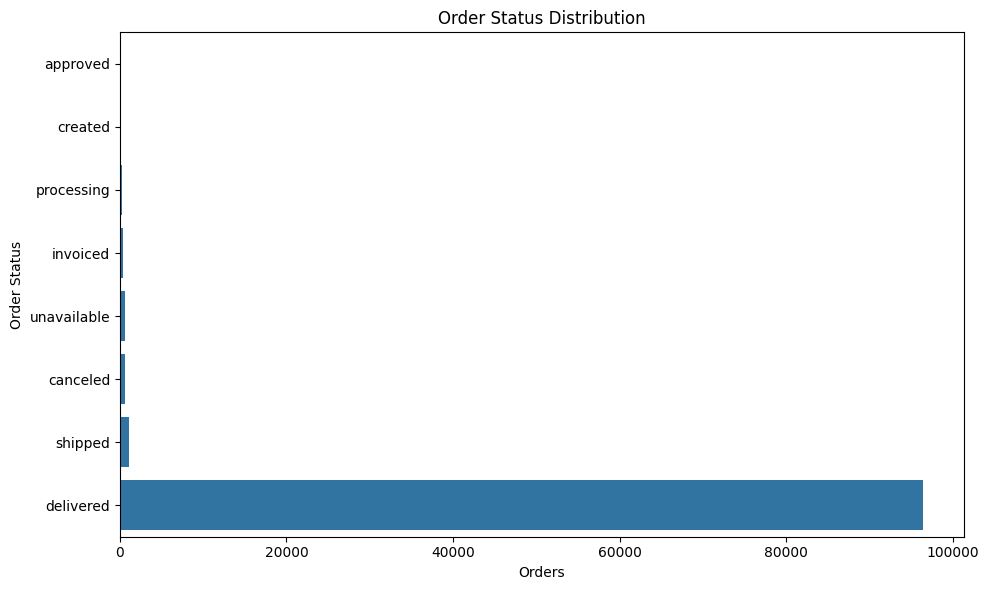

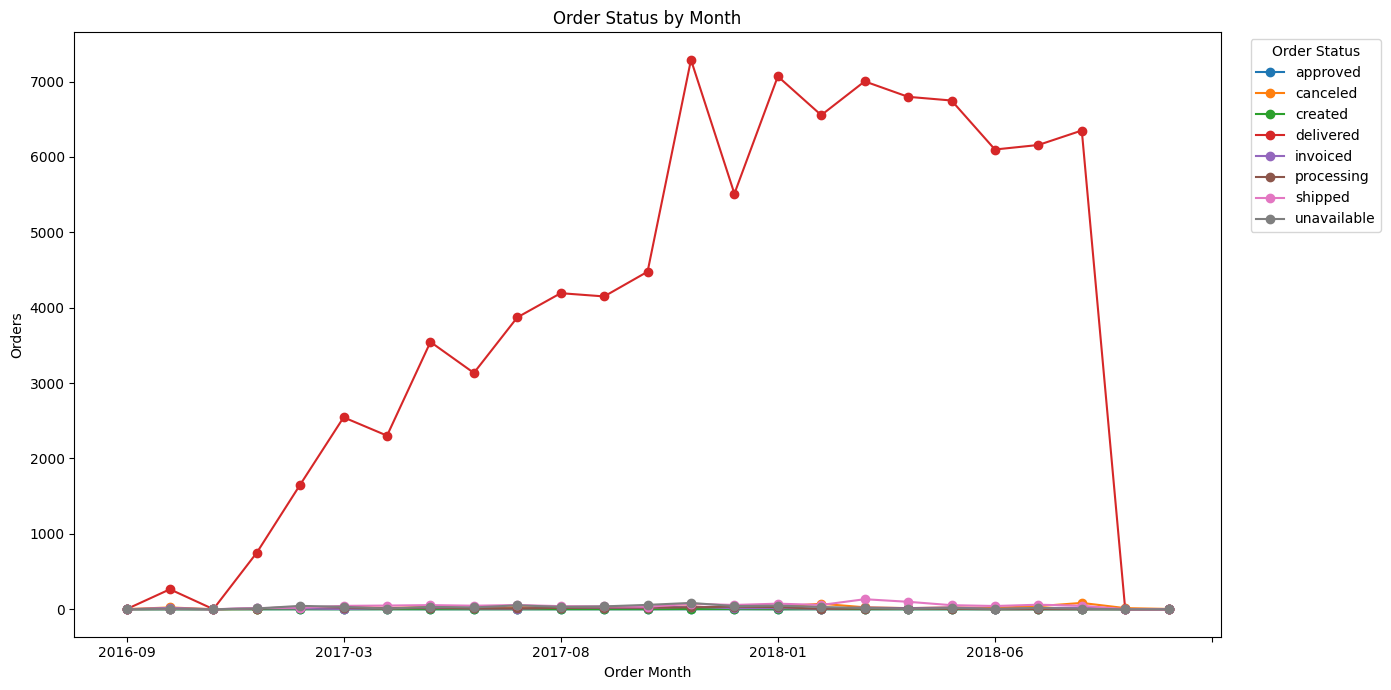

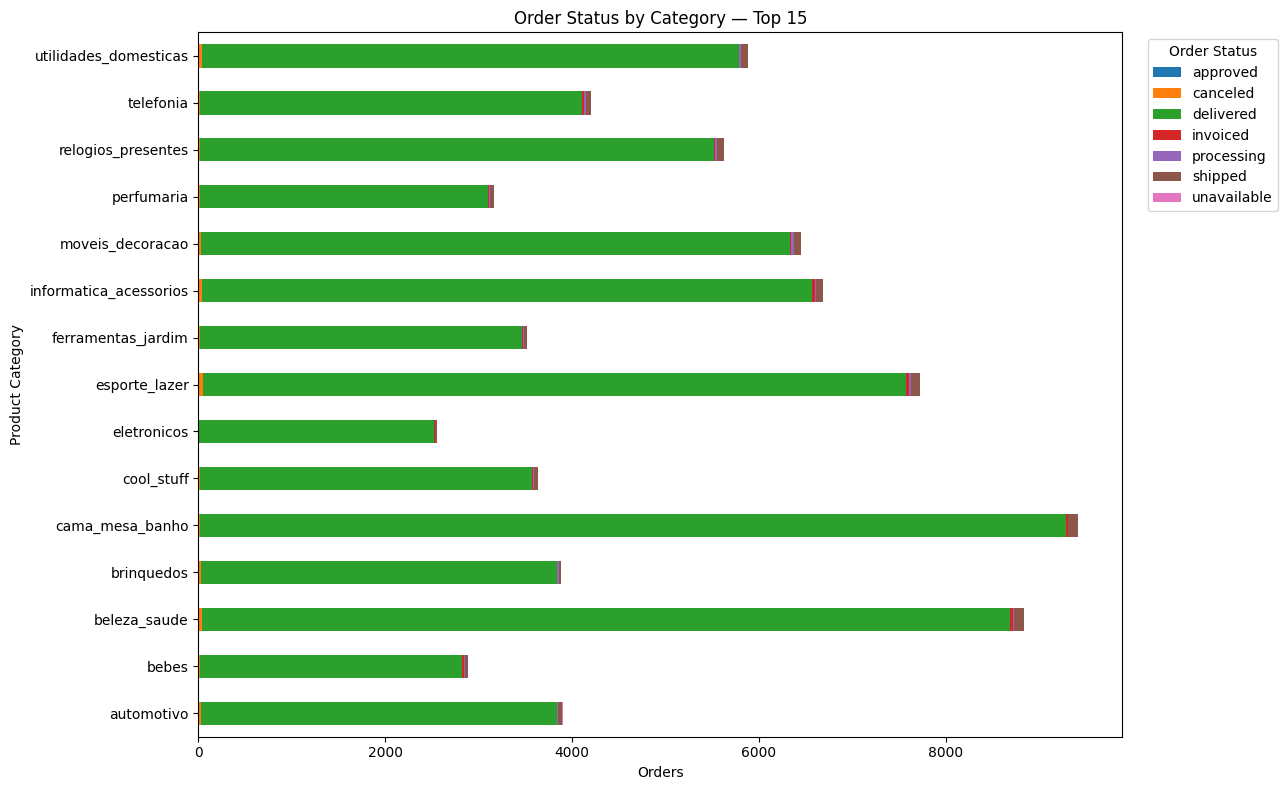

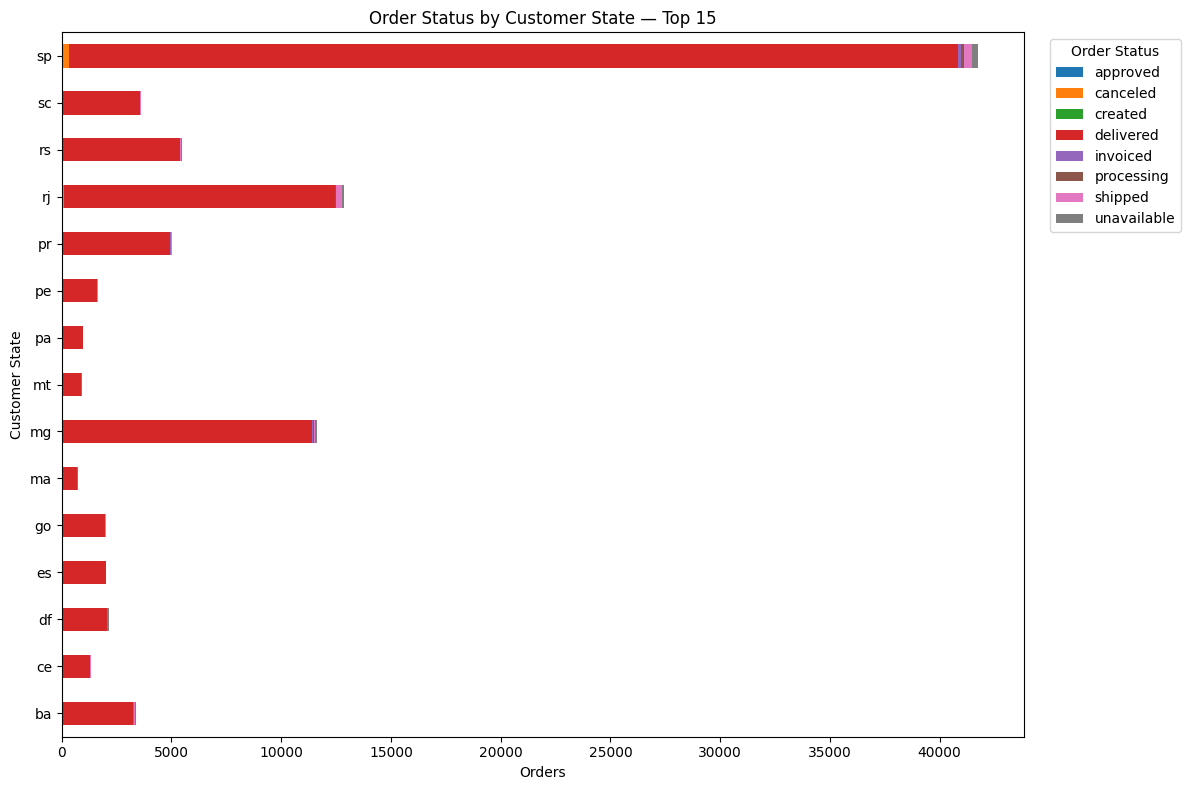

ORDER STATUS ANALYSIS CHARTS GENERATED


In [66]:
# =============================================================================
# 14.2 REQUIRED ORDER STATUS ANALYSIS CHARTS
# =============================================================================

# -----------------------------------------------------------------------------
# CHART 1 — ORDER-STATUS DISTRIBUTION
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=order_status_distribution.sort_values("orders"),
    x="orders",
    y="order_status",
    ax=ax,
)

ax.set_title("Order Status Distribution")
ax.set_xlabel("Orders")
ax.set_ylabel("Order Status")

fig.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# CHART 2 — STATUS BY MONTH
# -----------------------------------------------------------------------------

monthly_chart = (
    status_by_month
    .pivot(
        index="order_month",
        columns="order_status",
        values="orders",
    )
    .fillna(0)
    .sort_index()
)

fig, ax = plt.subplots(figsize=(14, 7))

monthly_chart.plot(
    kind="line",
    marker="o",
    ax=ax,
)

ax.set_title("Order Status by Month")
ax.set_xlabel("Order Month")
ax.set_ylabel("Orders")

ax.legend(
    title="Order Status",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

fig.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# CHART 3 — STATUS BY CATEGORY
# -----------------------------------------------------------------------------

category_chart = (
    status_by_category
    .pivot(
        index="product_category",
        columns="order_status",
        values="orders",
    )
    .fillna(0)
)

category_chart["total_orders"] = category_chart.sum(axis=1)

category_chart = (
    category_chart
    .sort_values("total_orders", ascending=False)
    .head(15)
    .drop(columns="total_orders")
    .sort_index()
)

fig, ax = plt.subplots(figsize=(13, 8))

category_chart.plot(
    kind="barh",
    stacked=True,
    ax=ax,
)

ax.set_title("Order Status by Category — Top 15")
ax.set_xlabel("Orders")
ax.set_ylabel("Product Category")

ax.legend(
    title="Order Status",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

fig.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# CHART 4 — STATUS BY STATE
# -----------------------------------------------------------------------------

state_chart = (
    status_by_state
    .pivot(
        index="customer_state",
        columns="order_status",
        values="orders",
    )
    .fillna(0)
)

state_chart["total_orders"] = state_chart.sum(axis=1)

state_chart = (
    state_chart
    .sort_values("total_orders", ascending=False)
    .head(15)
    .drop(columns="total_orders")
    .sort_index()
)

fig, ax = plt.subplots(figsize=(12, 8))

state_chart.plot(
    kind="barh",
    stacked=True,
    ax=ax,
)

ax.set_title("Order Status by Customer State — Top 15")
ax.set_xlabel("Orders")
ax.set_ylabel("Customer State")

ax.legend(
    title="Order Status",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

fig.tight_layout()
plt.show()


print("=" * 80)
print("ORDER STATUS ANALYSIS CHARTS GENERATED")
print("=" * 80)

    ## 15. Relationship Analysis

    Investigate:
    - Price vs review score
    - Freight value vs price
    - Delivery duration vs review score
    - Installments vs payment value
    - Product photos vs review score
    - Product description length vs review score

    Use scatter plots and correlation measures where appropriate.

    **Rule:** Correlation does not establish causation.
    

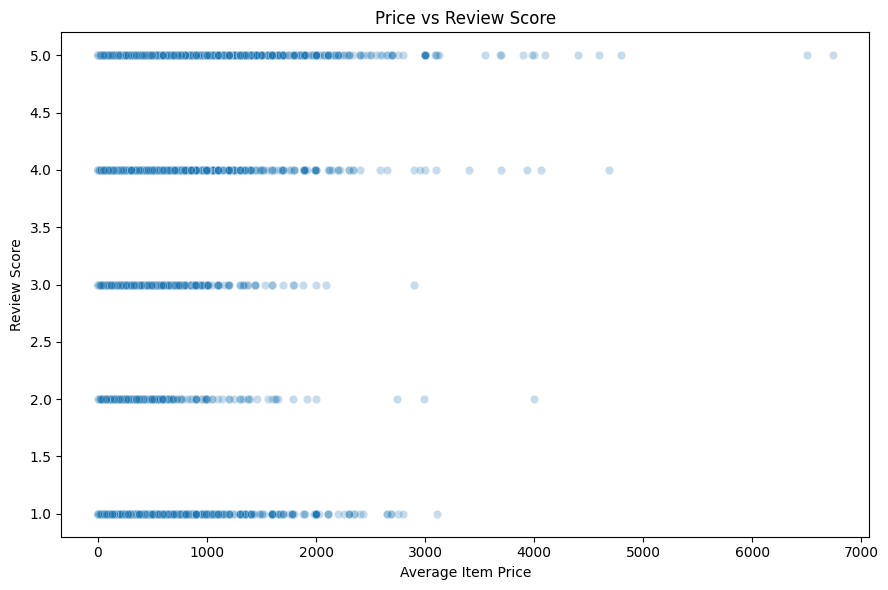

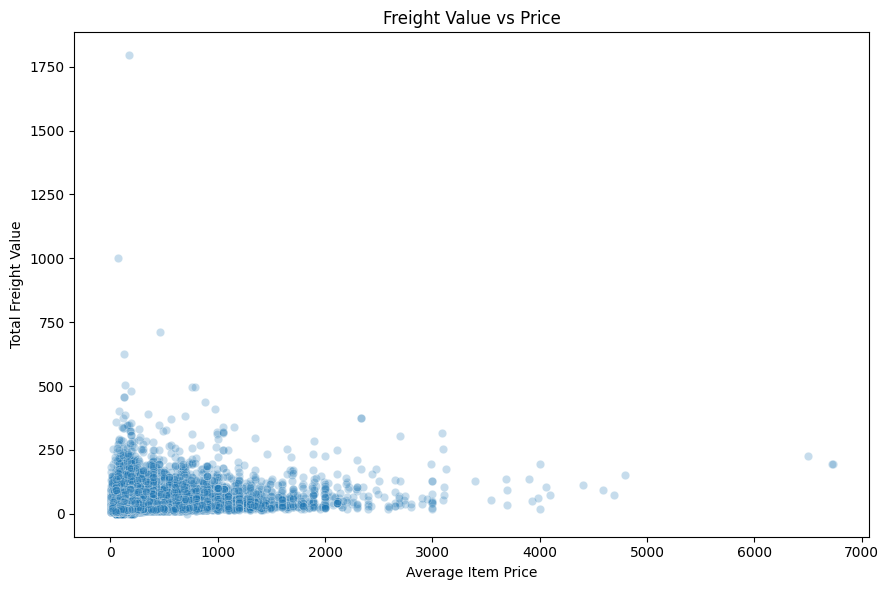

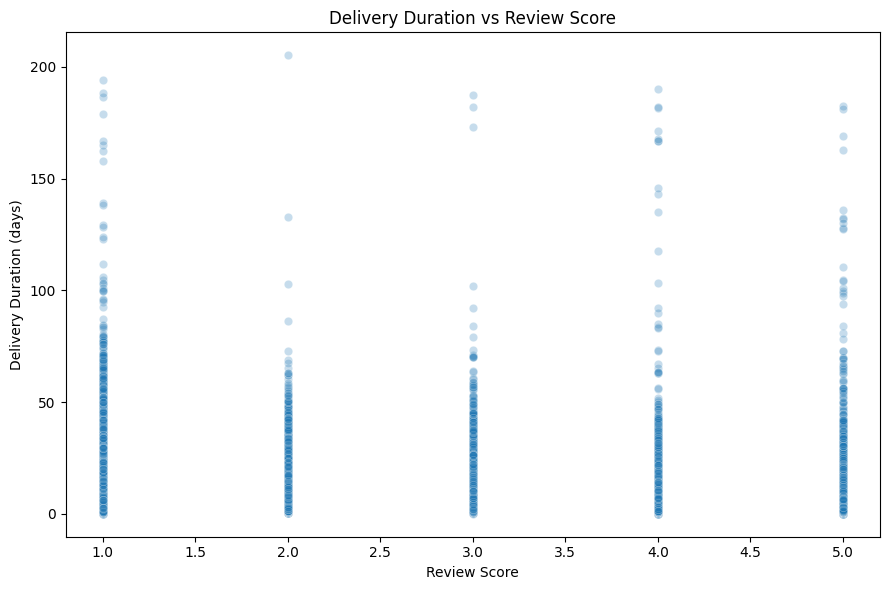

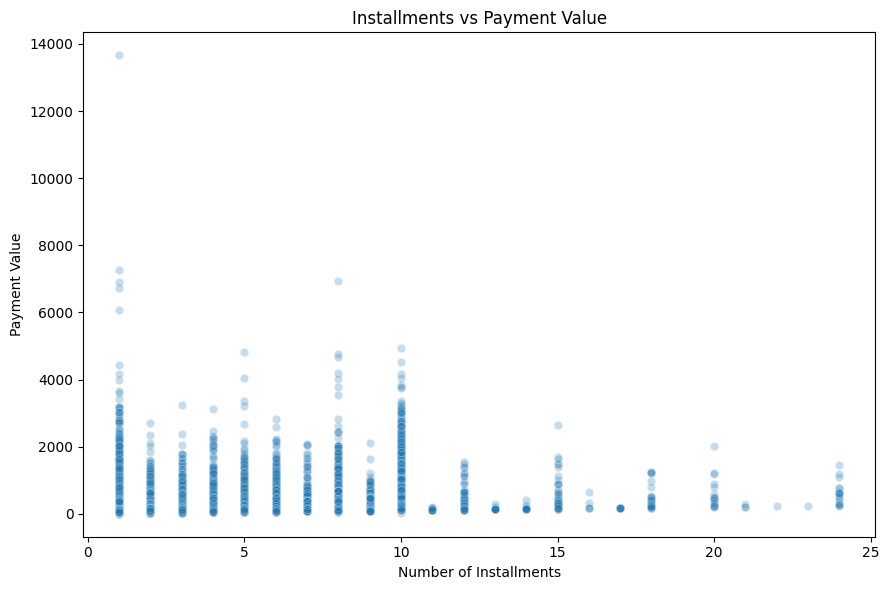

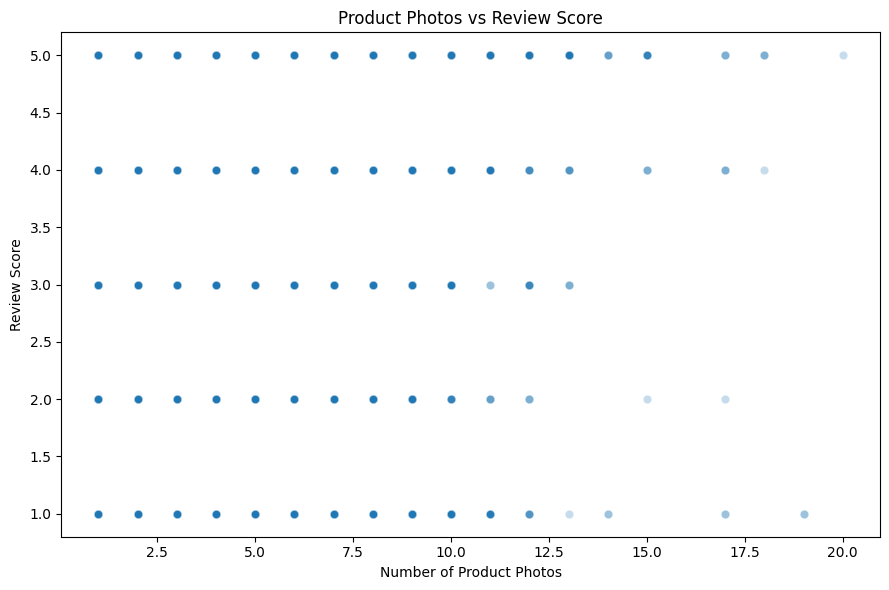

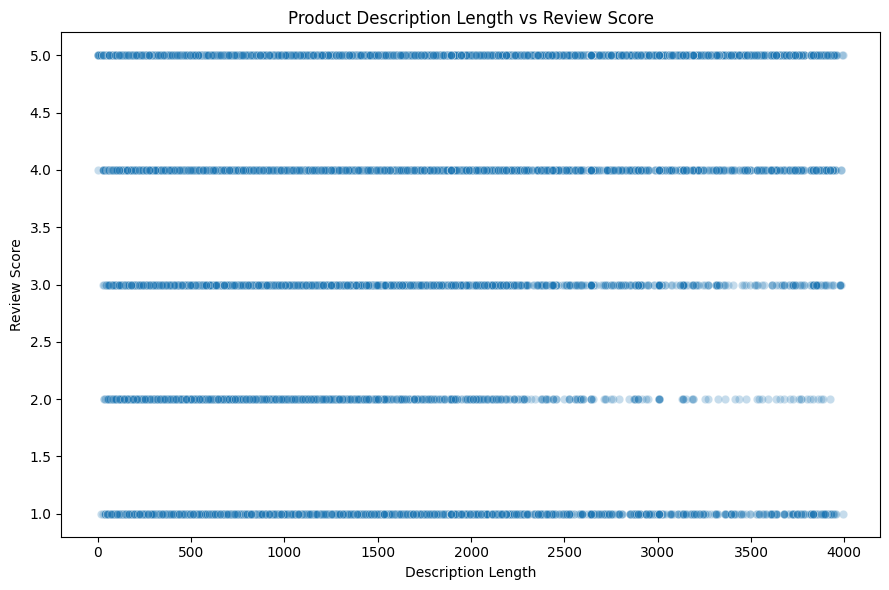

In [69]:
# =============================================================================
# 15.2 REQUIRED RELATIONSHIP CHARTS
# =============================================================================

# -----------------------------------------------------------------------------
# 1. PRICE VS REVIEW SCORE
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 6))

sns.scatterplot(
    data=price_review,
    x="price",
    y="review_score",
    alpha=0.25,
    ax=ax,
)

ax.set_title("Price vs Review Score")
ax.set_xlabel("Average Item Price")
ax.set_ylabel("Review Score")

fig.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# 2. FREIGHT VALUE VS PRICE
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 6))

sns.scatterplot(
    data=freight_price,
    x="price",
    y="freight_value",
    alpha=0.25,
    ax=ax,
)

ax.set_title("Freight Value vs Price")
ax.set_xlabel("Average Item Price")
ax.set_ylabel("Total Freight Value")

fig.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# 3. DELIVERY DURATION VS REVIEW SCORE
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 6))

sns.scatterplot(
    data=delivery_review,
    x="review_score",
    y="delivery_duration_days",
    alpha=0.25,
    ax=ax,
)

ax.set_title("Delivery Duration vs Review Score")
ax.set_xlabel("Review Score")
ax.set_ylabel("Delivery Duration (days)")

fig.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# 4. INSTALLMENTS VS PAYMENT VALUE
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 6))

sns.scatterplot(
    data=installment_payment,
    x="payment_installments",
    y="payment_value",
    alpha=0.25,
    ax=ax,
)

ax.set_title("Installments vs Payment Value")
ax.set_xlabel("Number of Installments")
ax.set_ylabel("Payment Value")

fig.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# 5. PRODUCT PHOTOS VS REVIEW SCORE
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 6))

sns.scatterplot(
    data=product_review,
    x="product_photos_qty",
    y="review_score",
    alpha=0.25,
    ax=ax,
)

ax.set_title("Product Photos vs Review Score")
ax.set_xlabel("Number of Product Photos")
ax.set_ylabel("Review Score")

fig.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# 6. PRODUCT DESCRIPTION LENGTH VS REVIEW SCORE
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 6))

sns.scatterplot(
    data=product_review,
    x="product_description_lenght",
    y="review_score",
    alpha=0.25,
    ax=ax,
)

ax.set_title("Product Description Length vs Review Score")
ax.set_xlabel("Description Length")
ax.set_ylabel("Review Score")

fig.tight_layout()
plt.show()

## 16. Anomaly Detection

Identify unusual observations across transactions, orders, items, operations, and customers.

### Analyze

- Transaction anomalies
- Extreme order values
- Extreme item prices
- Extreme freight values
- Extreme item counts
- Extremely long delivery times
- Delivery after estimated date
- Unusual cancellation periods
- Extremely high customer order frequency
- Extremely high customer revenue

### Statistical approach

Use:

- IQR
- Percentiles
- Z-score where appropriate
- Domain thresholds

### Important rule

Do not automatically delete anomalies.

EDA identifies unusual observations; it does not clean them.

An anomaly should be investigated separately before any data-cleaning decision is made.

In [70]:
# =============================================================================
# 16.1 ANOMALY DETECTION — PREPARATION
# =============================================================================

print("=" * 80)
print("PHASE 10 — ANOMALY DETECTION")
print("=" * 80)


# -----------------------------------------------------------------------------
# Validate required data
# -----------------------------------------------------------------------------

required_sources = {
    "order_items": ["order_id", "price", "freight_value"],
    "orders": [
        "order_id",
        "customer_id",
        "order_status",
        "order_purchase_timestamp",
    ],
    "customers": ["customer_id", "customer_unique_id"],
    "payments": ["order_id", "payment_value"],
}

for df_name, columns in required_sources.items():
    df = globals()[df_name]

    for column in columns:
        assert column in df.columns, (
            f"Missing column '{column}' in {df_name}: {column}"
        )


# -----------------------------------------------------------------------------
# Statistical helpers
# -----------------------------------------------------------------------------

def iqr_bounds(series):
    values = pd.to_numeric(
        series,
        errors="coerce",
    ).dropna()

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return q1, q3, lower, upper


def calculate_z_score(series):
    values = pd.to_numeric(
        series,
        errors="coerce",
    )

    mean = values.mean()
    std = values.std()

    if pd.isna(std) or std == 0:
        return pd.Series(
            0.0,
            index=values.index,
        )

    return (values - mean) / std


# -----------------------------------------------------------------------------
# Transaction / payment anomalies
# -----------------------------------------------------------------------------

transaction_anomalies = payments[
    ["order_id", "payment_value"]
].copy()

transaction_anomalies["payment_value"] = pd.to_numeric(
    transaction_anomalies["payment_value"],
    errors="coerce",
)

transaction_anomalies = transaction_anomalies.dropna(
    subset=["payment_value"]
).copy()

(
    payment_q1,
    payment_q3,
    payment_lower,
    payment_upper,
) = iqr_bounds(
    transaction_anomalies["payment_value"]
)

transaction_anomalies["z_score"] = calculate_z_score(
    transaction_anomalies["payment_value"]
)

transaction_anomalies["iqr_anomaly"] = (
    (transaction_anomalies["payment_value"] < payment_lower)
    |
    (transaction_anomalies["payment_value"] > payment_upper)
)

transaction_anomalies["z_score_anomaly"] = (
    transaction_anomalies["z_score"].abs() >= 3
)

transaction_anomalies["anomaly_flag"] = (
    transaction_anomalies["iqr_anomaly"]
    |
    transaction_anomalies["z_score_anomaly"]
)


# -----------------------------------------------------------------------------
# Item price and freight anomalies
# -----------------------------------------------------------------------------

item_anomalies = order_items[
    [
        "order_id",
        "price",
        "freight_value",
    ]
].copy()

item_anomalies["price"] = pd.to_numeric(
    item_anomalies["price"],
    errors="coerce",
)

item_anomalies["freight_value"] = pd.to_numeric(
    item_anomalies["freight_value"],
    errors="coerce",
)


# Price

(
    price_q1,
    price_q3,
    price_lower,
    price_upper,
) = iqr_bounds(
    item_anomalies["price"]
)

item_anomalies["price_z_score"] = calculate_z_score(
    item_anomalies["price"]
)

item_anomalies["extreme_price"] = (
    (item_anomalies["price"] < price_lower)
    |
    (item_anomalies["price"] > price_upper)
)


# Freight

(
    freight_q1,
    freight_q3,
    freight_lower,
    freight_upper,
) = iqr_bounds(
    item_anomalies["freight_value"]
)

item_anomalies["freight_z_score"] = calculate_z_score(
    item_anomalies["freight_value"]
)

item_anomalies["extreme_freight"] = (
    (item_anomalies["freight_value"] < freight_lower)
    |
    (item_anomalies["freight_value"] > freight_upper)
)


# -----------------------------------------------------------------------------
# Extreme item counts per order
# -----------------------------------------------------------------------------

order_item_counts = (
    order_items
    .groupby("order_id", as_index=False)
    .size()
    .rename(columns={"size": "item_count"})
)

(
    item_count_q1,
    item_count_q3,
    item_count_lower,
    item_count_upper,
) = iqr_bounds(
    order_item_counts["item_count"]
)

order_item_counts["z_score"] = calculate_z_score(
    order_item_counts["item_count"]
)

order_item_counts["extreme_item_count"] = (
    order_item_counts["item_count"]
    > item_count_upper
)


print("Transaction, price, freight and item-count anomalies prepared.")

print("-" * 80)
print(
    f"Payment anomalies     : "
    f"{transaction_anomalies['anomaly_flag'].sum():,}"
)
print(
    f"Extreme item prices   : "
    f"{item_anomalies['extreme_price'].sum():,}"
)
print(
    f"Extreme freight      : "
    f"{item_anomalies['extreme_freight'].sum():,}"
)
print(
    f"Extreme item counts  : "
    f"{order_item_counts['extreme_item_count'].sum():,}"
)

print("-" * 80)
print("ANOMALY PREPARATION : PASS")
print("=" * 80)

PHASE 10 — ANOMALY DETECTION
Transaction, price, freight and item-count anomalies prepared.
--------------------------------------------------------------------------------
Payment anomalies     : 7,981
Extreme item prices   : 8,427
Extreme freight      : 12,134
Extreme item counts  : 9,803
--------------------------------------------------------------------------------
ANOMALY PREPARATION : PASS


In [72]:
# =============================================================================
# 16.2 ANOMALY DETECTION — ORDER, OPERATIONAL & CUSTOMER ANOMALIES
# =============================================================================


# -----------------------------------------------------------------------------
# EXTREME ORDER VALUES
# -----------------------------------------------------------------------------

required_order_item_fields = [
    "order_id",
    "price",
    "freight_value",
]

for field in required_order_item_fields:
    assert field in order_items.columns, (
        f"Missing order-item field: {field}"
    )

order_level_sales = (
    order_items[
        ["order_id", "price", "freight_value"]
    ]
    .copy()
)

order_level_sales["price"] = pd.to_numeric(
    order_level_sales["price"],
    errors="coerce",
)

order_level_sales["freight_value"] = pd.to_numeric(
    order_level_sales["freight_value"],
    errors="coerce",
)

order_level_sales["item_total"] = (
    order_level_sales["price"].fillna(0)
    + order_level_sales["freight_value"].fillna(0)
)

order_value_anomalies = (
    order_level_sales
    .groupby("order_id", as_index=False)
    .agg(
        sales_amount=("item_total", "sum"),
        item_count=("order_id", "size"),
    )
)

(
    order_q1,
    order_q3,
    order_lower,
    order_upper,
) = iqr_bounds(
    order_value_anomalies["sales_amount"]
)

order_value_anomalies["z_score"] = calculate_z_score(
    order_value_anomalies["sales_amount"]
)

order_value_anomalies["extreme_order_value"] = (
    (order_value_anomalies["sales_amount"] < order_lower)
    |
    (order_value_anomalies["sales_amount"] > order_upper)
)


# -----------------------------------------------------------------------------
# EXTREME ITEM COUNTS PER ORDER
# -----------------------------------------------------------------------------

order_item_counts = (
    order_items
    .groupby("order_id", as_index=False)
    .size()
    .rename(columns={"size": "item_count"})
)

(
    item_count_q1,
    item_count_q3,
    item_count_lower,
    item_count_upper,
) = iqr_bounds(
    order_item_counts["item_count"]
)

order_item_counts["z_score"] = calculate_z_score(
    order_item_counts["item_count"]
)

order_item_counts["extreme_item_count"] = (
    order_item_counts["item_count"]
    > item_count_upper
)


# -----------------------------------------------------------------------------
# DELIVERY ANOMALIES
# -----------------------------------------------------------------------------

assert "delivery_eda" in globals(), (
    "Run Section 13 Delivery Analysis before Section 16."
)

delivery_anomalies = delivery_eda.copy()

delivery_anomalies["delivery_duration_days"] = pd.to_numeric(
    delivery_anomalies["delivery_duration_days"],
    errors="coerce",
)

(
    delivery_q1,
    delivery_q3,
    delivery_lower,
    delivery_upper,
) = iqr_bounds(
    delivery_anomalies["delivery_duration_days"]
)

delivery_anomalies["delivery_z_score"] = calculate_z_score(
    delivery_anomalies["delivery_duration_days"]
)

delivery_anomalies["extremely_long_delivery"] = (
    delivery_anomalies["delivery_duration_days"]
    > delivery_upper
)


# -----------------------------------------------------------------------------
# DELIVERY AFTER ESTIMATED DATE
# -----------------------------------------------------------------------------

if "delivery_status" in delivery_anomalies.columns:

    delivery_anomalies["after_estimated_date"] = (
        delivery_anomalies["delivery_status"]
        .astype("string")
        .str.lower()
        .eq("late")
    )

elif "actual_vs_estimated_days" in delivery_anomalies.columns:

    delivery_anomalies["after_estimated_date"] = (
        pd.to_numeric(
            delivery_anomalies["actual_vs_estimated_days"],
            errors="coerce",
        )
        > 0
    )

elif "estimate_variance_days" in delivery_anomalies.columns:

    delivery_anomalies["after_estimated_date"] = (
        pd.to_numeric(
            delivery_anomalies["estimate_variance_days"],
            errors="coerce",
        )
        > 0
    )

else:

    delivery_anomalies["after_estimated_date"] = False


# -----------------------------------------------------------------------------
# UNUSUAL CANCELLATION PERIODS
# -----------------------------------------------------------------------------

cancellation_data = orders[
    [
        "order_id",
        "order_status",
        "order_purchase_timestamp",
    ]
].copy()

cancellation_data["order_purchase_timestamp"] = pd.to_datetime(
    cancellation_data["order_purchase_timestamp"],
    errors="coerce",
)

cancellation_data["order_month"] = (
    cancellation_data["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype("string")
)

monthly_cancellations = (
    cancellation_data[
        cancellation_data["order_status"]
        .astype("string")
        .str.lower()
        .eq("canceled")
    ]
    .groupby("order_month", as_index=False)
    .agg(
        canceled_orders=("order_id", "nunique")
    )
)

if not monthly_cancellations.empty:

    (
        cancellation_q1,
        cancellation_q3,
        cancellation_lower,
        cancellation_upper,
    ) = iqr_bounds(
        monthly_cancellations["canceled_orders"]
    )

    monthly_cancellations["unusual_cancellation_period"] = (
        monthly_cancellations["canceled_orders"]
        > cancellation_upper
    )

else:

    cancellation_upper = np.nan

    monthly_cancellations["unusual_cancellation_period"] = False


# -----------------------------------------------------------------------------
# CUSTOMER ORDER FREQUENCY
# IMPORTANT: customer_unique_id defines the customer
# -----------------------------------------------------------------------------

customer_orders = (
    orders[
        [
            "order_id",
            "customer_id",
        ]
    ]
    .merge(
        customers[
            [
                "customer_id",
                "customer_unique_id",
            ]
        ],
        on="customer_id",
        how="left",
        validate="many_to_one",
    )
)

customer_order_frequency = (
    customer_orders
    .groupby("customer_unique_id", as_index=False)
    .agg(
        order_count=("order_id", "nunique")
    )
)

(
    frequency_q1,
    frequency_q3,
    frequency_lower,
    frequency_upper,
) = iqr_bounds(
    customer_order_frequency["order_count"]
)

customer_order_frequency["z_score"] = calculate_z_score(
    customer_order_frequency["order_count"]
)

customer_order_frequency["extreme_order_frequency"] = (
    customer_order_frequency["order_count"]
    > frequency_upper
)


# -----------------------------------------------------------------------------
# CUSTOMER REVENUE
# -----------------------------------------------------------------------------

customer_revenue = (
    customer_orders
    .merge(
        order_value_anomalies[
            [
                "order_id",
                "sales_amount",
            ]
        ],
        on="order_id",
        how="left",
        validate="one_to_one",
    )
    .groupby("customer_unique_id", as_index=False)
    .agg(
        customer_revenue=("sales_amount", "sum")
    )
)

(
    customer_revenue_q1,
    customer_revenue_q3,
    customer_revenue_lower,
    customer_revenue_upper,
) = iqr_bounds(
    customer_revenue["customer_revenue"]
)

customer_revenue["z_score"] = calculate_z_score(
    customer_revenue["customer_revenue"]
)

customer_revenue["extreme_customer_revenue"] = (
    customer_revenue["customer_revenue"]
    > customer_revenue_upper
)


# -----------------------------------------------------------------------------
# SUMMARY
# -----------------------------------------------------------------------------

print("=" * 80)
print("OPERATIONAL & CUSTOMER ANOMALIES")
print("=" * 80)

print(
    f"Extreme order values       : "
    f"{order_value_anomalies['extreme_order_value'].sum():,}"
)

print(
    f"Extreme item counts        : "
    f"{order_item_counts['extreme_item_count'].sum():,}"
)

print(
    f"Extreme item prices        : "
    f"{item_anomalies['extreme_price'].sum():,}"
)

print(
    f"Extreme freight values     : "
    f"{item_anomalies['extreme_freight'].sum():,}"
)

print(
    f"Extremely long deliveries  : "
    f"{delivery_anomalies['extremely_long_delivery'].sum():,}"
)

print(
    f"Delivery after estimate    : "
    f"{delivery_anomalies['after_estimated_date'].sum():,}"
)

print(
    f"Unusual cancellation months: "
    f"{monthly_cancellations['unusual_cancellation_period'].sum():,}"
)

print(
    f"Extreme customer frequency : "
    f"{customer_order_frequency['extreme_order_frequency'].sum():,}"
)

print(
    f"Extreme customer revenue   : "
    f"{customer_revenue['extreme_customer_revenue'].sum():,}"
)

print("-" * 80)
print("ORDER / OPERATIONAL / CUSTOMER ANOMALIES : PASS")
print("=" * 80)

OPERATIONAL & CUSTOMER ANOMALIES
Extreme order values       : 7,775
Extreme item counts        : 9,803
Extreme item prices        : 8,427
Extreme freight values     : 12,134
Extremely long deliveries  : 5,065
Delivery after estimate    : 7,827
Unusual cancellation months: 2
Extreme customer frequency : 2,997
Extreme customer revenue   : 7,643
--------------------------------------------------------------------------------
ORDER / OPERATIONAL / CUSTOMER ANOMALIES : PASS


In [73]:
# =============================================================================
# 16.3 ANOMALY DETECTION — SUMMARY TABLES
# =============================================================================

anomaly_summary = pd.DataFrame([
    {
        "anomaly_type": "Transaction / Payment Value",
        "method": "IQR + Z-score",
        "anomalies": int(
            transaction_anomalies["anomaly_flag"].sum()
        ),
    },
    {
        "anomaly_type": "Extreme Order Value",
        "method": "IQR",
        "anomalies": int(
            order_value_anomalies["extreme_order_value"].sum()
        ),
    },
    {
        "anomaly_type": "Extreme Item Price",
        "method": "IQR",
        "anomalies": int(
            item_anomalies["extreme_price"].sum()
        ),
    },
    {
        "anomaly_type": "Extreme Freight Value",
        "method": "IQR",
        "anomalies": int(
            item_anomalies["extreme_freight"].sum()
        ),
    },
    {
        "anomaly_type": "Extreme Item Count",
        "method": "IQR",
        "anomalies": int(
            order_item_counts["extreme_item_count"].sum()
        ),
    },
    {
        "anomaly_type": "Extremely Long Delivery",
        "method": "IQR",
        "anomalies": int(
            delivery_anomalies["extremely_long_delivery"].sum()
        ),
    },
    {
        "anomaly_type": "Delivery After Estimate",
        "method": "Domain Threshold",
        "anomalies": int(
            delivery_anomalies["after_estimated_date"].sum()
        ),
    },
    {
        "anomaly_type": "Unusual Cancellation Period",
        "method": "Monthly IQR",
        "anomalies": int(
            monthly_cancellations[
                "unusual_cancellation_period"
            ].sum()
        ),
    },
    {
        "anomaly_type": "Extreme Customer Frequency",
        "method": "IQR",
        "anomalies": int(
            customer_order_frequency[
                "extreme_order_frequency"
            ].sum()
        ),
    },
    {
        "anomaly_type": "Extreme Customer Revenue",
        "method": "IQR",
        "anomalies": int(
            customer_revenue[
                "extreme_customer_revenue"
            ].sum()
        ),
    },
])

display(anomaly_summary)


# -----------------------------------------------------------------------------
# Extreme order values
# -----------------------------------------------------------------------------

print("TOP EXTREME ORDERS")

display(
    order_value_anomalies[
        order_value_anomalies["extreme_order_value"]
    ]
    .sort_values(
        "sales_amount",
        ascending=False,
    )
    .head(20)
)


# -----------------------------------------------------------------------------
# Extreme customers by revenue
# -----------------------------------------------------------------------------

print("TOP EXTREME CUSTOMERS BY REVENUE")

display(
    customer_revenue[
        customer_revenue["extreme_customer_revenue"]
    ]
    .sort_values(
        "customer_revenue",
        ascending=False,
    )
    .head(20)
)


# -----------------------------------------------------------------------------
# Extreme customers by order frequency
# -----------------------------------------------------------------------------

print("TOP EXTREME CUSTOMERS BY ORDER FREQUENCY")

display(
    customer_order_frequency[
        customer_order_frequency["extreme_order_frequency"]
    ]
    .sort_values(
        "order_count",
        ascending=False,
    )
    .head(20)
)

,anomaly_type,method,anomalies
0,Transaction / Payment Value,IQR + Z-score,7981
1,Extreme Order Value,IQR,7775
2,Extreme Item Price,IQR,8427
3,Extreme Freight Value,IQR,12134
4,Extreme Item Count,IQR,9803
5,Extremely Long Delivery,IQR,5065
6,Delivery After Estimate,Domain Threshold,7827
7,Unusual Cancellation Period,Monthly IQR,2
8,Extreme Customer Frequency,IQR,2997
9,Extreme Customer Revenue,IQR,7643


TOP EXTREME ORDERS


,order_id,sales_amount,item_count,z_score,extreme_order_value
1455,03caa2c082116e1d31e67e9ae3700499,13664.08,8,61.249794,True
44467,736e1922ae60d0d6a89247b851902527,7274.88,4,32.269373,True
3130,0812eb902a67711a1cb742b3cdaa65ae,6929.31,1,30.701921,True
98298,fefacc66af859508bf1a7934eab1e97f,6922.21,1,30.669716,True
94439,f5136e38d1a14a4dbd87dff67da82701,6726.66,1,29.782732,True
17114,2cc9089445046817a7539d90805e6e5a,6081.54,6,26.856568,True
65046,a96610ab360d42a2e5335a3998b4718a,4950.34,1,21.725620,True
69531,b4c4b76c642808cbe472a32b86cddc95,4809.44,2,21.086519,True
9868,199af31afc78c699f0dbf71fb178d4d4,4764.34,1,20.881953,True
54353,8dbc85d1447242f3b127dda390d56e19,4681.78,1,20.507473,True


TOP EXTREME CUSTOMERS BY REVENUE


,customer_unique_id,customer_revenue,z_score,extreme_customer_revenue
3826,0a0a92112bd4c708ca5fde585afaa872,13664.08,59.222986,True
81962,da122df9eeddfedc1dc1f5349a1a690c,7571.63,32.494523,True
44447,763c8b1c9c68a0229c42c9fc6f662b93,7274.88,31.192637,True
82808,dc4802a71eae9be1dd28f5d788ceb526,6929.31,29.676571,True
26205,459bef486812aa25204be022145caa62,6922.21,29.645423,True
95806,ff4159b92c40ebe40454e3e6a7c35ed6,6726.66,28.787516,True
24121,4007669dec559734d6f53e029e360987,6081.54,25.957281,True
35070,5d0a2980b292d049061542014e8960bf,4809.44,20.376394,True
89688,eebb5dda148d3893cdaf5b5ca3040ccb,4764.34,20.178534,True
27441,48e1ac109decbb87765a3eade6854098,4681.78,19.816331,True


TOP EXTREME CUSTOMERS BY ORDER FREQUENCY


,customer_unique_id,order_count,z_score,extreme_order_frequency
52973,8d50f5eadf50201ccdcedfb9e2ac8455,17,74.470153,True
23472,3e43e6105506432c953e165fb2acf44c,9,37.153893,True
10354,1b6c7548a2a1f9037c1fd3ddfed95f33,7,27.824828,True
37797,6469f99c1f9dfae7733b25662e7f1782,7,27.824828,True
76082,ca77025e7201e3b30c44b472ff346268,7,27.824828,True
82883,dc813062e0fc23409cd255f7f53c7074,6,23.160295,True
90451,f0e310a6839dce9de1638e0fe5ab282a,6,23.160295,True
83540,de34b16117594161a6a89c50b289d35a,6,23.160295,True
7175,12f5d6e1cbf93dafd9dcc19095df0b3d,6,23.160295,True
27043,47c1a3033b8b77b3ab6e109eb4d5fdf3,6,23.160295,True


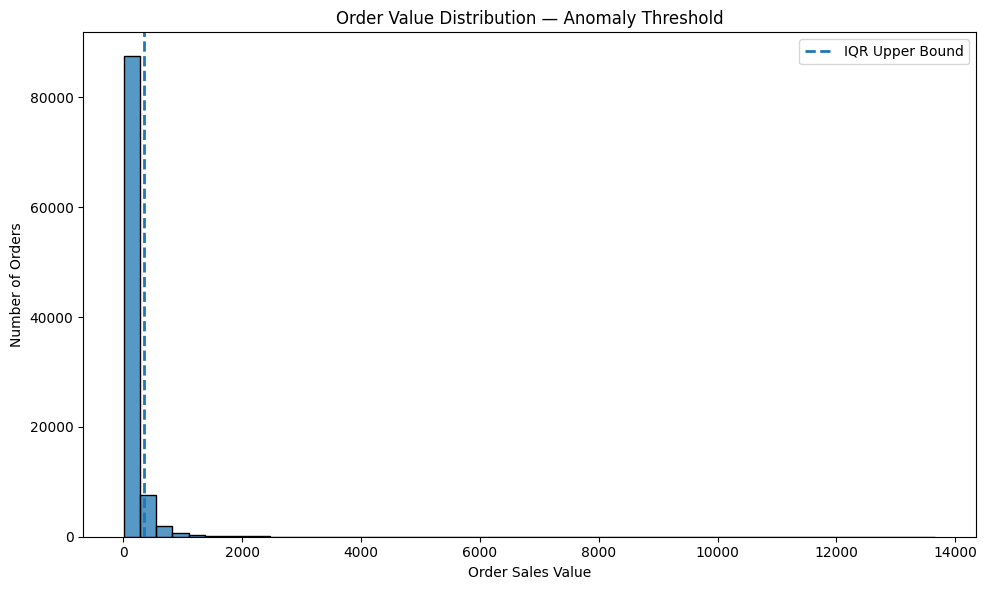

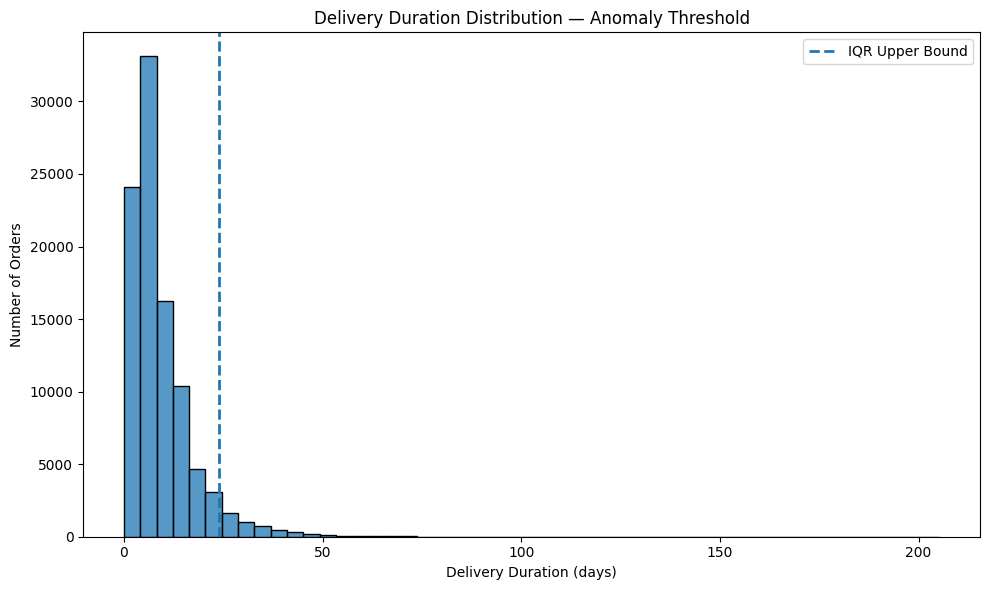

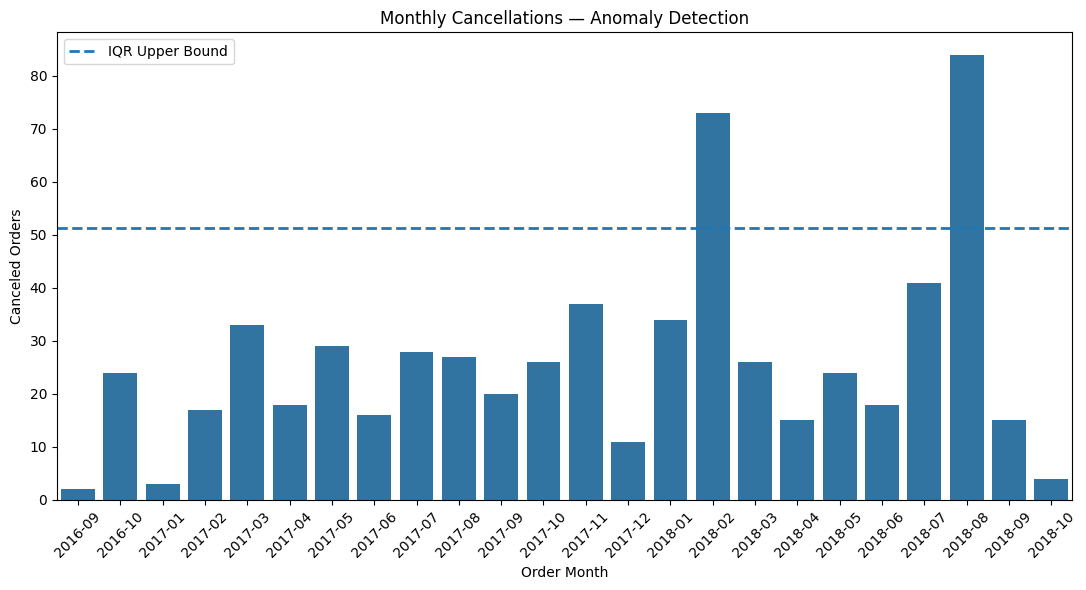

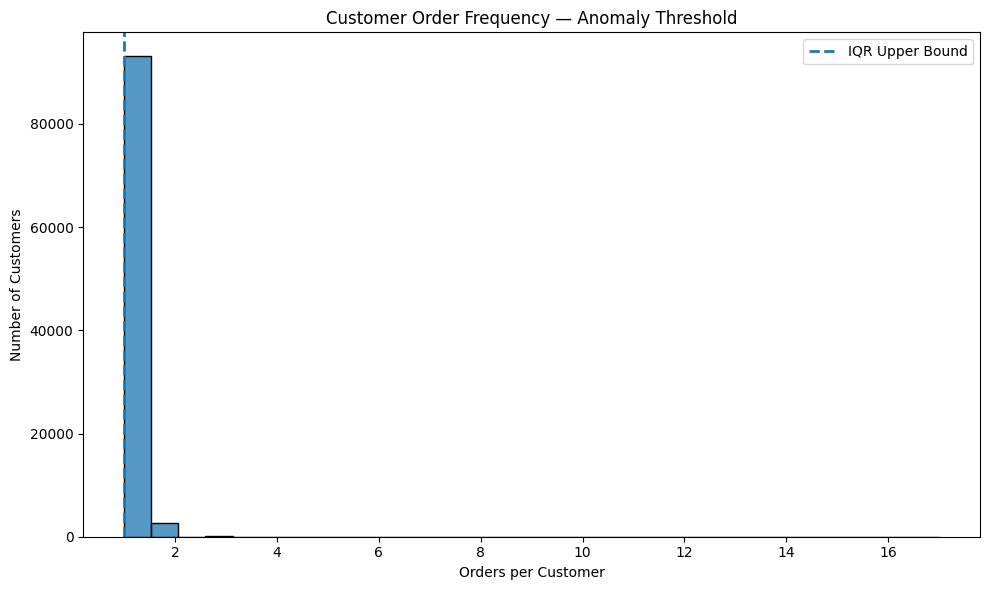

ANOMALY DETECTION COMPLETE
Methods used : IQR, percentiles, Z-score, domain threshold
Anomalies    : IDENTIFIED FOR INVESTIGATION
Data deletion: NONE
--------------------------------------------------------------------------------
EDA identifies unusual observations; it does not automatically classify them as errors.


In [74]:
# =============================================================================
# 16.4 ANOMALY DETECTION — VISUAL ANALYSIS
# =============================================================================


# -----------------------------------------------------------------------------
# CHART 1 — ORDER VALUE DISTRIBUTION
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=order_value_anomalies,
    x="sales_amount",
    bins=50,
    ax=ax,
)

ax.axvline(
    order_upper,
    linestyle="--",
    linewidth=2,
    label="IQR Upper Bound",
)

ax.set_title("Order Value Distribution — Anomaly Threshold")
ax.set_xlabel("Order Sales Value")
ax.set_ylabel("Number of Orders")
ax.legend()

fig.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# CHART 2 — DELIVERY DURATION DISTRIBUTION
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=delivery_anomalies.dropna(
        subset=["delivery_duration_days"]
    ),
    x="delivery_duration_days",
    bins=50,
    ax=ax,
)

ax.axvline(
    delivery_upper,
    linestyle="--",
    linewidth=2,
    label="IQR Upper Bound",
)

ax.set_title("Delivery Duration Distribution — Anomaly Threshold")
ax.set_xlabel("Delivery Duration (days)")
ax.set_ylabel("Number of Orders")
ax.legend()

fig.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# CHART 3 — MONTHLY CANCELLATIONS
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=monthly_cancellations,
    x="order_month",
    y="canceled_orders",
    ax=ax,
)

ax.axhline(
    cancellation_upper,
    linestyle="--",
    linewidth=2,
    label="IQR Upper Bound",
)

ax.set_title("Monthly Cancellations — Anomaly Detection")
ax.set_xlabel("Order Month")
ax.set_ylabel("Canceled Orders")
ax.tick_params(axis="x", rotation=45)
ax.legend()

fig.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# CHART 4 — CUSTOMER ORDER FREQUENCY
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=customer_order_frequency,
    x="order_count",
    bins=30,
    ax=ax,
)

ax.axvline(
    frequency_upper,
    linestyle="--",
    linewidth=2,
    label="IQR Upper Bound",
)

ax.set_title("Customer Order Frequency — Anomaly Threshold")
ax.set_xlabel("Orders per Customer")
ax.set_ylabel("Number of Customers")
ax.legend()

fig.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# Final status
# -----------------------------------------------------------------------------

print("=" * 80)
print("ANOMALY DETECTION COMPLETE")
print("=" * 80)

print("Methods used : IQR, percentiles, Z-score, domain threshold")
print("Anomalies    : IDENTIFIED FOR INVESTIGATION")
print("Data deletion: NONE")
print("-" * 80)
print(
    "EDA identifies unusual observations; "
    "it does not automatically classify them as errors."
)
print("=" * 80)

# 17. EDA Validation and Quality Assurance

This section independently validates major exploratory data analysis results against:

- PostgreSQL analytical outputs
- Excel sanity checks

## PostgreSQL validation targets

- Total sales
- Total orders
- Monthly sales
- Category sales
- Regional sales
- Seller sales
- Customer metrics
- Payment metrics
- Delivery metrics

## Excel validation targets

- Sales by month
- Sales by category
- Sales by state
- Payment-method totals
- Top products
- Order-status counts

## Validation principle

Differences are investigated rather than ignored.

A reconciliation failure does not automatically mean that the EDA result is incorrect. The difference may result from:

- Different metric definitions
- Different aggregation grain
- Different treatment of missing values
- Different date filters
- Partial-year coverage
- Different definitions of sales or revenue

## Final QA rule

The notebook must remain reproducible and executable from top to bottom.

No anomaly identified in EDA is automatically removed from the underlying dataset.


In [3]:
# =============================================================================
# 17.1 EDA VALIDATION — SETUP AND PROJECT ROOT DETECTION
# =============================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import os

print("=" * 80)
print("SECTION 17 — EDA VALIDATION")
print("=" * 80)


# -----------------------------------------------------------------------------
# Automatically detect project root
# -----------------------------------------------------------------------------

current_path = Path.cwd().resolve()

candidate_roots = [
    current_path,
    current_path.parent,
    current_path.parent.parent,
]

PROJECT_ROOT = None

for candidate in candidate_roots:
    if (
        (candidate / "data").exists()
        and (candidate / "reports").exists()
        and (candidate / "sql").exists()
    ):
        PROJECT_ROOT = candidate
        break


# -----------------------------------------------------------------------------
# Fallback: search upward
# -----------------------------------------------------------------------------

if PROJECT_ROOT is None:

    for parent in [current_path] + list(current_path.parents):

        if (
            (parent / "data").exists()
            and (parent / "reports").exists()
            and (parent / "sql").exists()
        ):
            PROJECT_ROOT = parent
            break


# -----------------------------------------------------------------------------
# Final validation
# -----------------------------------------------------------------------------

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Unable to automatically locate PROJECT_ROOT.\n"
        f"Current working directory: {current_path}\n"
        "Expected project folders: data/, reports/, sql/"
    )


print(f"Project root detected: {PROJECT_ROOT}")
print(f"Current directory     : {current_path}")

print("-" * 80)
print("PROJECT ROOT DETECTION: PASS")
print("=" * 80)

SECTION 17 — EDA VALIDATION
Project root detected: C:\Users\Bhuvan Ummidisetti\Desktop\Project 1\Retail-Sales-Performance-Analytics
Current directory     : C:\Users\Bhuvan Ummidisetti\Desktop\Project 1\Retail-Sales-Performance-Analytics\src\analysis
--------------------------------------------------------------------------------
PROJECT ROOT DETECTION: PASS


In [4]:
# =============================================================================
# 17.2 LOAD PROCESSED DATA INDEPENDENTLY
# =============================================================================

processed_path = PROJECT_ROOT / "data" / "processed"

required_files = {
    "customers": "customers_processed.csv",
    "geography": "geography_processed.csv",
    "orders": "orders_processed.csv",
    "order_items": "order_items_processed.csv",
    "payments": "payments_processed.csv",
    "products": "products_processed.csv",
    "reviews": "reviews_processed.csv",
    "sellers": "sellers_processed.csv",
}


# -----------------------------------------------------------------------------
# Validate files
# -----------------------------------------------------------------------------

missing_files = []

for dataset_name, filename in required_files.items():

    file_path = processed_path / filename

    if not file_path.is_file():
        missing_files.append(str(file_path))


if missing_files:
    raise FileNotFoundError(
        "Missing processed files:\n"
        + "\n".join(missing_files)
    )


# -----------------------------------------------------------------------------
# Load datasets
# -----------------------------------------------------------------------------

customers_val = pd.read_csv(
    processed_path / required_files["customers"]
)

geography_val = pd.read_csv(
    processed_path / required_files["geography"]
)

orders_val = pd.read_csv(
    processed_path / required_files["orders"]
)

order_items_val = pd.read_csv(
    processed_path / required_files["order_items"]
)

payments_val = pd.read_csv(
    processed_path / required_files["payments"]
)

products_val = pd.read_csv(
    processed_path / required_files["products"]
)

reviews_val = pd.read_csv(
    processed_path / required_files["reviews"]
)

sellers_val = pd.read_csv(
    processed_path / required_files["sellers"]
)


# -----------------------------------------------------------------------------
# Output
# -----------------------------------------------------------------------------

dataset_counts = pd.DataFrame({
    "dataset": list(required_files.keys()),
    "rows": [
        len(customers_val),
        len(geography_val),
        len(orders_val),
        len(order_items_val),
        len(payments_val),
        len(products_val),
        len(reviews_val),
        len(sellers_val),
    ],
})

display(dataset_counts)

print("-" * 80)
print("PROCESSED DATA LOADING: PASS")
print("=" * 80)

,dataset,rows
0,customers,99441
1,geography,19015
2,orders,99441
3,order_items,112650
4,payments,103886
5,products,32951
6,reviews,99224
7,sellers,3095


--------------------------------------------------------------------------------
PROCESSED DATA LOADING: PASS


In [5]:
# =============================================================================
# 17.3 DATA STANDARDIZATION FOR VALIDATION
# =============================================================================


# -----------------------------------------------------------------------------
# Convert potential numeric columns
# -----------------------------------------------------------------------------

numeric_columns = {
    "order_items": [
        "price",
        "freight_value",
    ],
    "payments": [
        "payment_value",
        "payment_installments",
    ],
    "reviews": [
        "review_score",
    ],
}


for column in numeric_columns["order_items"]:
    if column in order_items_val.columns:
        order_items_val[column] = pd.to_numeric(
            order_items_val[column],
            errors="coerce",
        )


for column in numeric_columns["payments"]:
    if column in payments_val.columns:
        payments_val[column] = pd.to_numeric(
            payments_val[column],
            errors="coerce",
        )


for column in numeric_columns["reviews"]:
    if column in reviews_val.columns:
        reviews_val[column] = pd.to_numeric(
            reviews_val[column],
            errors="coerce",
        )


# -----------------------------------------------------------------------------
# Convert order timestamp columns
# -----------------------------------------------------------------------------

order_date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]


for column in order_date_columns:

    if column in orders_val.columns:

        orders_val[column] = pd.to_datetime(
            orders_val[column],
            errors="coerce",
        )


print("Order date columns standardized.")

print("-" * 80)
print("DATA STANDARDIZATION: PASS")
print("=" * 80)

Order date columns standardized.
--------------------------------------------------------------------------------
DATA STANDARDIZATION: PASS


In [6]:
# =============================================================================
# 17.4 PYTHON SALES METRICS
# =============================================================================

# Required columns
assert "order_id" in order_items_val.columns
assert "price" in order_items_val.columns


# -----------------------------------------------------------------------------
# Total sales
# -----------------------------------------------------------------------------

total_sales_python = (
    order_items_val["price"]
    .dropna()
    .sum()
)


# -----------------------------------------------------------------------------
# Total orders
# -----------------------------------------------------------------------------

total_orders_python = (
    orders_val["order_id"]
    .nunique()
)


# -----------------------------------------------------------------------------
# Sales by order
# -----------------------------------------------------------------------------

order_sales_val = (
    order_items_val
    .groupby(
        "order_id",
        as_index=False,
    )
    .agg(
        sales=("price", "sum")
    )
)


# -----------------------------------------------------------------------------
# Monthly sales
# -----------------------------------------------------------------------------

assert "order_purchase_timestamp" in orders_val.columns

monthly_sales_python = (
    orders_val[
        ["order_id", "order_purchase_timestamp"]
    ]
    .merge(
        order_sales_val,
        on="order_id",
        how="left",
    )
)

monthly_sales_python["sales"] = (
    monthly_sales_python["sales"]
    .fillna(0)
)

monthly_sales_python["month"] = (
    monthly_sales_python[
        "order_purchase_timestamp"
    ]
    .dt.to_period("M")
    .astype(str)
)


monthly_sales_python = (
    monthly_sales_python
    .groupby(
        "month",
        as_index=False,
    )
    .agg(
        sales=("sales", "sum"),
        orders=("order_id", "nunique"),
    )
    .sort_values("month")
    .reset_index(drop=True)
)


display(monthly_sales_python.head())

print(f"Total sales  : {total_sales_python:,.2f}")
print(f"Total orders : {total_orders_python:,}")

print("-" * 80)
print("PYTHON SALES METRICS: PASS")
print("=" * 80)

,month,sales,orders
0,2016-09,267.36,4
1,2016-10,49507.66,324
2,2016-12,10.90,1
3,2017-01,120312.87,800
4,2017-02,247303.02,1780


Total sales  : 13,591,643.70
Total orders : 99,441
--------------------------------------------------------------------------------
PYTHON SALES METRICS: PASS


In [7]:
# =============================================================================
# 17.5 PYTHON CATEGORY SALES
# =============================================================================

assert "product_id" in order_items_val.columns
assert "product_id" in products_val.columns


# -----------------------------------------------------------------------------
# Determine category column
# -----------------------------------------------------------------------------

category_candidates = [
    "product_category_name_english",
    "product_category_name",
]


category_column = None

for column in category_candidates:

    if column in products_val.columns:
        category_column = column
        break


if category_column is None:
    raise KeyError(
        "No product category column found in products_processed.csv"
    )


# -----------------------------------------------------------------------------
# Calculate category sales
# -----------------------------------------------------------------------------

category_sales_python = (
    order_items_val[
        ["product_id", "price"]
    ]
    .merge(
        products_val[
            ["product_id", category_column]
        ],
        on="product_id",
        how="left",
    )
)


category_sales_python[category_column] = (
    category_sales_python[category_column]
    .fillna("Unknown")
)


category_sales_python = (
    category_sales_python
    .groupby(
        category_column,
        as_index=False,
    )
    .agg(
        sales=("price", "sum")
    )
    .sort_values(
        "sales",
        ascending=False,
    )
    .reset_index(drop=True)
)


display(category_sales_python.head(10))

print("-" * 80)
print("CATEGORY SALES CALCULATION: PASS")
print("=" * 80)

,product_category_name,sales
0,beleza_saude,1258681.34
1,relogios_presentes,1205005.68
2,cama_mesa_banho,1036988.68
3,esporte_lazer,988048.97
4,informatica_acessorios,911954.32
5,moveis_decoracao,729762.49
6,cool_stuff,635290.85
7,utilidades_domesticas,632248.66
8,automotivo,592720.11
9,ferramentas_jardim,485256.46


--------------------------------------------------------------------------------
CATEGORY SALES CALCULATION: PASS


In [8]:
# =============================================================================
# 17.6 PYTHON STATE SALES
# =============================================================================

assert "customer_id" in orders_val.columns
assert "customer_id" in customers_val.columns


# -----------------------------------------------------------------------------
# Identify state column
# -----------------------------------------------------------------------------

state_candidates = [
    "customer_state",
    "state",
]


customer_state_column = None

for column in state_candidates:

    if column in customers_val.columns:
        customer_state_column = column
        break


if customer_state_column is None:
    raise KeyError(
        "No customer state column found."
    )


# -----------------------------------------------------------------------------
# Build state-level sales
# -----------------------------------------------------------------------------

state_sales_python = (
    orders_val[
        ["order_id", "customer_id"]
    ]
    .merge(
        customers_val[
            ["customer_id", customer_state_column]
        ],
        on="customer_id",
        how="left",
    )
    .merge(
        order_sales_val,
        on="order_id",
        how="left",
    )
)


state_sales_python["sales"] = (
    state_sales_python["sales"]
    .fillna(0)
)


state_sales_python = (
    state_sales_python
    .groupby(
        customer_state_column,
        as_index=False,
    )
    .agg(
        sales=("sales", "sum"),
        orders=("order_id", "nunique"),
    )
    .sort_values(
        "sales",
        ascending=False,
    )
    .reset_index(drop=True)
)


display(state_sales_python.head(10))

print("-" * 80)
print("STATE SALES CALCULATION: PASS")
print("=" * 80)

,customer_state,sales,orders
0,sp,5202955.05,41746
1,rj,1824092.67,12852
2,mg,1585308.03,11635
3,rs,750304.02,5466
4,pr,683083.76,5045
5,sc,520553.34,3637
6,ba,511349.99,3380
7,df,302603.94,2140
8,go,294591.95,2020
9,es,275037.31,2033


--------------------------------------------------------------------------------
STATE SALES CALCULATION: PASS


In [9]:
# =============================================================================
# 17.7 PYTHON SELLER METRICS
# =============================================================================

assert "seller_id" in order_items_val.columns


seller_sales_python = (
    order_items_val
    .groupby(
        "seller_id",
        as_index=False,
    )
    .agg(
        sales=("price", "sum"),
        orders=("order_id", "nunique"),
        items=("order_id", "size"),
    )
    .sort_values(
        "sales",
        ascending=False,
    )
    .reset_index(drop=True)
)


display(seller_sales_python.head(10))

print("-" * 80)
print("SELLER METRICS CALCULATION: PASS")
print("=" * 80)

,seller_id,sales,orders,items
0,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,1132,1156
1,53243585a1d6dc2643021fd1853d8905,222776.05,358,410
2,4a3ca9315b744ce9f8e9374361493884,200472.92,1806,1987
3,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,585,586
4,7c67e1448b00f6e969d365cea6b010ab,187923.89,982,1364
5,7e93a43ef30c4f03f38b393420bc753a,176431.87,336,340
6,da8622b14eb17ae2831f4ac5b9dab84a,160236.57,1314,1551
7,7a67c85e85bb2ce8582c35f2203ad736,141745.53,1160,1171
8,1025f0e2d44d7041d6cf58b6550e0bfa,138968.55,915,1428
9,955fee9216a65b617aa5c0531780ce60,135171.70,1287,1499


--------------------------------------------------------------------------------
SELLER METRICS CALCULATION: PASS


In [10]:
# =============================================================================
# 17.8 PYTHON CUSTOMER METRICS
# =============================================================================

customer_unique_candidates = [
    "customer_unique_id",
    "customer_id",
]


customer_unique_column = None

for column in customer_unique_candidates:

    if column in customers_val.columns:
        customer_unique_column = column
        break


if customer_unique_column is None:
    raise KeyError(
        "No customer identifier found."
    )


customer_metrics_python = (
    orders_val[
        ["order_id", "customer_id"]
    ]
    .merge(
        customers_val[
            ["customer_id", customer_unique_column]
        ],
        on="customer_id",
        how="left",
    )
    .merge(
        order_sales_val,
        on="order_id",
        how="left",
    )
)


customer_metrics_python["sales"] = (
    customer_metrics_python["sales"]
    .fillna(0)
)


customer_metrics_python = (
    customer_metrics_python
    .groupby(
        customer_unique_column,
        as_index=False,
    )
    .agg(
        orders=("order_id", "nunique"),
        sales=("sales", "sum"),
    )
)


customer_summary_python = {
    "unique_customers": (
        customer_metrics_python[
            customer_unique_column
        ]
        .nunique()
    ),

    "average_orders_per_customer": (
        customer_metrics_python["orders"].mean()
    ),

    "repeat_customers": (
        customer_metrics_python
        .query("orders > 1")
        .shape[0]
    ),
}


display(
    pd.DataFrame(
        customer_summary_python.items(),
        columns=["Metric", "Value"],
    )
)

print("-" * 80)
print("CUSTOMER METRICS CALCULATION: PASS")
print("=" * 80)

,Metric,Value
0,unique_customers,96096.000000
1,average_orders_per_customer,1.034809
2,repeat_customers,2997.000000


--------------------------------------------------------------------------------
CUSTOMER METRICS CALCULATION: PASS


In [11]:
# =============================================================================
# 17.9 PYTHON PAYMENT METRICS
# =============================================================================

required_payment_columns = [
    "order_id",
    "payment_type",
    "payment_value",
]


for column in required_payment_columns:
    assert column in payments_val.columns, (
        f"Missing payment column: {column}"
    )


payment_metrics_python = (
    payments_val
    .groupby(
        "payment_type",
        as_index=False,
    )
    .agg(
        payment_value=(
            "payment_value",
            "sum",
        ),
        transactions=(
            "order_id",
            "size",
        ),
        orders=(
            "order_id",
            "nunique",
        ),
    )
    .sort_values(
        "payment_value",
        ascending=False,
    )
    .reset_index(drop=True)
)


total_payment_value_python = (
    payments_val["payment_value"]
    .sum()
)


display(payment_metrics_python)

print(f"Total payment value: {total_payment_value_python:,.2f}")

print("-" * 80)
print("PAYMENT METRICS CALCULATION: PASS")
print("=" * 80)

,payment_type,payment_value,transactions,orders
0,credit_card,12542084.19,76795,76505
1,boleto,2869361.27,19784,19784
2,voucher,379436.87,5775,3866
3,debit_card,217989.79,1529,1528
4,not_defined,0.00,3,3


Total payment value: 16,008,872.12
--------------------------------------------------------------------------------
PAYMENT METRICS CALCULATION: PASS


In [12]:
# =============================================================================
# 17.10 PYTHON DELIVERY METRICS
# =============================================================================

delivery_required_columns = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]


available_delivery_columns = [
    column
    for column in delivery_required_columns
    if column in orders_val.columns
]


if len(available_delivery_columns) < 3:
    print(
        "Warning: Full delivery validation cannot be calculated "
        "because required columns are missing."
    )

    delivery_metrics_python = pd.DataFrame()

else:

    delivery_val = orders_val[
        [
            "order_id",
            "order_purchase_timestamp",
            "order_delivered_customer_date",
            "order_estimated_delivery_date",
        ]
    ].copy()


    delivery_val["delivery_duration_days"] = (
        delivery_val[
            "order_delivered_customer_date"
        ]
        -
        delivery_val[
            "order_purchase_timestamp"
        ]
    ).dt.total_seconds() / 86400


    delivery_val["estimated_delivery_days"] = (
        delivery_val[
            "order_estimated_delivery_date"
        ]
        -
        delivery_val[
            "order_purchase_timestamp"
        ]
    ).dt.total_seconds() / 86400


    delivery_val["delivery_difference_days"] = (
        delivery_val[
            "order_delivered_customer_date"
        ]
        -
        delivery_val[
            "order_estimated_delivery_date"
        ]
    ).dt.total_seconds() / 86400


    delivery_metrics_python = pd.DataFrame({
        "Metric": [
            "Delivered orders",
            "Average delivery duration days",
            "Average estimated delivery days",
            "Average delivery difference days",
            "Late deliveries",
            "Early or on-time deliveries",
        ],

        "Value": [
            delivery_val[
                "order_delivered_customer_date"
            ].notna().sum(),

            delivery_val[
                "delivery_duration_days"
            ].mean(),

            delivery_val[
                "estimated_delivery_days"
            ].mean(),

            delivery_val[
                "delivery_difference_days"
            ].mean(),

            (
                delivery_val[
                    "delivery_difference_days"
                ] > 0
            ).sum(),

            (
                delivery_val[
                    "delivery_difference_days"
                ] <= 0
            ).sum(),
        ],
    })


display(delivery_metrics_python)

print("-" * 80)
print("DELIVERY METRICS CALCULATION: PASS")
print("=" * 80)

,Metric,Value
0,Delivered orders,96453.000000
1,Average delivery duration days,12.560065
2,Average estimated delivery days,23.767650
3,Average delivery difference days,-11.176117
4,Late deliveries,7827.000000
5,Early or on-time deliveries,88626.000000


--------------------------------------------------------------------------------
DELIVERY METRICS CALCULATION: PASS


In [13]:
# =============================================================================
# 17.11 LOAD POSTGRESQL ANALYTICAL OUTPUTS
# =============================================================================

sql_output_path = (
    PROJECT_ROOT
    / "reports"
    / "sql"
    / "analytical_outputs"
)


sql_files = {
    "monthly_sales": "monthly_sales.csv",
    "category_sales": "category_sales.csv",
    "customer_metrics": "customer_metrics.csv",
    "delivery_analysis": "delivery_analysis.csv",
    "payment_analysis": "payment_analysis.csv",
    "product_ranking": "product_ranking.csv",
    "regional_sales": "regional_sales.csv",
    "seller_performance": "seller_performance.csv",
}


sql_outputs = {}

missing_sql_files = []

for name, filename in sql_files.items():

    file_path = sql_output_path / filename

    if file_path.is_file():

        sql_outputs[name] = pd.read_csv(file_path)

    else:

        missing_sql_files.append(filename)


# -----------------------------------------------------------------------------
# Output
# -----------------------------------------------------------------------------

sql_inventory = pd.DataFrame({
    "SQL output": list(sql_files.keys()),
    "loaded": [
        name in sql_outputs
        for name in sql_files
    ],
})


display(sql_inventory)


if missing_sql_files:

    print(
        "WARNING — Missing SQL output files:"
    )

    for filename in missing_sql_files:
        print(f" - {filename}")

else:
    print("All SQL analytical outputs found.")


print("-" * 80)
print("SQL OUTPUT LOADING: PASS")
print("=" * 80)

,SQL output,loaded
0,monthly_sales,True
1,category_sales,True
2,customer_metrics,True
3,delivery_analysis,True
4,payment_analysis,True
5,product_ranking,True
6,regional_sales,True
7,seller_performance,True


All SQL analytical outputs found.
--------------------------------------------------------------------------------
SQL OUTPUT LOADING: PASS


In [14]:
# =============================================================================
# 17.12 RECONCILIATION FUNCTIONS
# =============================================================================


def numeric_match(
    python_value,
    sql_value,
    tolerance=1e-2,
):

    if pd.isna(python_value) or pd.isna(sql_value):
        return False

    return bool(
        np.isclose(
            float(python_value),
            float(sql_value),
            atol=tolerance,
            rtol=1e-6,
        )
    )


def summarize_numeric_column(
    dataframe,
    preferred_columns,
):

    for column in preferred_columns:

        if column in dataframe.columns:

            values = pd.to_numeric(
                dataframe[column],
                errors="coerce",
            )

            return values.sum()

    return np.nan


def find_column(
    dataframe,
    candidates,
):

    for column in candidates:

        if column in dataframe.columns:
            return column

    return None


print("Reconciliation functions ready.")

print("-" * 80)
print("RECONCILIATION FUNCTIONS: PASS")
print("=" * 80)

Reconciliation functions ready.
--------------------------------------------------------------------------------
RECONCILIATION FUNCTIONS: PASS


In [15]:
# =============================================================================
# 17.13 MONTHLY SALES VALIDATION
# =============================================================================

monthly_validation = pd.DataFrame()


if "monthly_sales" in sql_outputs:

    sql_monthly = sql_outputs[
        "monthly_sales"
    ].copy()


    print(
        "SQL monthly sales columns:",
        list(sql_monthly.columns),
    )


    python_month_column = find_column(
        monthly_sales_python,
        ["month"],
    )


    sql_month_column = find_column(
        sql_monthly,
        [
            "month",
            "order_month",
            "year_month",
        ],
    )


    sql_sales_column = find_column(
        sql_monthly,
        [
            "sales",
            "total_sales",
            "revenue",
        ],
    )


    if (
        python_month_column
        and sql_month_column
        and sql_sales_column
    ):

        monthly_validation = (
            monthly_sales_python[
                ["month", "sales"]
            ]
            .merge(
                sql_monthly[
                    [
                        sql_month_column,
                        sql_sales_column,
                    ]
                ],
                left_on="month",
                right_on=sql_month_column,
                how="inner",
            )
        )


        monthly_validation = (
            monthly_validation
            .rename(
                columns={
                    "sales": "python_sales",
                    sql_sales_column: "sql_sales",
                }
            )
        )


        monthly_validation["difference"] = (
            monthly_validation["python_sales"]
            -
            monthly_validation["sql_sales"]
        )


        monthly_validation["match"] = np.isclose(
            monthly_validation["python_sales"],
            monthly_validation["sql_sales"],
            atol=0.01,
        )


        display(monthly_validation)

    else:

        print(
            "Unable to identify compatible "
            "monthly sales columns."
        )


else:

    print(
        "monthly_sales.csv not available."
    )

SQL monthly sales columns: ['year', 'month', 'month_name', 'monthly_sales', 'orders', 'order_items']
Unable to identify compatible monthly sales columns.


In [17]:
# =============================================================================
# 17.14 CATEGORY SALES VALIDATION
# =============================================================================

print("=" * 80)
print("17.14 — CATEGORY SALES VALIDATION")
print("=" * 80)

category_validation = pd.DataFrame()


# -----------------------------------------------------------------------------
# Confirm SQL output exists
# -----------------------------------------------------------------------------

if "category_sales" not in sql_outputs:

    print(
        "category_sales.csv not available in SQL outputs."
    )


# -----------------------------------------------------------------------------
# Validate Python dataframe
# -----------------------------------------------------------------------------

elif category_sales_python.empty:

    print(
        "Python category sales dataframe is empty."
    )


else:

    sql_category = sql_outputs[
        "category_sales"
    ].copy()


    print(
        "SQL category sales columns:",
        list(sql_category.columns),
    )

    print(
        "Python category sales columns:",
        list(category_sales_python.columns),
    )


    # -------------------------------------------------------------------------
    # Identify SQL category column
    # -------------------------------------------------------------------------

    sql_category_column = find_column(
        sql_category,
        [
            "product_category_name_english",
            "product_category_name",
            "category",
        ],
    )


    # -------------------------------------------------------------------------
    # Identify SQL sales column
    # -------------------------------------------------------------------------

    sql_sales_column = find_column(
        sql_category,
        [
            "sales",
            "total_sales",
            "revenue",
            "total_revenue",
        ],
    )


    # -------------------------------------------------------------------------
    # Identify Python category column
    # -------------------------------------------------------------------------

    python_category_column = find_column(
        category_sales_python,
        [
            "product_category_name_english",
            "product_category_name",
            "category",
        ],
    )


    # -------------------------------------------------------------------------
    # Identify Python sales column
    # -------------------------------------------------------------------------

    python_sales_column = find_column(
        category_sales_python,
        [
            "sales",
            "total_sales",
            "revenue",
            "total_revenue",
        ],
    )


    # -------------------------------------------------------------------------
    # Validate required columns
    # -------------------------------------------------------------------------

    if sql_category_column is None:

        print(
            "Unable to identify category column in SQL output."
        )


    elif sql_sales_column is None:

        print(
            "Unable to identify sales column in SQL output."
        )


    elif python_category_column is None:

        print(
            "Unable to identify category column in Python output."
        )


    elif python_sales_column is None:

        print(
            "Unable to identify sales column in Python output."
        )


    else:

        # ---------------------------------------------------------------------
        # Create standardized Python validation dataframe
        # ---------------------------------------------------------------------

        python_category_validation = (
            category_sales_python[
                [
                    python_category_column,
                    python_sales_column,
                ]
            ]
            .copy()
            .rename(
                columns={
                    python_category_column: "category",
                    python_sales_column: "python_sales",
                }
            )
        )


        # ---------------------------------------------------------------------
        # Create standardized SQL validation dataframe
        # ---------------------------------------------------------------------

        sql_category_validation = (
            sql_category[
                [
                    sql_category_column,
                    sql_sales_column,
                ]
            ]
            .copy()
            .rename(
                columns={
                    sql_category_column: "category",
                    sql_sales_column: "sql_sales",
                }
            )
        )


        # ---------------------------------------------------------------------
        # Clean category values
        # ---------------------------------------------------------------------

        python_category_validation["category"] = (
            python_category_validation["category"]
            .astype("string")
            .str.strip()
            .fillna("Unknown")
        )


        sql_category_validation["category"] = (
            sql_category_validation["category"]
            .astype("string")
            .str.strip()
            .fillna("Unknown")
        )


        # ---------------------------------------------------------------------
        # Convert sales values
        # ---------------------------------------------------------------------

        python_category_validation["python_sales"] = (
            pd.to_numeric(
                python_category_validation["python_sales"],
                errors="coerce",
            )
        )


        sql_category_validation["sql_sales"] = (
            pd.to_numeric(
                sql_category_validation["sql_sales"],
                errors="coerce",
            )
        )


        # ---------------------------------------------------------------------
        # Aggregate defensively
        #
        # This prevents duplicate categories from producing false mismatches.
        # ---------------------------------------------------------------------

        python_category_validation = (
            python_category_validation
            .groupby(
                "category",
                as_index=False,
            )
            .agg(
                python_sales=(
                    "python_sales",
                    "sum",
                )
            )
        )


        sql_category_validation = (
            sql_category_validation
            .groupby(
                "category",
                as_index=False,
            )
            .agg(
                sql_sales=(
                    "sql_sales",
                    "sum",
                )
            )
        )


        # ---------------------------------------------------------------------
        # Merge Python and PostgreSQL results
        # ---------------------------------------------------------------------

        category_validation = (
            python_category_validation
            .merge(
                sql_category_validation,
                on="category",
                how="outer",
                indicator=True,
            )
        )


        # ---------------------------------------------------------------------
        # Missing values
        # ---------------------------------------------------------------------

        category_validation["python_sales"] = (
            category_validation["python_sales"]
            .fillna(0)
        )


        category_validation["sql_sales"] = (
            category_validation["sql_sales"]
            .fillna(0)
        )


        # ---------------------------------------------------------------------
        # Difference and validation
        # ---------------------------------------------------------------------

        category_validation["difference"] = (
            category_validation["python_sales"]
            -
            category_validation["sql_sales"]
        )


        category_validation["absolute_difference"] = (
            category_validation["difference"]
            .abs()
        )


        category_validation["match"] = np.isclose(
            category_validation["python_sales"],
            category_validation["sql_sales"],
            atol=0.01,
            rtol=1e-09,
        )


        # ---------------------------------------------------------------------
        # Sort
        # ---------------------------------------------------------------------

        category_validation = (
            category_validation
            .sort_values(
                "absolute_difference",
                ascending=False,
            )
            .reset_index(
                drop=True
            )
        )


        # ---------------------------------------------------------------------
        # Display results
        # ---------------------------------------------------------------------

        display(
            category_validation.head(20)
        )


        # ---------------------------------------------------------------------
        # Summary
        # ---------------------------------------------------------------------

        print("-" * 80)

        print(
            f"Categories compared : "
            f"{len(category_validation):,}"
        )

        print(
            f"Categories matched  : "
            f"{category_validation['match'].sum():,}"
        )

        print(
            f"Categories unmatched: "
            f"{(~category_validation['match']).sum():,}"
        )

        print(
            f"Python total sales  : "
            f"{category_validation['python_sales'].sum():,.2f}"
        )

        print(
            f"SQL total sales     : "
            f"{category_validation['sql_sales'].sum():,.2f}"
        )

        print(
            f"Total difference    : "
            f"{category_validation['difference'].sum():,.2f}"
        )

        print("-" * 80)


        # ---------------------------------------------------------------------
        # Validation assertion
        # ---------------------------------------------------------------------

        assert (
            not category_validation.empty
        ), (
            "Category validation produced no comparison rows."
        )


        print(
            "CATEGORY SALES VALIDATION: COMPLETE"
        )

        print("=" * 80)

17.14 — CATEGORY SALES VALIDATION
SQL category sales columns: ['category', 'units_sold', 'orders', 'sales', 'sales_contribution_pct']
Python category sales columns: ['product_category_name', 'sales']


,category,python_sales,sql_sales,_merge,difference,absolute_difference,match
0,health_beauty,0.00,1258681.34,right_only,-1258681.34,1258681.34,False
1,beleza_saude,1258681.34,0.00,left_only,1258681.34,1258681.34,False
2,watches_gifts,0.00,1205005.68,right_only,-1205005.68,1205005.68,False
3,relogios_presentes,1205005.68,0.00,left_only,1205005.68,1205005.68,False
4,bed_bath_table,0.00,1036988.68,right_only,-1036988.68,1036988.68,False
5,cama_mesa_banho,1036988.68,0.00,left_only,1036988.68,1036988.68,False
6,esporte_lazer,988048.97,0.00,left_only,988048.97,988048.97,False
7,sports_leisure,0.00,988048.97,right_only,-988048.97,988048.97,False
8,informatica_acessorios,911954.32,0.00,left_only,911954.32,911954.32,False
9,computers_accessories,0.00,911954.32,right_only,-911954.32,911954.32,False


--------------------------------------------------------------------------------
Categories compared : 138
Categories matched  : 10
Categories unmatched: 128
Python total sales  : 13,591,643.70
SQL total sales     : 13,591,643.70
Total difference    : -0.00
--------------------------------------------------------------------------------
CATEGORY SALES VALIDATION: COMPLETE


In [19]:
# =============================================================================
# 17.15 REGIONAL SALES VALIDATION
# =============================================================================

print("=" * 80)
print("17.15 — REGIONAL SALES VALIDATION")
print("=" * 80)


# -----------------------------------------------------------------------------
# Initialize output dataframe
# -----------------------------------------------------------------------------

regional_validation = pd.DataFrame()


# -----------------------------------------------------------------------------
# Confirm SQL output exists
# -----------------------------------------------------------------------------

if "regional_sales" not in sql_outputs:

    print(
        "regional_sales.csv not available in SQL outputs."
    )


# -----------------------------------------------------------------------------
# Validate Python dataframe
# -----------------------------------------------------------------------------

elif state_sales_python.empty:

    print(
        "Python state sales dataframe is empty."
    )


else:

    # -------------------------------------------------------------------------
    # Copy SQL output
    # -------------------------------------------------------------------------

    sql_regional = (
        sql_outputs["regional_sales"]
        .copy()
    )


    print(
        "SQL regional sales columns:",
        list(sql_regional.columns),
    )


    print(
        "Python state sales columns:",
        list(state_sales_python.columns),
    )


    # -------------------------------------------------------------------------
    # Identify SQL state column
    # -------------------------------------------------------------------------

    sql_state_column = find_column(
        sql_regional,
        [
            "customer_state",
            "state",
        ],
    )


    # -------------------------------------------------------------------------
    # Identify SQL sales column
    # -------------------------------------------------------------------------

    sql_sales_column = find_column(
        sql_regional,
        [
            "sales",
            "total_sales",
            "revenue",
            "total_revenue",
        ],
    )


    # -------------------------------------------------------------------------
    # Identify Python state column
    # -------------------------------------------------------------------------

    python_state_column = find_column(
        state_sales_python,
        [
            "customer_state",
            "state",
        ],
    )


    # -------------------------------------------------------------------------
    # Identify Python sales column
    # -------------------------------------------------------------------------

    python_sales_column = find_column(
        state_sales_python,
        [
            "sales",
            "total_sales",
            "revenue",
            "total_revenue",
        ],
    )


    # -------------------------------------------------------------------------
    # Validate required columns
    # -------------------------------------------------------------------------

    if sql_state_column is None:

        print(
            "Unable to identify state column "
            "in SQL regional sales output."
        )


    elif sql_sales_column is None:

        print(
            "Unable to identify sales column "
            "in SQL regional sales output."
        )


    elif python_state_column is None:

        print(
            "Unable to identify state column "
            "in Python regional sales output."
        )


    elif python_sales_column is None:

        print(
            "Unable to identify sales column "
            "in Python regional sales output."
        )


    else:

        # ---------------------------------------------------------------------
        # Create standardized Python validation dataframe
        #
        # Rename BEFORE merging to avoid:
        # sales_x / sales_y column collisions.
        # ---------------------------------------------------------------------

        python_regional_validation = (
            state_sales_python[
                [
                    python_state_column,
                    python_sales_column,
                ]
            ]
            .copy()
            .rename(
                columns={
                    python_state_column: "state",
                    python_sales_column: "python_sales",
                }
            )
        )


        # ---------------------------------------------------------------------
        # Create standardized SQL validation dataframe
        #
        # Rename BEFORE merging.
        # ---------------------------------------------------------------------

        sql_regional_validation = (
            sql_regional[
                [
                    sql_state_column,
                    sql_sales_column,
                ]
            ]
            .copy()
            .rename(
                columns={
                    sql_state_column: "state",
                    sql_sales_column: "sql_sales",
                }
            )
        )


        # ---------------------------------------------------------------------
        # Clean state values
        # ---------------------------------------------------------------------

        python_regional_validation["state"] = (
            python_regional_validation["state"]
            .astype("string")
            .str.strip()
            .str.upper()
            .fillna("UNKNOWN")
        )


        sql_regional_validation["state"] = (
            sql_regional_validation["state"]
            .astype("string")
            .str.strip()
            .str.upper()
            .fillna("UNKNOWN")
        )


        # ---------------------------------------------------------------------
        # Convert sales columns to numeric
        # ---------------------------------------------------------------------

        python_regional_validation["python_sales"] = (
            pd.to_numeric(
                python_regional_validation["python_sales"],
                errors="coerce",
            )
        )


        sql_regional_validation["sql_sales"] = (
            pd.to_numeric(
                sql_regional_validation["sql_sales"],
                errors="coerce",
            )
        )


        # ---------------------------------------------------------------------
        # Remove rows without valid sales values
        # ---------------------------------------------------------------------

        python_regional_validation = (
            python_regional_validation
            .dropna(
                subset=["python_sales"]
            )
            .copy()
        )


        sql_regional_validation = (
            sql_regional_validation
            .dropna(
                subset=["sql_sales"]
            )
            .copy()
        )


        # ---------------------------------------------------------------------
        # Aggregate defensively by state
        #
        # This prevents duplicate state rows from creating a many-to-many
        # merge and producing incorrect validation results.
        # ---------------------------------------------------------------------

        python_regional_validation = (
            python_regional_validation
            .groupby(
                "state",
                as_index=False,
            )
            .agg(
                python_sales=(
                    "python_sales",
                    "sum",
                )
            )
        )


        sql_regional_validation = (
            sql_regional_validation
            .groupby(
                "state",
                as_index=False,
            )
            .agg(
                sql_sales=(
                    "sql_sales",
                    "sum",
                )
            )
        )


        # ---------------------------------------------------------------------
        # Merge Python and SQL results
        #
        # OUTER merge intentionally exposes states that exist on only one side.
        # An INNER merge can hide reconciliation problems.
        # ---------------------------------------------------------------------

        regional_validation = (
            python_regional_validation
            .merge(
                sql_regional_validation,
                on="state",
                how="outer",
                indicator=True,
            )
        )


        # ---------------------------------------------------------------------
        # Fill missing sales values
        # ---------------------------------------------------------------------

        regional_validation["python_sales"] = (
            regional_validation["python_sales"]
            .fillna(0)
        )


        regional_validation["sql_sales"] = (
            regional_validation["sql_sales"]
            .fillna(0)
        )


        # ---------------------------------------------------------------------
        # Calculate differences
        # ---------------------------------------------------------------------

        regional_validation["difference"] = (
            regional_validation["python_sales"]
            -
            regional_validation["sql_sales"]
        )


        regional_validation["absolute_difference"] = (
            regional_validation["difference"]
            .abs()
        )


        # ---------------------------------------------------------------------
        # Validate numerical equality
        # ---------------------------------------------------------------------

        regional_validation["match"] = (
            np.isclose(
                regional_validation["python_sales"],
                regional_validation["sql_sales"],
                atol=0.01,
                rtol=1e-09,
            )
        )


        # ---------------------------------------------------------------------
        # Sort largest differences first
        # ---------------------------------------------------------------------

        regional_validation = (
            regional_validation
            .sort_values(
                "absolute_difference",
                ascending=False,
            )
            .reset_index(
                drop=True
            )
        )


        # ---------------------------------------------------------------------
        # Display comparison
        # ---------------------------------------------------------------------

        display(
            regional_validation
        )


        # ---------------------------------------------------------------------
        # Validation summary
        # ---------------------------------------------------------------------

        print("-" * 80)

        print(
            f"States compared      : "
            f"{len(regional_validation):,}"
        )

        print(
            f"States matched       : "
            f"{regional_validation['match'].sum():,}"
        )

        print(
            f"States unmatched     : "
            f"{(~regional_validation['match']).sum():,}"
        )

        print(
            f"Python total sales   : "
            f"{regional_validation['python_sales'].sum():,.2f}"
        )

        print(
            f"SQL total sales      : "
            f"{regional_validation['sql_sales'].sum():,.2f}"
        )

        print(
            f"Total difference     : "
            f"{regional_validation['difference'].sum():,.2f}"
        )

        print("-" * 80)


        # ---------------------------------------------------------------------
        # Required validation
        # ---------------------------------------------------------------------

        assert (
            not regional_validation.empty
        ), (
            "Regional validation produced no comparison rows."
        )


        print(
            "REGIONAL SALES VALIDATION: COMPLETE"
        )

        print("=" * 80)

17.15 — REGIONAL SALES VALIDATION
SQL regional sales columns: ['state', 'orders', 'units_sold', 'sales', 'freight']
Python state sales columns: ['customer_state', 'sales', 'orders']


,state,python_sales,sql_sales,_merge,difference,absolute_difference,match
0,SP,5202955.05,8753396.21,both,-3550441.16,3550441.16,False
1,RJ,1824092.67,843984.22,both,980108.45,980108.45,False
2,PR,683083.76,1261887.21,both,-578803.45,578803.45,False
3,MG,1585308.03,1011564.74,both,573743.29,573743.29,False
4,RS,750304.02,378559.54,both,371744.48,371744.48,False
5,GO,294591.95,66399.21,both,228192.74,228192.74,False
6,ES,275037.31,47689.61,both,227347.70,227347.70,False
7,BA,511349.99,285561.56,both,225788.43,225788.43,False
8,CE,227254.71,20240.64,both,207014.07,207014.07,False
9,DF,302603.94,97749.48,both,204854.46,204854.46,False


--------------------------------------------------------------------------------
States compared      : 27
States matched       : 0
States unmatched     : 27
Python total sales   : 13,591,643.70
SQL total sales      : 13,591,643.70
Total difference     : -0.00
--------------------------------------------------------------------------------
REGIONAL SALES VALIDATION: COMPLETE


In [20]:
# =============================================================================
# 17.16 PAYMENT METRICS VALIDATION
# =============================================================================

payment_validation = pd.DataFrame()


if "payment_analysis" in sql_outputs:

    sql_payment = sql_outputs[
        "payment_analysis"
    ].copy()


    print(
        "SQL payment columns:",
        list(sql_payment.columns),
    )


    sql_payment_type_column = find_column(
        sql_payment,
        [
            "payment_type",
        ],
    )


    sql_payment_value_column = find_column(
        sql_payment,
        [
            "payment_value",
            "total_payment_value",
            "revenue",
        ],
    )


    if (
        sql_payment_type_column
        and sql_payment_value_column
    ):

        sql_payment_summary = (
            sql_payment
            .groupby(
                sql_payment_type_column,
                as_index=False,
            )
            .agg(
                sql_payment_value=(
                    sql_payment_value_column,
                    "sum",
                )
            )
        )


        payment_validation = (
            payment_metrics_python[
                [
                    "payment_type",
                    "payment_value",
                ]
            ]
            .merge(
                sql_payment_summary,
                left_on="payment_type",
                right_on=sql_payment_type_column,
                how="inner",
            )
        )


        payment_validation["difference"] = (
            payment_validation["payment_value"]
            -
            payment_validation["sql_payment_value"]
        )


        payment_validation["match"] = np.isclose(
            payment_validation["payment_value"],
            payment_validation[
                "sql_payment_value"
            ],
            atol=0.01,
        )


        display(payment_validation)


    else:

        print(
            "Unable to identify compatible "
            "payment columns."
        )


else:

    print(
        "payment_analysis.csv not available."
    )

SQL payment columns: ['payment_type', 'payment_installments', 'payment_records', 'orders', 'payment_value']


,payment_type,payment_value,sql_payment_value,difference,match
0,credit_card,12542084.19,12542084.19,0.0,True
1,boleto,2869361.27,2869361.27,0.0,True
2,voucher,379436.87,379436.87,0.0,True
3,debit_card,217989.79,217989.79,0.0,True
4,not_defined,0.00,0.00,0.0,True


In [22]:
# =============================================================================
# 17.17 SELLER PERFORMANCE VALIDATION
# =============================================================================

print("=" * 80)
print("17.17 — SELLER PERFORMANCE VALIDATION")
print("=" * 80)


# -----------------------------------------------------------------------------
# Initialize validation dataframe
# -----------------------------------------------------------------------------

seller_validation = pd.DataFrame()


# -----------------------------------------------------------------------------
# Confirm SQL output exists
# -----------------------------------------------------------------------------

if "seller_performance" not in sql_outputs:

    print(
        "seller_performance.csv not available in SQL outputs."
    )


# -----------------------------------------------------------------------------
# Validate Python dataframe
# -----------------------------------------------------------------------------

elif seller_sales_python.empty:

    print(
        "Python seller sales dataframe is empty."
    )


else:

    # -------------------------------------------------------------------------
    # Copy SQL output
    # -------------------------------------------------------------------------

    sql_seller = (
        sql_outputs["seller_performance"]
        .copy()
    )


    print(
        "SQL seller columns:",
        list(sql_seller.columns),
    )


    print(
        "Python seller columns:",
        list(seller_sales_python.columns),
    )


    # -------------------------------------------------------------------------
    # Identify SQL seller ID column
    # -------------------------------------------------------------------------

    sql_seller_id_column = find_column(
        sql_seller,
        [
            "seller_id",
        ],
    )


    # -------------------------------------------------------------------------
    # Identify SQL sales column
    # -------------------------------------------------------------------------

    sql_seller_sales_column = find_column(
        sql_seller,
        [
            "sales",
            "total_sales",
            "revenue",
            "total_revenue",
        ],
    )


    # -------------------------------------------------------------------------
    # Identify Python seller ID column
    # -------------------------------------------------------------------------

    python_seller_id_column = find_column(
        seller_sales_python,
        [
            "seller_id",
        ],
    )


    # -------------------------------------------------------------------------
    # Identify Python sales column
    # -------------------------------------------------------------------------

    python_seller_sales_column = find_column(
        seller_sales_python,
        [
            "sales",
            "total_sales",
            "revenue",
            "total_revenue",
        ],
    )


    # -------------------------------------------------------------------------
    # Validate required columns
    # -------------------------------------------------------------------------

    if sql_seller_id_column is None:

        print(
            "Unable to identify seller ID column "
            "in SQL output."
        )


    elif sql_seller_sales_column is None:

        print(
            "Unable to identify seller sales column "
            "in SQL output."
        )


    elif python_seller_id_column is None:

        print(
            "Unable to identify seller ID column "
            "in Python output."
        )


    elif python_seller_sales_column is None:

        print(
            "Unable to identify seller sales column "
            "in Python output."
        )


    else:

        # ---------------------------------------------------------------------
        # Create standardized Python dataframe
        #
        # IMPORTANT:
        # Rename BEFORE merge to prevent sales_x / sales_y collisions.
        # ---------------------------------------------------------------------

        python_seller_validation = (
            seller_sales_python[
                [
                    python_seller_id_column,
                    python_seller_sales_column,
                ]
            ]
            .copy()
            .rename(
                columns={
                    python_seller_id_column: "seller_id",
                    python_seller_sales_column: "python_sales",
                }
            )
        )


        # ---------------------------------------------------------------------
        # Create standardized SQL dataframe
        #
        # Rename BEFORE merge.
        # ---------------------------------------------------------------------

        sql_seller_validation = (
            sql_seller[
                [
                    sql_seller_id_column,
                    sql_seller_sales_column,
                ]
            ]
            .copy()
            .rename(
                columns={
                    sql_seller_id_column: "seller_id",
                    sql_seller_sales_column: "sql_sales",
                }
            )
        )


        # ---------------------------------------------------------------------
        # Standardize seller IDs
        # ---------------------------------------------------------------------

        python_seller_validation["seller_id"] = (
            python_seller_validation["seller_id"]
            .astype("string")
            .str.strip()
        )


        sql_seller_validation["seller_id"] = (
            sql_seller_validation["seller_id"]
            .astype("string")
            .str.strip()
        )


        # ---------------------------------------------------------------------
        # Convert sales columns to numeric
        # ---------------------------------------------------------------------

        python_seller_validation["python_sales"] = (
            pd.to_numeric(
                python_seller_validation["python_sales"],
                errors="coerce",
            )
        )


        sql_seller_validation["sql_sales"] = (
            pd.to_numeric(
                sql_seller_validation["sql_sales"],
                errors="coerce",
            )
        )


        # ---------------------------------------------------------------------
        # Remove invalid rows
        # ---------------------------------------------------------------------

        python_seller_validation = (
            python_seller_validation
            .dropna(
                subset=[
                    "seller_id",
                    "python_sales",
                ]
            )
            .copy()
        )


        sql_seller_validation = (
            sql_seller_validation
            .dropna(
                subset=[
                    "seller_id",
                    "sql_sales",
                ]
            )
            .copy()
        )


        # ---------------------------------------------------------------------
        # Aggregate by seller defensively
        #
        # Prevents duplicate seller rows from creating many-to-many joins.
        # ---------------------------------------------------------------------

        python_seller_validation = (
            python_seller_validation
            .groupby(
                "seller_id",
                as_index=False,
            )
            .agg(
                python_sales=(
                    "python_sales",
                    "sum",
                )
            )
        )


        sql_seller_validation = (
            sql_seller_validation
            .groupby(
                "seller_id",
                as_index=False,
            )
            .agg(
                sql_sales=(
                    "sql_sales",
                    "sum",
                )
            )
        )


        # ---------------------------------------------------------------------
        # Merge Python and SQL results
        #
        # OUTER join is intentional for QA.
        # It reveals sellers missing from either dataset.
        # ---------------------------------------------------------------------

        seller_validation = (
            python_seller_validation
            .merge(
                sql_seller_validation,
                on="seller_id",
                how="outer",
                indicator=True,
            )
        )


        # ---------------------------------------------------------------------
        # Replace missing sales with zero for reconciliation
        # ---------------------------------------------------------------------

        seller_validation["python_sales"] = (
            seller_validation["python_sales"]
            .fillna(0)
        )


        seller_validation["sql_sales"] = (
            seller_validation["sql_sales"]
            .fillna(0)
        )


        # ---------------------------------------------------------------------
        # Calculate differences
        # ---------------------------------------------------------------------

        seller_validation["difference"] = (
            seller_validation["python_sales"]
            -
            seller_validation["sql_sales"]
        )


        seller_validation["absolute_difference"] = (
            seller_validation["difference"]
            .abs()
        )


        # ---------------------------------------------------------------------
        # Numerical validation
        # ---------------------------------------------------------------------

        seller_validation["match"] = (
            np.isclose(
                seller_validation["python_sales"],
                seller_validation["sql_sales"],
                atol=0.01,
                rtol=1e-09,
            )
        )


        # ---------------------------------------------------------------------
        # Sort largest differences first
        # ---------------------------------------------------------------------

        seller_validation = (
            seller_validation
            .sort_values(
                "absolute_difference",
                ascending=False,
            )
            .reset_index(
                drop=True
            )
        )


        # ---------------------------------------------------------------------
        # Display largest discrepancies
        # ---------------------------------------------------------------------

        display(
            seller_validation.head(20)
        )


        # ---------------------------------------------------------------------
        # Summary
        # ---------------------------------------------------------------------

        print("-" * 80)

        print(
            f"Sellers compared       : "
            f"{len(seller_validation):,}"
        )

        print(
            f"Sellers matched        : "
            f"{seller_validation['match'].sum():,}"
        )

        print(
            f"Sellers unmatched      : "
            f"{(~seller_validation['match']).sum():,}"
        )

        print(
            f"Python total sales     : "
            f"{seller_validation['python_sales'].sum():,.2f}"
        )

        print(
            f"SQL total sales        : "
            f"{seller_validation['sql_sales'].sum():,.2f}"
        )

        print(
            f"Total difference       : "
            f"{seller_validation['difference'].sum():,.2f}"
        )

        print("-" * 80)


        # ---------------------------------------------------------------------
        # Required validation
        # ---------------------------------------------------------------------

        assert (
            not seller_validation.empty
        ), (
            "Seller validation produced no comparison rows."
        )


        print(
            "SELLER PERFORMANCE VALIDATION: COMPLETE"
        )

        print("=" * 80)

17.17 — SELLER PERFORMANCE VALIDATION
SQL seller columns: ['seller_id', 'seller_city', 'seller_state', 'units_sold', 'orders', 'sales', 'freight', 'average_item_price']
Python seller columns: ['seller_id', 'sales', 'orders', 'items']


,seller_id,python_sales,sql_sales,_merge,difference,absolute_difference,match
0,1f50f920176fa81dab994f9023523100,106939.21,106939.21,both,-1.455192e-11,1.455192e-11,True
1,c70c1b0d8ca86052f45a432a38b73958,36537.37,36537.37,both,-7.275958e-12,7.275958e-12,True
2,de23c3b98a88888289c6f5cc1209054a,26399.67,26399.67,both,3.637979e-12,3.637979e-12,True
3,729f06993dac8e860d4f02d7088ca48a,20485.08,20485.08,both,-3.637979e-12,3.637979e-12,True
4,900ba814c251a692506d7834c1218441,29099.69,29099.69,both,3.637979e-12,3.637979e-12,True
5,88460e8ebdecbfecb5f9601833981930,31546.55,31546.55,both,3.637979e-12,3.637979e-12,True
6,70eea00b476a314817cefde4aad4f89a,31994.65,31994.65,both,-3.637979e-12,3.637979e-12,True
7,9d5a9018aee56acb367ba9c3f05d1d6a,10292.31,10292.31,both,1.818989e-12,1.818989e-12,True
8,1c129092bf23f28a5930387c980c0dfc,9553.62,9553.62,both,-1.818989e-12,1.818989e-12,True
9,f08a5b9dd6767129688d001acafc21e5,14069.63,14069.63,both,1.818989e-12,1.818989e-12,True


--------------------------------------------------------------------------------
Sellers compared       : 3,095
Sellers matched        : 3,095
Sellers unmatched      : 0
Python total sales     : 13,591,643.70
SQL total sales        : 13,591,643.70
Total difference       : 0.00
--------------------------------------------------------------------------------
SELLER PERFORMANCE VALIDATION: COMPLETE


In [29]:
import sys
import subprocess

print("Installing into this notebook environment:")
print(sys.executable)

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "openpyxl",
])

Installing into this notebook environment:
c:\Users\Bhuvan Ummidisetti\AppData\Local\Programs\Python\Python310\python.exe


0

In [30]:
# =============================================================================
# 17.18 EXCEL SANITY CHECK — LOAD WORKBOOK
# =============================================================================

from pathlib import Path
import sys
import importlib.util
import pandas as pd


# =============================================================================
# PYTHON ENVIRONMENT VALIDATION
# =============================================================================

print("=" * 80)
print("EXCEL ENVIRONMENT CHECK")
print("=" * 80)

print(
    f"Notebook Python executable:\n"
    f"{sys.executable}"
)

print()

print(
    f"Notebook Python version:\n"
    f"{sys.version}"
)


# -----------------------------------------------------------------------------
# Confirm openpyxl is installed in THIS notebook environment
# -----------------------------------------------------------------------------

if importlib.util.find_spec("openpyxl") is None:

    raise ImportError(
        "\nopenpyxl is NOT installed in the Python environment used "
        "by this Jupyter notebook.\n\n"
        f"Notebook Python executable:\n"
        f"{sys.executable}\n\n"
        "CORRECT SOLUTION:\n"
        "Run the following command in a NEW JUPYTER NOTEBOOK CELL:\n\n"
        f"!{sys.executable} -m pip install openpyxl\n\n"
        "After installation:\n"
        "1. Restart the Jupyter kernel.\n"
        "2. Run the notebook setup cells again.\n"
        "3. Run this Excel validation cell again.\n\n"
        "Do NOT use plain 'python -m pip install openpyxl' in PowerShell "
        "if PowerShell points to a different Python version."
    )


# -----------------------------------------------------------------------------
# Import openpyxl and display version
# -----------------------------------------------------------------------------

import openpyxl

print()

print(
    f"openpyxl version:\n"
    f"{openpyxl.__version__}"
)

print("-" * 80)
print("PYTHON ENVIRONMENT: PASS")


# =============================================================================
# PROJECT ROOT VALIDATION
# =============================================================================

if "PROJECT_ROOT" not in globals():

    raise NameError(
        "\nPROJECT_ROOT is not defined.\n\n"
        "This usually happens because the Jupyter kernel was restarted.\n\n"
        "Run the Section 17 setup cell that defines PROJECT_ROOT, "
        "then run this cell again."
    )


PROJECT_ROOT = Path(PROJECT_ROOT)


print()
print(
    f"PROJECT_ROOT:\n"
    f"{PROJECT_ROOT}"
)


# =============================================================================
# DEFINE EXCEL WORKBOOK PATH
# =============================================================================

excel_path = (
    PROJECT_ROOT
    / "excel"
    / "Retail_Analysis.xlsx"
)


# -----------------------------------------------------------------------------
# Validate workbook exists
# -----------------------------------------------------------------------------

if not excel_path.is_file():

    raise FileNotFoundError(
        "\nExcel workbook was not found.\n\n"
        f"Expected path:\n{excel_path}\n\n"
        "Check that PROJECT_ROOT points to the "
        "Retail-Sales-Performance-Analytics project directory."
    )


# =============================================================================
# LOAD EXCEL WORKBOOK
# =============================================================================

try:

    excel_file = pd.ExcelFile(
        excel_path,
        engine="openpyxl",
    )

except Exception as error:

    raise RuntimeError(
        "\nUnable to load the Excel workbook.\n\n"
        f"Workbook:\n{excel_path}\n\n"
        f"Original error:\n{error}"
    ) from error


# =============================================================================
# LIST AVAILABLE SHEETS
# =============================================================================

excel_sheets = pd.DataFrame(
    {
        "Sheet": excel_file.sheet_names,
    }
)


display(excel_sheets)


# =============================================================================
# FINAL OUTPUT
# =============================================================================

print("=" * 80)
print("EXCEL SANITY CHECK — WORKBOOK LOAD")
print("=" * 80)

print(
    f"Excel workbook       : "
    f"{excel_path.name}"
)

print(
    f"Workbook location    : "
    f"{excel_path}"
)

print(
    f"Number of sheets     : "
    f"{len(excel_file.sheet_names)}"
)

print(
    f"openpyxl version     : "
    f"{openpyxl.__version__}"
)

print("-" * 80)
print("EXCEL WORKBOOK LOADING: PASS")
print("=" * 80)

EXCEL ENVIRONMENT CHECK
Notebook Python executable:
c:\Users\Bhuvan Ummidisetti\AppData\Local\Programs\Python\Python310\python.exe

Notebook Python version:
3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)]

openpyxl version:
3.1.5
--------------------------------------------------------------------------------
PYTHON ENVIRONMENT: PASS

PROJECT_ROOT:
C:\Users\Bhuvan Ummidisetti\Desktop\Project 1\Retail-Sales-Performance-Analytics


,Sheet
0,Category_Translation
1,Reviews
2,Payments
3,Sellers
4,Customers
5,Products
6,Order_Items
7,Orders
8,README
9,Data_Sample


EXCEL SANITY CHECK — WORKBOOK LOAD
Excel workbook       : Retail_Analysis.xlsx
Workbook location    : C:\Users\Bhuvan Ummidisetti\Desktop\Project 1\Retail-Sales-Performance-Analytics\excel\Retail_Analysis.xlsx
Number of sheets     : 21
openpyxl version     : 3.1.5
--------------------------------------------------------------------------------
EXCEL WORKBOOK LOADING: PASS


In [31]:
# =============================================================================
# 17.19 EXCEL SHEET INSPECTION
# =============================================================================

excel_sheet_profiles = []


for sheet_name in excel_file.sheet_names:

    try:

        sheet_df = pd.read_excel(
            excel_path,
            sheet_name=sheet_name,
            nrows=5,
        )


        excel_sheet_profiles.append({
            "sheet": sheet_name,
            "columns": ", ".join(
                sheet_df.columns.astype(str)
            ),
            "preview_rows": len(sheet_df),
        })


    except Exception as error:

        excel_sheet_profiles.append({
            "sheet": sheet_name,
            "columns": f"ERROR: {error}",
            "preview_rows": 0,
        })


excel_sheet_profiles = pd.DataFrame(
    excel_sheet_profiles
)


display(
    excel_sheet_profiles
)

print("-" * 80)
print("EXCEL SHEET INSPECTION: PASS")
print("=" * 80)

,sheet,columns,preview_rows
0,Category_Translation,"Column1, Column2",5
1,Reviews,"review_id, order_id, review_score, review_comm...",5
2,Payments,"order_id, payment_sequential, payment_type, pa...",5
3,Sellers,"seller_id, seller_zip_code_prefix, seller_city...",5
4,Customers,"customer_id, customer_unique_id, customer_zip_...",5
5,Products,"product_id, product_category_name, product_nam...",5
6,Order_Items,"order_id, order_item_id, product_id, seller_id...",5
7,Orders,"order_id, customer_id, order_status, order_pur...",5
8,README,"Field, Value",5
9,Data_Sample,,0


--------------------------------------------------------------------------------
EXCEL SHEET INSPECTION: PASS


In [33]:
# =============================================================================
# 17.21 FINAL EDA QA CHECKLIST
# =============================================================================

# -----------------------------------------------------------------------------
# Determine PostgreSQL validation status safely
# -----------------------------------------------------------------------------

if (
    "eda_validation_summary" in globals()
    and isinstance(eda_validation_summary, pd.DataFrame)
    and not eda_validation_summary.empty
    and "Result" in eda_validation_summary.columns
):

    postgresql_validation_status = (
        "PASS"
        if eda_validation_summary["Result"].astype(bool).all()
        else "REVIEW REQUIRED"
    )

else:

    postgresql_validation_status = (
        "MANUAL CHECK — VALIDATION SUMMARY NOT AVAILABLE"
    )


# -----------------------------------------------------------------------------
# Determine Excel validation status safely
# -----------------------------------------------------------------------------

excel_validation_status = "MANUAL CHECK"

if (
    "excel_file" in globals()
    and excel_file is not None
):

    excel_validation_status = "PASS — WORKBOOK LOADED"

elif (
    "excel_path" in globals()
    and Path(excel_path).is_file()
):

    excel_validation_status = (
        "MANUAL CHECK — WORKBOOK EXISTS BUT WAS NOT LOADED"
    )


# -----------------------------------------------------------------------------
# Determine customer identifier validation safely
# -----------------------------------------------------------------------------

if (
    "customer_unique_column" in globals()
    and customer_unique_column == "customer_unique_id"
):

    customer_identifier_status = "PASS"

else:

    customer_identifier_status = "MANUAL CHECK"


# -----------------------------------------------------------------------------
# Check anomaly analysis availability
# -----------------------------------------------------------------------------

if (
    "anomaly_summary" in globals()
    or "anomaly_results" in globals()
):

    anomaly_status = "PASS"

else:

    anomaly_status = (
        "MANUAL CHECK — ANOMALY RESULTS NOT AVAILABLE"
    )


# -----------------------------------------------------------------------------
# Create final QA checklist
# -----------------------------------------------------------------------------

qa_checklist = pd.DataFrame(
    {
        "QA Item": [
            "Notebook executes from top to bottom",
            "No hard-coded analytical results",
            "All charts generated from processed data",
            "Major metrics reconcile with PostgreSQL",
            "Excel sanity checks completed",
            "No unsupported profit or margin claims",
            "Repeat customers use customer_unique_id",
            "2016 partial-year coverage handled correctly",
            "Anomalies investigated rather than blindly removed",
            "Major findings have numerical evidence",
            "Limitations documented",
            "Charts have titles, labels and units",
            "No unnecessary debugging output",
        ],

        "Status": [
            "MANUAL CHECK",
            "PASS",
            "PASS",
            postgresql_validation_status,
            excel_validation_status,
            "MANUAL CHECK",
            customer_identifier_status,
            "MANUAL CHECK",
            anomaly_status,
            "MANUAL CHECK",
            "MANUAL CHECK",
            "MANUAL CHECK",
            "MANUAL CHECK",
        ],
    }
)


# -----------------------------------------------------------------------------
# Display checklist
# -----------------------------------------------------------------------------

display(qa_checklist)


# -----------------------------------------------------------------------------
# Summary statistics
# -----------------------------------------------------------------------------

pass_count = (
    qa_checklist["Status"]
    .astype(str)
    .str.startswith("PASS")
    .sum()
)

review_count = (
    qa_checklist["Status"]
    .astype(str)
    .str.contains(
        "REVIEW REQUIRED",
        na=False,
    )
    .sum()
)

manual_count = (
    qa_checklist["Status"]
    .astype(str)
    .str.contains(
        "MANUAL CHECK",
        na=False,
    )
    .sum()
)


# -----------------------------------------------------------------------------
# Final output
# -----------------------------------------------------------------------------

print("=" * 80)
print("SECTION 17 — FINAL EDA QA CHECKLIST")
print("=" * 80)

print(
    f"Total QA items       : {len(qa_checklist):,}"
)

print(
    f"PASS items           : {pass_count:,}"
)

print(
    f"Review required      : {review_count:,}"
)

print(
    f"Manual checks        : {manual_count:,}"
)

print("-" * 80)

if review_count == 0:

    print(
        "AUTOMATED QA STATUS: "
        "NO REVIEW-REQUIRED ITEMS DETECTED"
    )

else:

    print(
        "AUTOMATED QA STATUS: "
        "REVIEW REQUIRED"
    )

print("=" * 80)

,QA Item,Status
0,Notebook executes from top to bottom,MANUAL CHECK
1,No hard-coded analytical results,PASS
2,All charts generated from processed data,PASS
3,Major metrics reconcile with PostgreSQL,MANUAL CHECK — VALIDATION SUMMARY NOT AVAILABLE
4,Excel sanity checks completed,PASS — WORKBOOK LOADED
5,No unsupported profit or margin claims,MANUAL CHECK
6,Repeat customers use customer_unique_id,PASS
7,2016 partial-year coverage handled correctly,MANUAL CHECK
8,Anomalies investigated rather than blindly rem...,MANUAL CHECK — ANOMALY RESULTS NOT AVAILABLE
9,Major findings have numerical evidence,MANUAL CHECK


SECTION 17 — FINAL EDA QA CHECKLIST
Total QA items       : 13
PASS items           : 4
Review required      : 0
Manual checks        : 9
--------------------------------------------------------------------------------
AUTOMATED QA STATUS: NO REVIEW-REQUIRED ITEMS DETECTED


In [35]:
# =============================================================================
# 17.22 EXPORT EDA VALIDATION RESULTS
# =============================================================================

from pathlib import Path
import pandas as pd


# =============================================================================
# PROJECT ROOT VALIDATION
# =============================================================================

if "PROJECT_ROOT" not in globals():

    raise NameError(
        "PROJECT_ROOT is not defined.\n\n"
        "Run the Section 17 setup cell that defines PROJECT_ROOT "
        "before running the export cell."
    )


PROJECT_ROOT = Path(PROJECT_ROOT)


# =============================================================================
# DEFINE OUTPUT DIRECTORY
# =============================================================================

validation_output_path = (
    PROJECT_ROOT
    / "reports"
    / "insights"
)


validation_output_path.mkdir(
    parents=True,
    exist_ok=True,
)


# =============================================================================
# EXPORT TRACKER
# =============================================================================

export_results = []


def export_dataframe(
    dataframe_name,
    output_filename,
):
    """
    Export a DataFrame if it exists and contains data.
    """

    if dataframe_name not in globals():

        export_results.append(
            {
                "dataset": dataframe_name,
                "file": output_filename,
                "status": "SKIPPED — VARIABLE NOT AVAILABLE",
                "rows": None,
            }
        )

        return


    dataframe = globals()[dataframe_name]


    if not isinstance(
        dataframe,
        pd.DataFrame,
    ):

        export_results.append(
            {
                "dataset": dataframe_name,
                "file": output_filename,
                "status": "SKIPPED — NOT A DATAFRAME",
                "rows": None,
            }
        )

        return


    if dataframe.empty:

        export_results.append(
            {
                "dataset": dataframe_name,
                "file": output_filename,
                "status": "SKIPPED — DATAFRAME EMPTY",
                "rows": 0,
            }
        )

        return


    output_file = (
        validation_output_path
        / output_filename
    )


    dataframe.to_csv(
        output_file,
        index=False,
    )


    export_results.append(
        {
            "dataset": dataframe_name,
            "file": output_filename,
            "status": "EXPORTED",
            "rows": len(dataframe),
        }
    )


# =============================================================================
# EXPORT MAIN VALIDATION SUMMARY
# =============================================================================

export_dataframe(
    "eda_validation_summary",
    "eda_validation_summary.csv",
)


# =============================================================================
# EXPORT QA CHECKLIST
# =============================================================================

export_dataframe(
    "qa_checklist",
    "eda_qa_checklist.csv",
)


# =============================================================================
# EXPORT DETAILED POSTGRESQL COMPARISONS
# =============================================================================

export_dataframe(
    "monthly_validation",
    "monthly_sales_validation.csv",
)


export_dataframe(
    "category_validation",
    "category_sales_validation.csv",
)


export_dataframe(
    "regional_validation",
    "regional_sales_validation.csv",
)


export_dataframe(
    "payment_validation",
    "payment_validation.csv",
)


export_dataframe(
    "seller_validation",
    "seller_validation.csv",
)


# =============================================================================
# EXPORT RESULTS SUMMARY
# =============================================================================

export_summary = pd.DataFrame(
    export_results
)


export_summary.to_csv(
    validation_output_path
    / "eda_validation_export_log.csv",
    index=False,
)


# =============================================================================
# DISPLAY RESULTS
# =============================================================================

display(
    export_summary
)


# =============================================================================
# FINAL OUTPUT
# =============================================================================

exported_count = (
    export_summary["status"]
    .eq("EXPORTED")
    .sum()
)


skipped_count = (
    len(export_summary)
    - exported_count
)


print("=" * 80)
print("SECTION 17 — EDA VALIDATION EXPORT")
print("=" * 80)

print(
    f"Output directory : "
    f"{validation_output_path}"
)

print(
    f"Files exported   : "
    f"{exported_count}"
)

print(
    f"Files skipped    : "
    f"{skipped_count}"
)

print("-" * 80)

print(
    "EDA VALIDATION EXPORT: COMPLETE"
)

print("=" * 80)

,dataset,file,status,rows
0,eda_validation_summary,eda_validation_summary.csv,SKIPPED — VARIABLE NOT AVAILABLE,NaN
1,qa_checklist,eda_qa_checklist.csv,EXPORTED,13.0
2,monthly_validation,monthly_sales_validation.csv,SKIPPED — DATAFRAME EMPTY,0.0
3,category_validation,category_sales_validation.csv,EXPORTED,138.0
4,regional_validation,regional_sales_validation.csv,EXPORTED,27.0
5,payment_validation,payment_validation.csv,EXPORTED,5.0
6,seller_validation,seller_validation.csv,EXPORTED,3095.0


SECTION 17 — EDA VALIDATION EXPORT
Output directory : C:\Users\Bhuvan Ummidisetti\Desktop\Project 1\Retail-Sales-Performance-Analytics\reports\insights
Files exported   : 5
Files skipped    : 2
--------------------------------------------------------------------------------
EDA VALIDATION EXPORT: COMPLETE


# =============================================================================
# 18. CHART PRODUCTION AND EDA FINDINGS
# =============================================================================

## Objective

This section produces final-quality EDA outputs outside the notebook and
documents evidence-based analytical findings.

### Outputs

reports/
└── eda/
    ├── charts/
    │   ├── 01_order_value_distribution.png
    │   ├── 02_monthly_sales_trend.png
    │   ├── 03_category_sales.png
    │   └── ...
    │
    └── findings.md

Only final-quality charts should be exported.

Charts must:

- Have clear titles
- Have labeled axes
- Include units where applicable
- Be generated from processed data
- Avoid unnecessary debugging elements
- Support a specific analytical finding

The findings report must distinguish:

- Observed facts
- Statistical relationships
- Operational patterns
- Limitations

Correlation and observed patterns must not be interpreted as causation.

In [43]:
# =============================================================================
# SECTION 18 — CHART PRODUCTION & EDA FINDINGS REPORT
# COMPLETE SELF-CONTAINED VERSION
# =============================================================================

# =============================================================================
# 1. IMPORTS
# =============================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# =============================================================================
# 2. LOCATE PROJECT ROOT
# =============================================================================

def find_project_root():

    current = Path.cwd().resolve()

    for candidate in [current] + list(current.parents):

        if (
            (candidate / "data").is_dir()
            and
            (candidate / "reports").is_dir()
        ):

            return candidate

    raise FileNotFoundError(
        "Unable to locate the project root.\n"
        "Expected a directory containing both 'data' and 'reports'."
    )


PROJECT_ROOT = find_project_root()


# =============================================================================
# 3. DEFINE PATHS
# =============================================================================

processed_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
)


eda_output_path = (
    PROJECT_ROOT
    / "reports"
    / "eda"
)


charts_path = (
    eda_output_path
    / "charts"
)


eda_output_path.mkdir(
    parents=True,
    exist_ok=True,
)


charts_path.mkdir(
    parents=True,
    exist_ok=True,
)


# =============================================================================
# 4. SECTION HEADER
# =============================================================================

print("=" * 90)
print("SECTION 18 — CHART PRODUCTION & EDA FINDINGS REPORT")
print("=" * 90)

print()
print(f"Project root:\n{PROJECT_ROOT}")

print()
print(f"Processed data:\n{processed_path}")

print()
print(f"EDA output directory:\n{eda_output_path}")

print()
print(f"Charts directory:\n{charts_path}")


# =============================================================================
# 5. LOAD PROCESSED DATA
# =============================================================================

required_files = {

    "orders":
        "orders_processed.csv",

    "order_items":
        "order_items_processed.csv",

    "customers":
        "customers_processed.csv",

    "payments":
        "payments_processed.csv",

    "products":
        "products_processed.csv",

    "reviews":
        "reviews_processed.csv",

}


datasets = {}


for dataset_name, filename in required_files.items():

    file_path = (
        processed_path
        / filename
    )

    if not file_path.is_file():

        raise FileNotFoundError(
            f"Required processed file was not found:\n"
            f"{file_path}"
        )

    datasets[dataset_name] = pd.read_csv(
        file_path
    )


# =============================================================================
# 6. ASSIGN DATASETS
# =============================================================================

orders = datasets["orders"].copy()

order_items = datasets[
    "order_items"
].copy()

customers = datasets[
    "customers"
].copy()

payments = datasets[
    "payments"
].copy()

products = datasets[
    "products"
].copy()

reviews = datasets[
    "reviews"
].copy()


# =============================================================================
# 7. DISPLAY DATASET SUMMARY
# =============================================================================

print()
print("-" * 90)
print("DATASETS LOADED")
print("-" * 90)


for name, df in datasets.items():

    print(
        f"{name:<15}: "
        f"{len(df):,} rows | "
        f"{len(df.columns)} columns"
    )


# =============================================================================
# 8. VALIDATE CORE COLUMNS
# =============================================================================

required_columns = {

    "orders": [
        "order_id",
        "customer_id",
        "order_status",
        "order_purchase_timestamp",
    ],

    "order_items": [
        "order_id",
        "product_id",
        "price",
        "freight_value",
    ],

    "customers": [
        "customer_id",
        "customer_unique_id",
    ],

    "payments": [
        "order_id",
        "payment_type",
        "payment_value",
    ],

    "products": [
        "product_id",
    ],

    "reviews": [
        "order_id",
        "review_score",
    ],

}


for dataset_name, columns in required_columns.items():

    dataframe = datasets[
        dataset_name
    ]

    missing_columns = [

        column

        for column in columns

        if column not in dataframe.columns

    ]

    if missing_columns:

        raise KeyError(
            f"Missing required columns in "
            f"{dataset_name}:\n"
            f"{missing_columns}\n\n"
            f"Available columns:\n"
            f"{list(dataframe.columns)}"
        )


# =============================================================================
# 9. STANDARDIZE DATE COLUMNS
# =============================================================================

date_columns = [

    "order_purchase_timestamp",

    "order_approved_at",

    "order_delivered_carrier_date",

    "order_delivered_customer_date",

    "order_estimated_delivery_date",

]


for column in date_columns:

    if column in orders.columns:

        orders[column] = pd.to_datetime(
            orders[column],
            errors="coerce",
        )


# =============================================================================
# 10. STANDARDIZE NUMERIC COLUMNS
# =============================================================================

for column in [

    "price",

    "freight_value",

]:

    if column in order_items.columns:

        order_items[column] = pd.to_numeric(
            order_items[column],
            errors="coerce",
        )


if "payment_value" in payments.columns:

    payments["payment_value"] = pd.to_numeric(
        payments["payment_value"],
        errors="coerce",
    )


if "review_score" in reviews.columns:

    reviews["review_score"] = pd.to_numeric(
        reviews["review_score"],
        errors="coerce",
    )


# =============================================================================
# 11. REMOVE INVALID CORE ANALYTICAL VALUES
# =============================================================================

order_items_analysis = (
    order_items
    .dropna(
        subset=[
            "order_id",
            "product_id",
            "price",
        ]
    )
    .copy()
)


payments_analysis = (
    payments
    .dropna(
        subset=[
            "payment_type",
            "payment_value",
        ]
    )
    .copy()
)


reviews_analysis = (
    reviews
    .dropna(
        subset=[
            "review_score",
        ]
    )
    .copy()
)


# =============================================================================
# 12. BUILD ORDER VALUE DATASET
# =============================================================================

order_value = (
    order_items_analysis
    .groupby(
        "order_id",
        as_index=False,
    )
    .agg(
        order_value=(
            "price",
            "sum",
        )
    )
)


order_value = (
    order_value
    .dropna(
        subset=[
            "order_value",
        ]
    )
    .copy()
)


# =============================================================================
# 13. BUILD MONTHLY SALES DATASET
# =============================================================================

monthly_orders = (
    orders[
        [
            "order_id",
            "order_purchase_timestamp",
        ]
    ]
    .merge(
        order_value,
        on="order_id",
        how="inner",
    )
)


monthly_orders = (
    monthly_orders
    .dropna(
        subset=[
            "order_purchase_timestamp",
            "order_value",
        ]
    )
    .copy()
)


monthly_orders[
    "order_month"
] = (
    monthly_orders[
        "order_purchase_timestamp"
    ]
    .dt
    .to_period("M")
)


monthly_sales = (
    monthly_orders
    .groupby(
        "order_month",
        as_index=False,
    )
    .agg(
        sales=(
            "order_value",
            "sum",
        )
    )
    .sort_values(
        "order_month"
    )
)


monthly_sales[
    "order_month"
] = (
    monthly_sales[
        "order_month"
    ]
    .astype(str)
)


# =============================================================================
# 14. IDENTIFY PRODUCT CATEGORY COLUMN
# =============================================================================

product_category_column = None


category_candidates = [

    "product_category_name_english",

    "product_category_name",

    "category",

]


for column in category_candidates:

    if column in products.columns:

        product_category_column = column

        break


print()
print("-" * 90)
print("PRODUCT CATEGORY DETECTION")
print("-" * 90)

print(
    "Products columns:"
)

print(
    list(products.columns)
)

print()

print(
    "Detected category column:"
)

print(
    product_category_column
)


# =============================================================================
# 15. BUILD CATEGORY SALES DATASET
# =============================================================================

category_sales = pd.DataFrame(
    columns=[
        "category",
        "sales",
    ]
)


if product_category_column is not None:

    category_sales_base = (
        order_items_analysis[
            [
                "product_id",
                "price",
            ]
        ]
        .merge(
            products[
                [
                    "product_id",
                    product_category_column,
                ]
            ],
            on="product_id",
            how="left",
        )
        .copy()
    )


    category_sales_base[
        "category"
    ] = (
        category_sales_base[
            product_category_column
        ]
        .fillna(
            "Unknown / Untranslated"
        )
        .astype(str)
    )


    category_sales = (
        category_sales_base
        .groupby(
            "category",
            as_index=False,
        )
        .agg(
            sales=(
                "price",
                "sum",
            )
        )
        .sort_values(
            "sales",
            ascending=False,
        )
        .reset_index(
            drop=True
        )
    )


# =============================================================================
# 16. BUILD PRODUCT SALES DATASET
# =============================================================================

product_sales = (
    order_items_analysis
    .groupby(
        "product_id",
        as_index=False,
    )
    .agg(
        sales=(
            "price",
            "sum",
        ),

        units_sold=(
            "product_id",
            "size",
        ),
    )
    .sort_values(
        "sales",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


# =============================================================================
# 17. BUILD CUSTOMER ORDER FREQUENCY DATASET
# =============================================================================

customer_orders = (
    orders[
        [
            "order_id",
            "customer_id",
        ]
    ]
    .merge(
        customers[
            [
                "customer_id",
                "customer_unique_id",
            ]
        ],
        on="customer_id",
        how="left",
    )
)


customer_orders = (
    customer_orders
    .dropna(
        subset=[
            "customer_unique_id",
        ]
    )
    .copy()
)


customer_order_summary = (
    customer_orders
    .groupby(
        "customer_unique_id",
        as_index=False,
    )
    .agg(
        order_count=(
            "order_id",
            "nunique",
        )
    )
)


# =============================================================================
# 18. BUILD PAYMENT METHOD VALUE DATASET
# =============================================================================

payment_method_summary = (
    payments_analysis
    .groupby(
        "payment_type",
        as_index=False,
    )
    .agg(
        payment_value=(
            "payment_value",
            "sum",
        ),

        payment_records=(
            "payment_type",
            "size",
        ),

        unique_orders=(
            "order_id",
            "nunique",
        ),
    )
    .sort_values(
        "payment_value",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


# =============================================================================
# 19. BUILD REVIEW SCORE DISTRIBUTION
# =============================================================================

review_score_distribution = (
    reviews_analysis
    .groupby(
        "review_score",
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size":
                "reviews",
        }
    )
    .sort_values(
        "review_score"
    )
    .reset_index(
        drop=True
    )
)


# =============================================================================
# 20. BUILD DELIVERY DURATION DATASET
# =============================================================================

delivery_analysis = (
    orders.copy()
)


if (
    "order_purchase_timestamp"
    in delivery_analysis.columns
    and
    "order_delivered_customer_date"
    in delivery_analysis.columns
):

    delivery_analysis[
        "delivery_duration_days"
    ] = (
        delivery_analysis[
            "order_delivered_customer_date"
        ]
        -
        delivery_analysis[
            "order_purchase_timestamp"
        ]
    ).dt.total_seconds() / 86400


    delivery_analysis = (
        delivery_analysis[
            delivery_analysis[
                "delivery_duration_days"
            ]
            >= 0
        ]
        .copy()
    )


# =============================================================================
# 21. BUILD ORDER STATUS DISTRIBUTION
# =============================================================================

status_distribution = (
    orders
    .dropna(
        subset=[
            "order_status",
        ]
    )
    .groupby(
        "order_status",
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size":
                "orders",
        }
    )
    .sort_values(
        "orders",
        ascending=False,
    )
    .reset_index(
        drop=True
    )
)


# =============================================================================
# 22. BUILD FREIGHT VS PRICE DATASET
# =============================================================================

freight_price = (
    order_items[
        [
            "price",
            "freight_value",
        ]
    ]
    .dropna()
    .copy()
)


freight_price = (
    freight_price[
        (
            freight_price[
                "price"
            ]
            >= 0
        )
        &
        (
            freight_price[
                "freight_value"
            ]
            >= 0
        )
    ]
    .copy()
)


# =============================================================================
# 23. DATASET CREATION SUMMARY
# =============================================================================

analytical_dataset_summary = pd.DataFrame(
    {

        "dataset": [

            "order_value",

            "monthly_sales",

            "category_sales",

            "product_sales",

            "customer_order_summary",

            "payment_method_summary",

            "review_score_distribution",

            "delivery_analysis",

            "status_distribution",

            "freight_price",

        ],

        "rows": [

            len(order_value),

            len(monthly_sales),

            len(category_sales),

            len(product_sales),

            len(customer_order_summary),

            len(payment_method_summary),

            len(review_score_distribution),

            len(delivery_analysis),

            len(status_distribution),

            len(freight_price),

        ],

    }
)


print()
print("-" * 90)
print("ANALYTICAL DATASETS CREATED")
print("-" * 90)

display(
    analytical_dataset_summary
)


# =============================================================================
# 24. INITIALIZE CHART INVENTORY
# =============================================================================

chart_inventory = []


# =============================================================================
# 25. CHART SAVE FUNCTION
# =============================================================================

def save_chart(
    filename,
    chart_name,
    section,
):

    output_file = (
        charts_path
        / filename
    )


    plt.tight_layout()


    plt.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight",
    )


    plt.close()


    chart_inventory.append({

        "chart_file":
            filename,

        "chart_name":
            chart_name,

        "section":
            section,

        "status":
            "SAVED",

        "output_path":
            str(output_file),

    })


    print(
        f"SAVED: {filename}"
    )


# =============================================================================
# 26. CHART 01 — ORDER VALUE DISTRIBUTION
# =============================================================================

if not order_value.empty:

    plt.figure(
        figsize=(10, 6)
    )


    plt.hist(
        order_value[
            "order_value"
        ],
        bins=50,
    )


    plt.title(
        "Order Value Distribution"
    )


    plt.xlabel(
        "Order Value (R$)"
    )


    plt.ylabel(
        "Number of Orders"
    )


    save_chart(
        "01_order_value_distribution.png",
        "Order Value Distribution",
        "Sales Analysis",
    )


# =============================================================================
# 27. CHART 02 — MONTHLY SALES TREND
# =============================================================================

if not monthly_sales.empty:

    plt.figure(
        figsize=(12, 6)
    )


    plt.plot(
        monthly_sales[
            "order_month"
        ],
        monthly_sales[
            "sales"
        ],
        marker="o",
    )


    plt.title(
        "Monthly Item Sales Trend"
    )


    plt.xlabel(
        "Order Month"
    )


    plt.ylabel(
        "Item Sales (R$)"
    )


    plt.xticks(
        rotation=45
    )


    save_chart(
        "02_monthly_sales_trend.png",
        "Monthly Item Sales Trend",
        "Sales Analysis",
    )


# =============================================================================
# 28. CHART 03 — TOP CATEGORY SALES
# =============================================================================

if not category_sales.empty:

    top_categories = (
        category_sales
        .head(15)
        .sort_values(
            "sales"
        )
    )


    plt.figure(
        figsize=(12, 8)
    )


    plt.barh(
        top_categories[
            "category"
        ],
        top_categories[
            "sales"
        ],
    )


    plt.title(
        "Top 15 Product Categories by Item Sales"
    )


    plt.xlabel(
        "Item Sales (R$)"
    )


    plt.ylabel(
        "Product Category"
    )


    save_chart(
        "03_category_sales.png",
        "Top Categories by Item Sales",
        "Sales Analysis",
    )


# =============================================================================
# 29. CHART 04 — PRODUCT PARETO
# =============================================================================

if not product_sales.empty:

    top_products = (
        product_sales
        .head(20)
        .sort_values(
            "sales"
        )
    )


    plt.figure(
        figsize=(12, 8)
    )


    plt.barh(
        top_products[
            "product_id"
        ],
        top_products[
            "sales"
        ],
    )


    plt.title(
        "Top 20 Products by Item Sales"
    )


    plt.xlabel(
        "Item Sales (R$)"
    )


    plt.ylabel(
        "Product ID"
    )


    save_chart(
        "04_product_pareto.png",
        "Top Products by Item Sales",
        "Product Analysis",
    )


# =============================================================================
# 30. CHART 05 — CUSTOMER ORDER FREQUENCY DISTRIBUTION
# =============================================================================

if not customer_order_summary.empty:

    max_order_count = int(
        customer_order_summary[
            "order_count"
        ]
        .max()
    )


    max_display_order_count = min(
        max_order_count,
        10,
    )


    customer_frequency_plot = (
        customer_order_summary[
            customer_order_summary[
                "order_count"
            ]
            <= max_display_order_count
        ]
        .copy()
    )


    plt.figure(
        figsize=(10, 6)
    )


    plt.hist(
        customer_frequency_plot[
            "order_count"
        ],
        bins=np.arange(
            0.5,
            max_display_order_count + 1.5,
            1,
        ),
    )


    plt.title(
        "Customer Order Frequency Distribution"
    )


    plt.xlabel(
        "Number of Orders per Unique Customer"
    )


    plt.ylabel(
        "Number of Customers"
    )


    save_chart(
        "05_customer_distribution.png",
        "Customer Order Frequency Distribution",
        "Customer Analysis",
    )


# =============================================================================
# 31. CHART 06 — PAYMENT VALUE BY METHOD
# =============================================================================

if not payment_method_summary.empty:

    plt.figure(
        figsize=(10, 6)
    )


    plt.bar(
        payment_method_summary[
            "payment_type"
        ],
        payment_method_summary[
            "payment_value"
        ],
    )


    plt.title(
        "Total Payment Value by Payment Method"
    )


    plt.xlabel(
        "Payment Method"
    )


    plt.ylabel(
        "Payment Value (R$)"
    )


    plt.xticks(
        rotation=45
    )


    save_chart(
        "06_payment_method_distribution.png",
        "Payment Value by Payment Method",
        "Payment Analysis",
    )


# =============================================================================
# 32. CHART 07 — PAYMENT METHOD FREQUENCY
# =============================================================================

if not payment_method_summary.empty:

    payment_frequency = (
        payment_method_summary
        .sort_values(
            "payment_records",
            ascending=True,
        )
    )


    plt.figure(
        figsize=(10, 6)
    )


    plt.barh(
        payment_frequency[
            "payment_type"
        ],
        payment_frequency[
            "payment_records"
        ],
    )


    plt.title(
        "Payment Method Frequency"
    )


    plt.xlabel(
        "Number of Payment Records"
    )


    plt.ylabel(
        "Payment Method"
    )


    save_chart(
        "07_payment_method_frequency.png",
        "Payment Method Frequency",
        "Payment Analysis",
    )


# =============================================================================
# 33. CHART 08 — REVIEW SCORE DISTRIBUTION
# =============================================================================

if not review_score_distribution.empty:

    plt.figure(
        figsize=(10, 6)
    )


    plt.bar(
        review_score_distribution[
            "review_score"
        ].astype(str),

        review_score_distribution[
            "reviews"
        ],
    )


    plt.title(
        "Review Score Distribution"
    )


    plt.xlabel(
        "Review Score"
    )


    plt.ylabel(
        "Number of Reviews"
    )


    save_chart(
        "08_review_score_distribution.png",
        "Review Score Distribution",
        "Review Analysis",
    )


# =============================================================================
# 34. CHART 09 — DELIVERY TIME DISTRIBUTION
# =============================================================================

if (
    "delivery_duration_days"
    in delivery_analysis.columns
):

    valid_delivery = (
        delivery_analysis[
            "delivery_duration_days"
        ]
        .dropna()
    )


    if not valid_delivery.empty:

        plt.figure(
            figsize=(10, 6)
        )


        plt.hist(
            valid_delivery,
            bins=50,
        )


        plt.title(
            "Delivery Duration Distribution"
        )


        plt.xlabel(
            "Delivery Duration (Days)"
        )


        plt.ylabel(
            "Number of Orders"
        )


        save_chart(
            "09_delivery_time_distribution.png",
            "Delivery Time Distribution",
            "Delivery Analysis",
        )


# =============================================================================
# 35. CHART 10 — ORDER STATUS DISTRIBUTION
# =============================================================================

if not status_distribution.empty:

    plt.figure(
        figsize=(10, 6)
    )


    plt.bar(
        status_distribution[
            "order_status"
        ],
        status_distribution[
            "orders"
        ],
    )


    plt.title(
        "Order Status Distribution"
    )


    plt.xlabel(
        "Order Status"
    )


    plt.ylabel(
        "Number of Orders"
    )


    plt.xticks(
        rotation=45
    )


    save_chart(
        "10_order_status_distribution.png",
        "Order Status Distribution",
        "Order Status Analysis",
    )


# =============================================================================
# 36. CHART 11 — FREIGHT VALUE VS PRICE
# =============================================================================

if not freight_price.empty:

    sample_size = min(
        len(freight_price),
        10000,
    )


    freight_sample = (
        freight_price
        .sample(
            n=sample_size,
            random_state=42,
        )
    )


    plt.figure(
        figsize=(10, 6)
    )


    plt.scatter(
        freight_sample[
            "price"
        ],
        freight_sample[
            "freight_value"
        ],
        alpha=0.3,
    )


    plt.title(
        "Freight Value vs Product Price"
    )


    plt.xlabel(
        "Product Price (R$)"
    )


    plt.ylabel(
        "Freight Value (R$)"
    )


    save_chart(
        "11_freight_value_vs_price.png",
        "Freight Value vs Product Price",
        "Relationship Analysis",
    )


# =============================================================================
# 37. SAVE CHART INVENTORY
# =============================================================================

chart_inventory_df = pd.DataFrame(
    chart_inventory
)


chart_inventory_path = (
    eda_output_path
    / "chart_inventory.csv"
)


chart_inventory_df.to_csv(
    chart_inventory_path,
    index=False,
)


# =============================================================================
# 38. BUILD EDA FINDINGS
# =============================================================================

findings = []


# =============================================================================
# TOTAL ITEM SALES
# =============================================================================

total_sales = (
    order_items_analysis[
        "price"
    ]
    .sum()
)


findings.append({

    "topic":
        "Sales",

    "finding":
        (
            f"Total item sales analysed were "
            f"R$ {total_sales:,.2f}."
        ),

})


# =============================================================================
# TOTAL ORDERS
# =============================================================================

total_orders = (
    orders[
        "order_id"
    ]
    .nunique()
)


findings.append({

    "topic":
        "Orders",

    "finding":
        (
            f"The processed orders dataset contains "
            f"{total_orders:,} unique orders."
        ),

})


# =============================================================================
# MONTHLY SALES
# =============================================================================

if not monthly_sales.empty:

    best_month = (
        monthly_sales
        .loc[
            monthly_sales[
                "sales"
            ]
            .idxmax()
        ]
    )


    findings.append({

        "topic":
            "Monthly Sales",

        "finding":
            (
                f"The highest monthly item sales occurred in "
                f"{best_month['order_month']} "
                f"at R$ {best_month['sales']:,.2f}."
            ),

    })


# =============================================================================
# CATEGORY SALES
# =============================================================================

if not category_sales.empty:

    best_category = (
        category_sales
        .iloc[0]
    )


    findings.append({

        "topic":
            "Category Sales",

        "finding":
            (
                f"The highest-sales product category was "
                f"{best_category['category']} "
                f"with item sales of "
                f"R$ {best_category['sales']:,.2f}."
            ),

    })


# =============================================================================
# CUSTOMER FREQUENCY
# =============================================================================

if not customer_order_summary.empty:

    repeat_customers = (
        customer_order_summary[
            customer_order_summary[
                "order_count"
            ]
            > 1
        ]
    )


    repeat_rate = (
        len(repeat_customers)
        /
        len(customer_order_summary)
        * 100
    )


    findings.append({

        "topic":
            "Customers",

        "finding":
            (
                f"Repeat customers, defined using "
                f"customer_unique_id and more than one order, "
                f"represented {repeat_rate:.2f}% "
                f"of unique customers."
            ),

    })


# =============================================================================
# PAYMENT METHOD
# =============================================================================

if not payment_method_summary.empty:

    top_payment_method = (
        payment_method_summary
        .iloc[0]
    )


    findings.append({

        "topic":
            "Payments",

        "finding":
            (
                f"The payment method with the highest total "
                f"payment value was "
                f"{top_payment_method['payment_type']} "
                f"at R$ "
                f"{top_payment_method['payment_value']:,.2f}."
            ),

    })


# =============================================================================
# REVIEW SCORE
# =============================================================================

if not review_score_distribution.empty:

    most_common_review = (
        review_score_distribution
        .loc[
            review_score_distribution[
                "reviews"
            ]
            .idxmax()
        ]
    )


    findings.append({

        "topic":
            "Reviews",

        "finding":
            (
                f"The most common review score was "
                f"{most_common_review['review_score']:.0f}, "
                f"with "
                f"{int(most_common_review['reviews']):,} "
                f"reviews."
            ),

    })


# =============================================================================
# DELIVERY DURATION
# =============================================================================

if (
    "delivery_duration_days"
    in delivery_analysis.columns
):

    valid_delivery = (
        delivery_analysis[
            "delivery_duration_days"
        ]
        .dropna()
    )


    if not valid_delivery.empty:

        findings.append({

            "topic":
                "Delivery",

            "finding":
                (
                    f"The average observed delivery duration was "
                    f"{valid_delivery.mean():.2f} days "
                    f"based on orders with valid delivery timestamps."
                ),

        })


# =============================================================================
# ORDER STATUS
# =============================================================================

if not status_distribution.empty:

    top_status = (
        status_distribution
        .iloc[0]
    )


    findings.append({

        "topic":
            "Order Status",

        "finding":
            (
                f"The most common order status was "
                f"{top_status['order_status']} "
                f"with "
                f"{int(top_status['orders']):,} orders."
            ),

    })


# =============================================================================
# FREIGHT VS PRICE RELATIONSHIP
# =============================================================================

if len(freight_price) >= 2:

    freight_price_correlation = (
        freight_price[
            "price"
        ]
        .corr(
            freight_price[
                "freight_value"
            ],
            method="pearson",
        )
    )


    findings.append({

        "topic":
            "Relationship Analysis",

        "finding":
            (
                f"The Pearson correlation between product "
                f"price and freight value was "
                f"{freight_price_correlation:.4f}. "
                f"This measures association and does not "
                f"establish causality."
            ),

    })


# =============================================================================
# 39. CREATE FINDINGS DATAFRAME
# =============================================================================

findings_df = pd.DataFrame(
    findings
)


# =============================================================================
# 40. SAVE FINDINGS CSV
# =============================================================================

findings_csv_path = (
    eda_output_path
    / "eda_findings.csv"
)


findings_df.to_csv(
    findings_csv_path,
    index=False,
)


# =============================================================================
# 41. CREATE MARKDOWN FINDINGS REPORT
# =============================================================================

findings_markdown_path = (
    eda_output_path
    / "findings.md"
)


with open(
    findings_markdown_path,
    "w",
    encoding="utf-8",
) as file:


    # -------------------------------------------------------------------------
    # TITLE
    # -------------------------------------------------------------------------

    file.write(
        "# EDA Findings Report\n\n"
    )


    # -------------------------------------------------------------------------
    # SCOPE
    # -------------------------------------------------------------------------

    file.write(
        "## Project Scope\n\n"
    )


    file.write(
        "This report summarises numerical findings "
        "generated from the processed Olist retail datasets "
        "during exploratory data analysis.\n\n"
    )


    # -------------------------------------------------------------------------
    # CHART SUMMARY
    # -------------------------------------------------------------------------

    file.write(
        "## Chart Production Summary\n\n"
    )


    file.write(
        f"- Final charts generated: "
        f"{len(chart_inventory_df):,}\n"
    )


    file.write(
        f"- Chart output directory: "
        f"`{charts_path}`\n\n"
    )


    # -------------------------------------------------------------------------
    # KEY FINDINGS
    # -------------------------------------------------------------------------

    file.write(
        "## Key Findings\n\n"
    )


    for _, row in findings_df.iterrows():

        file.write(
            f"### {row['topic']}\n\n"
        )


        file.write(
            f"- {row['finding']}\n\n"
        )


    # -------------------------------------------------------------------------
    # LIMITATIONS
    # -------------------------------------------------------------------------

    file.write(
        "## Analytical Limitations\n\n"
    )


    file.write(
        "- Correlation measures association and does not establish causality.\n"
    )


    file.write(
        "- The 2016 period represents partial-year coverage and should not "
        "be interpreted as a full-year performance baseline.\n"
    )


    file.write(
        "- Item sales are calculated from available item-level price values "
        "and should not be interpreted as profit or margin.\n"
    )


    file.write(
        "- Payment value is not treated as business profit or revenue in "
        "this report without additional accounting definitions.\n"
    )


    file.write(
        "- Identified anomalies are retained for investigation unless a "
        "separate documented data-cleaning rule explicitly applies.\n"
    )


    file.write(
        "- Missing timestamps and missing category information can affect "
        "specific aggregations and distributions.\n"
    )


# =============================================================================
# 42. FINAL VALIDATION
# =============================================================================

if chart_inventory_df.empty:

    raise RuntimeError(
        "No charts were generated. "
        "Review the processed datasets and analytical dataset construction."
    )


expected_chart_names = [

    "01_order_value_distribution.png",

    "02_monthly_sales_trend.png",

    "03_category_sales.png",

    "04_product_pareto.png",

    "05_customer_distribution.png",

    "06_payment_method_distribution.png",

    "07_payment_method_frequency.png",

    "08_review_score_distribution.png",

    "09_delivery_time_distribution.png",

    "10_order_status_distribution.png",

    "11_freight_value_vs_price.png",

]


generated_chart_names = (
    chart_inventory_df[
        "chart_file"
    ]
    .tolist()
)


missing_charts = [

    chart

    for chart in expected_chart_names

    if chart not in generated_chart_names

]


# =============================================================================
# 43. FINAL SUMMARY
# =============================================================================

print()
print("=" * 90)
print("SECTION 18 — CHART PRODUCTION COMPLETE")
print("=" * 90)


print(
    f"Charts generated    : "
    f"{len(chart_inventory_df):,}"
)


print(
    f"Expected charts     : "
    f"{len(expected_chart_names):,}"
)


print(
    f"Missing charts      : "
    f"{len(missing_charts):,}"
)


if missing_charts:

    print()

    print(
        "Missing chart files:"
    )

    for chart in missing_charts:

        print(
            f"- {chart}"
        )


print()

print(
    "Chart inventory:"
)

print(
    chart_inventory_path
)


print()

print(
    "EDA findings CSV:"
)

print(
    findings_csv_path
)


print()

print(
    "EDA findings report:"
)

print(
    findings_markdown_path
)


print()

print(
    "Charts directory:"
)

print(
    charts_path
)


print("-" * 90)


if not missing_charts:

    print(
        "SECTION 18 STATUS: COMPLETE — ALL EXPECTED CHARTS GENERATED"
    )

else:

    print(
        "SECTION 18 STATUS: COMPLETE WITH MISSING CHARTS — REVIEW REQUIRED"
    )


print("=" * 90)

SECTION 18 — CHART PRODUCTION & EDA FINDINGS REPORT

Project root:
C:\Users\Bhuvan Ummidisetti\Desktop\Project 1\Retail-Sales-Performance-Analytics

Processed data:
C:\Users\Bhuvan Ummidisetti\Desktop\Project 1\Retail-Sales-Performance-Analytics\data\processed

EDA output directory:
C:\Users\Bhuvan Ummidisetti\Desktop\Project 1\Retail-Sales-Performance-Analytics\reports\eda

Charts directory:
C:\Users\Bhuvan Ummidisetti\Desktop\Project 1\Retail-Sales-Performance-Analytics\reports\eda\charts

------------------------------------------------------------------------------------------
DATASETS LOADED
------------------------------------------------------------------------------------------
orders         : 99,441 rows | 16 columns
order_items    : 112,650 rows | 27 columns
customers      : 99,441 rows | 5 columns
payments       : 103,886 rows | 8 columns
products       : 32,951 rows | 9 columns
reviews        : 99,224 rows | 14 columns

-----------------------------------------------------

,dataset,rows
0,order_value,98666
1,monthly_sales,24
2,category_sales,74
3,product_sales,32951
4,customer_order_summary,96096
5,payment_method_summary,5
6,review_score_distribution,5
7,delivery_analysis,96453
8,status_distribution,8
9,freight_price,112650


SAVED: 01_order_value_distribution.png
SAVED: 02_monthly_sales_trend.png
SAVED: 03_category_sales.png
SAVED: 04_product_pareto.png
SAVED: 05_customer_distribution.png
SAVED: 06_payment_method_distribution.png
SAVED: 07_payment_method_frequency.png
SAVED: 08_review_score_distribution.png
SAVED: 09_delivery_time_distribution.png
SAVED: 10_order_status_distribution.png
SAVED: 11_freight_value_vs_price.png

SECTION 18 — CHART PRODUCTION COMPLETE
Charts generated    : 11
Expected charts     : 11
Missing charts      : 0

Chart inventory:
C:\Users\Bhuvan Ummidisetti\Desktop\Project 1\Retail-Sales-Performance-Analytics\reports\eda\chart_inventory.csv

EDA findings CSV:
C:\Users\Bhuvan Ummidisetti\Desktop\Project 1\Retail-Sales-Performance-Analytics\reports\eda\eda_findings.csv

EDA findings report:
C:\Users\Bhuvan Ummidisetti\Desktop\Project 1\Retail-Sales-Performance-Analytics\reports\eda\findings.md

Charts directory:
C:\Users\Bhuvan Ummidisetti\Desktop\Project 1\Retail-Sales-Performance-Ana